# Prelude

In [1]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows (optional — be careful if your BannerPrevious is huge)
pd.set_option('display.max_rows', None)

# Don’t truncate long strings
pd.set_option('display.max_colwidth', None)

# Make the display wider in the notebook
pd.set_option('display.width', 0)

In [2]:
# Making sure we are working within the same directory as the jupyter notebook (this will allow for poratbility of the project)
import os
## Verify we're in the right directory
print("Current directory:", os.getcwd())

Current directory: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/0000_EfficiencyWithIT/SmartBudgeting_testing


In [3]:
import sys
import matplotlib

IN_JUPYTER = "ipykernel" in sys.modules

if not IN_JUPYTER:
    matplotlib.use("Agg")  # headless, no GUI windows

# Loading ShariSheets

In [4]:
import pandas as pd
import os
import glob
import re

# --------------------------------------------------
# Configuration
# --------------------------------------------------
FOLDER = "Step1_input_ShariSheets"
FILES = glob.glob(os.path.join(FOLDER, "*.xlsx"))

SHEET_NAME = "contract-load_courses"

IDENTITY_COLS = ["Faculty Name", "ID#", "email"]

combined_frames = []

print("Found", len(FILES), "files")

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def normalize_object_cols(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include="object").columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
        )
    return df

def is_header_or_totals_row(df: pd.DataFrame) -> pd.Series:
    """
    Rows that are section headers / totals lines and should NOT:
      - be kept as data rows
      - be used as the source for forward-fill identity columns
    """
    fac = df["Faculty Name"].astype(str).str.strip()

    # Totals lines like "Totals: Contract Teachers" / "Totals: Load Teachers"
    is_totals = fac.str.startswith("Totals:", na=False)

    # Section header lines sometimes appear (keep this conservative)
    is_section_header = fac.isin([
        "Contract Teachers",
        "Load Teachers",
    ])

    # Sometimes a repeated header row appears where ID# or email literally equals the header label
    is_repeated_header = False
    if "ID#" in df.columns:
        is_repeated_header = is_repeated_header | df["ID#"].astype(str).str.strip().eq("ID#")
    if "email" in df.columns:
        is_repeated_header = is_repeated_header | df["email"].astype(str).str.strip().eq("email")

    return is_totals | is_section_header | is_repeated_header


def _norm_key(s: str) -> str:
    """Normalize a column name for matching."""
    s = str(s).strip()
    s = re.sub(r"\.\d+$", "", s)  # ignore .1/.2 for matching
    s = re.sub(r"\s+", " ", s).strip()
    return s.lower()


CANONICAL = {
    _norm_key("Course Section"): "Course Section",
    _norm_key("Catalog Title"): "Catalog Title",
    _norm_key("Mode"): "Mode",
    _norm_key("Program"): "Program",
    _norm_key("Location"): "Location",
    _norm_key("dept budget"): "dept budget",
    _norm_key("rate per credit"): "rate per credit",
    _norm_key("total contract amount"): "total contract amount",
    _norm_key("Begin Date"): "Begin Date",
    _norm_key("End Date"): "End Date",
    _norm_key("pre-work period start"): "pre-work period start",
    _norm_key("pre-work period end"): "pre-work period end",
    _norm_key("pre-work # of weeks"): "pre-work # of weeks",
    _norm_key("pre-work hours/week"): "pre-work hours/week",
    _norm_key("pre-work hours/period"): "pre-work hours/period",
    _norm_key("intensive period start"): "intensive period start",
    _norm_key("intensive period end"): "intensive period end",
    _norm_key("intensive # of weeks"): "intensive # of weeks",
    _norm_key("intensive hours/week"): "intensive hours/week",
    _norm_key("intensive hours/period"): "intensive hours/period",
    _norm_key("post-work period start"): "post-work period start",
    _norm_key("post-work period end"): "post-work period end",
    _norm_key("post-work # of weeks"): "post-work # of weeks",
    _norm_key("post-work hours/week"): "post-work hours/week",
    _norm_key("post-work hours/period"): "post-work hours/period",
    _norm_key("sum of weeks (for check)"): "sum of weeks (for check)",
    _norm_key("total contract hours"): "total contract hours",
    _norm_key("Cr."): "Cr.",
    _norm_key("Total Cr."): "Total Cr.",
    _norm_key("order"): "order",
    _norm_key("load/contract"): "load/contract",
}


def canonicalize_columns_preserve_suffix(cols):
    """
    Rename columns to canonical names (if recognized) while preserving .1/.2 suffixes.
    Example: 'Course Section.1' -> 'Course Section.1' (canonical base + suffix)
    """
    rename = {}
    for c in cols:
        s = str(c).strip()
        suf = re.search(r"(\.\d+)$", s)
        base_key = _norm_key(s)
        if base_key in CANONICAL:
            rename[c] = CANONICAL[base_key] + (suf.group(1) if suf else "")
    return rename


def build_canonical_occurrences(df: pd.DataFrame):
    """
    Track repeated canonical columns (Program, load/contract, etc.) left-to-right
    within one workbook so each term block keeps the correct companion metadata.
    """
    cols = list(df.columns)
    pos = {c: i for i, c in enumerate(cols)}

    occ = {base_key: [] for base_key in CANONICAL.keys()}
    for c in cols:
        k = _norm_key(c)
        if k in CANONICAL:
            occ[k].append(c)

    for k in occ:
        occ[k] = sorted(occ[k], key=lambda c: pos[c])

    return occ


TERM_START_RX = re.compile(r"^(Summer|Fall|Spring)\s+(\d{4})\b")


def get_all_term_blocks(df: pd.DataFrame):
    cols = list(df.columns)
    starts = []
    for i, c in enumerate(cols):
        m = TERM_START_RX.match(str(c))
        if m:
            starts.append((i, f"{m.group(1)} {m.group(2)}"))

    if not starts:
        raise ValueError("No term start columns found using ^(Summer|Fall|Spring) YYYY pattern.")

    blocks = []
    for k, (start_idx, label) in enumerate(starts):
        end_idx = starts[k + 1][0] if k + 1 < len(starts) else len(cols)
        blocks.append((k, label, cols[start_idx:end_idx]))

    return blocks


def coalesce_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    for col in pd.unique(df.columns):
        sub = df.loc[:, df.columns == col]
        if sub.shape[1] == 1:
            out[col] = sub.iloc[:, 0]
        else:
            sub2 = sub.copy()
            sub2 = sub2.map(lambda x: pd.NA if (isinstance(x, str) and x.strip() == "") else x)
            out[col] = sub2.bfill(axis=1).iloc[:, 0]

    return out


def reshape_single_sharisheet(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reshape one workbook at a time before concatenation.
    This prevents cross-year files from aligning Program/Cr./load columns
    by suffix alone (Program, Program.1, Program.2), which corrupts later FY blocks.
    """
    df = df.drop(columns=[c for c in ["Term 1", "Term 2", "Term 3"] if c in df.columns], errors="ignore")
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed:")].copy()

    canon_occ = build_canonical_occurrences(df)
    identity_cols = list(df.loc[:, "Faculty Name":"Dept contact ID#"].columns)
    always_keep_exact = ["Department", "SourceFile"]
    for c in always_keep_exact:
        if c in df.columns and c not in identity_cols:
            identity_cols.append(c)

    def extract_block(cols, semester_label, block_idx):
        extra_cols = []
        for base_key, col_list in canon_occ.items():
            if not col_list:
                continue
            pick = col_list[block_idx] if block_idx < len(col_list) else col_list[-1]
            extra_cols.append(pick)

        seen = set()
        extra_cols = [c for c in extra_cols if not (c in seen or seen.add(c))]

        block = df[identity_cols + cols + extra_cols].copy()
        cleaned_cols = {c: re.sub(r"^(Summer|Fall|Spring)\s+\d{4}\s*", "", str(c)) for c in cols}
        block = block.rename(columns=cleaned_cols)
        block.columns = [str(c).strip() for c in block.columns]

        rename_map = canonicalize_columns_preserve_suffix(block.columns)
        if rename_map:
            block = block.rename(columns=rename_map)

        block.columns = [re.sub(r"\.\d+$", "", str(c)) for c in block.columns]
        block = coalesce_duplicate_columns(block)
        block["Semester"] = semester_label

        if "Course" not in block.columns:
            raise KeyError(
                f"After renaming, 'Course' column not found for block '{semester_label}'. "
                "Expected a '<Term YYYY> Course' header."
            )

        return block[
            block["Course"].notna() &
            (block["Course"].astype(str).str.strip() != "")
        ].copy()

    blocks_out = [
        extract_block(cols, lbl, k)
        for k, lbl, cols in get_all_term_blocks(df)
    ]
    return pd.concat(blocks_out, ignore_index=True, sort=False)

# --------------------------------------------------
# Process each file
# --------------------------------------------------
for f in FILES:
    filename = os.path.basename(f)

    try:
        # Load worksheet
        df = pd.read_excel(f, sheet_name=SHEET_NAME)
        original_rows = len(df)

        # Ensure identity columns exist
        for col in IDENTITY_COLS:
            if col not in df.columns:
                df[col] = pd.NA

        # Normalize object columns
        df = normalize_object_cols(df)

        # Identify header/totals rows
        bad_rows = is_header_or_totals_row(df)

        # CRITICAL FIX:
        # Do NOT let totals/header rows "feed" the ffill into the first real contract row.
        # If we leave Faculty Name = "Totals: Contract Teachers" in place, the next row’s blank
        # identity cells can inherit that value and then get filtered out later.
        df.loc[bad_rows, IDENTITY_COLS] = pd.NA

        # Forward-fill identity columns (now safe)
        for col in IDENTITY_COLS:
            df[col] = df[col].ffill()

        # Now remove totals/header rows from the final data
        filtered = df[~bad_rows].copy()

        # Must belong to a faculty group
        filtered = filtered[filtered["Faculty Name"].notna()].copy()

        # Department from filename: ShariSheet_CHIS_FY25_v20260127.xlsx → CHIS
        parts = filename.split("_")
        dep = parts[1] if len(parts) >= 3 else filename.replace(".xlsx", "")

        filtered["Department"] = dep
        filtered["SourceFile"] = filename

        reshaped = reshape_single_sharisheet(filtered)
        combined_frames.append(reshaped)

        # Diagnostics
        found_contract_totals = (
            (df["Faculty Name"].astype(str).str.strip() == "Totals: Contract Teachers").any()
            if "Faculty Name" in df.columns else False
        )
        found_load_totals = (
            (df["Faculty Name"].astype(str).str.strip() == "Totals: Load Teachers").any()
            if "Faculty Name" in df.columns else False
        )

        print(
            f"✓ {filename}: {original_rows} rows → {len(reshaped)} reshaped rows "
            f"(found totals: load={found_load_totals}, contract={found_contract_totals})"
        )

    except Exception as e:
        print(f"✗ {filename} → {e}")

# --------------------------------------------------
# Final combined DataFrame
# --------------------------------------------------
if combined_frames:
    ShariSheets_combined = pd.concat(combined_frames, ignore_index=True)
else:
    ShariSheets_combined = pd.DataFrame()

print("\nFINAL combined shape:", ShariSheets_combined.shape)

ShariSheets_combined.head()


Found 24 files


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


✓ ShariSheet_THST_FY2025_v20260215.xlsx: 201 rows → 44 reshaped rows (found totals: load=False, contract=False)


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


✓ ShariSheet_CHIS_FY2026_v20260302.xlsx: 753 rows → 55 reshaped rows (found totals: load=False, contract=False)
✓ ShariSheet_NTST_FY2025_v20260215.xlsx: 201 rows → 54 reshaped rows (found totals: load=False, contract=False)


...

✓ ShariSheet_PATH_FY2027_v20251214.xlsx: 198 rows → 130 reshaped rows (found totals: load=False, contract=False)


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


✓ ShariSheet_CHIS_FY2025_v20260215.xlsx: 198 rows → 44 reshaped rows (found totals: load=False, contract=False)
✓ ShariSheet_THST_FY2026_v20260302.xlsx: 754 rows → 45 reshaped rows (found totals: load=False, contract=False)

FINAL combined shape: (1467, 47)


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
0,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,<NA>,"Rev, Insp & Hermeneutics",NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Summer 2024
1,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Summer 2024
2,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,998,<NA>,NaN,SYNC,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Summer 2024
3,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,101,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Summer 2024
4,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",NaN,In-Person,MDIV,Main Campus - MC,contract,yes,3,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152.0,Summer 2024


In [5]:
#test = ShariSheets_combined[(ShariSheets_combined["SourceFile"] == "ShariSheet_THST_FY2025_v20260215.xlsx")].copy()
#test.head()

In [6]:
#test = ShariSheets_combined[(ShariSheets_combined["ID#"] == "000035762")
#                            & (ShariSheets_combined["Summer 2025 Course"] == "CHIS507")
#                            ].copy()
#test.head(50)

In [7]:
ShariSheets_combined.head()


,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
0,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,<NA>,"Rev, Insp & Hermeneutics",NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Summer 2024
1,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Summer 2024
2,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,998,<NA>,NaN,SYNC,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Summer 2024
3,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,101,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Summer 2024
4,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",NaN,In-Person,MDIV,Main Campus - MC,contract,yes,3,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152.0,Summer 2024


In [8]:
#test = ShariSheets_combined[(ShariSheets_combined["ID#"] == "000035762")
#                            & (ShariSheets_combined["Summer 2025 Course"] == "CHIS507")
#                            ].copy()
#test.head(50)

In [9]:
ShariSheets_combined.head()

,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
0,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,<NA>,"Rev, Insp & Hermeneutics",NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Summer 2024
1,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Summer 2024
2,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,998,<NA>,NaN,SYNC,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Summer 2024
3,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,101,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Summer 2024
4,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",NaN,In-Person,MDIV,Main Campus - MC,contract,yes,3,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152.0,Summer 2024


In [10]:
ShariSheets_combined.head()


,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
0,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,<NA>,"Rev, Insp & Hermeneutics",NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Summer 2024
1,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Summer 2024
2,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,998,<NA>,NaN,SYNC,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Summer 2024
3,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,101,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Summer 2024
4,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",NaN,In-Person,MDIV,Main Campus - MC,contract,yes,3,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152.0,Summer 2024


In [11]:
test = ShariSheets_combined[(ShariSheets_combined["ID#"] == "000148286")
                            & (ShariSheets_combined["Course"] == "CHIS674")
                            ].copy()
test.head(50)

,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
52,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,ShariSheet_CHIS_FY2026_v20260302.xlsx,CHIS674,<NA>,Development SDA Theology,NaN,In-Person,MDIV,Seminary Building [SEM],contract,yes,3,1050,3150,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,455.0,Summer 2025
1380,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,ShariSheet_CHIS_FY2025_v20260215.xlsx,CHIS674,999,Development SDA Theology,NaN,ASYNC,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3.0,Summer 2024


In [12]:
print(ShariSheets_combined["Semester"].value_counts())
print(ShariSheets_combined["load/contract"].value_counts(dropna=False).head(20))

Semester
Spring 2026    207
Spring 2027    196
Fall 2025      193
Fall 2026      184
Fall 2024      171
Spring 2025    169
Summer 2026    127
Summer 2024    110
Summer 2025    110
Name: count, dtype: int64
load/contract
load               909
contract           442
crosslisted/duo    113
<NA>                 3
Name: count, dtype: int64


In [13]:
test = ShariSheets_combined[(ShariSheets_combined["Semester"] == "Spring 2025")].copy()
test.head()

,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
28,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST522,<NA>,Christian Theology II,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Spring 2025
29,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,999,"Rev, Insp & Hermeneutics",NaN,ASYNC,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Spring 2025
30,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Spring 2025
31,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,104,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Spring 2025
32,"Hanna, Martin F.",000057080,mhanna@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST624,<NA>,Protestant Theologicl Heritage,NaN,In-Person,MDIV,Main Campus - MC,load,yes,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,41.0,Spring 2025


In [14]:
# Remove repeated header rows inside the data
ShariSheets_combined = ShariSheets_combined[~(
    (ShariSheets_combined["Faculty Name"] == "Contract Teachers") |
    (ShariSheets_combined["ID#"] == "ID#") |
    (ShariSheets_combined["email"] == "email") |
    (ShariSheets_combined["telephone"] == "telephone")
)]

ShariSheets_combined.head()


,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester
0,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,<NA>,"Rev, Insp & Hermeneutics",NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Summer 2024
1,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Summer 2024
2,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,998,<NA>,NaN,SYNC,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Summer 2024
3,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,101,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Summer 2024
4,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",NaN,In-Person,MDIV,Main Campus - MC,contract,yes,3,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152.0,Summer 2024


In [15]:
ShariSheets_combined.shape

(1467, 47)

In [16]:
# ------------------------------------------------------------
# Add ORG code based on Department
# ------------------------------------------------------------

org_code_map = {
    "CHIS": 1100,
    "PATH": 1150,
    "DMIN": 1170,
    "MSSN": 1200,
    "NTST": 1250,
    "OTST": 1300,
    "DSLE": 1320,
    "THST": 1350,
}

ShariSheets_combined["ORG code"] = (
    ShariSheets_combined["Department"]
    .astype(str)
    .str.strip()
    .map(org_code_map)
)


In [17]:
ShariSheets_combined.head()

,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,SourceFile,Course,Course Section,Catalog Title,CRN,Mode,Program,Location,load/contract,dept budget,Cr.,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,Total Cr.,order,Semester,ORG code
0,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST611,<NA>,"Rev, Insp & Hermeneutics",NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,11.0,Summer 2024,1350
1,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,<NA>,<NA>,NaN,In-Person,MDIV,Main Campus - MC,load,yes,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,12.0,Summer 2024,1350
2,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST630,998,<NA>,NaN,SYNC,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13.0,Summer 2024,1350
3,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST885,101,Top:,NaN,In-Person,MDIV,Main Campus - MC,load,yes,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14.0,Summer 2024,1350
4,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,ShariSheet_THST_FY2025_v20260215.xlsx,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",NaN,In-Person,MDIV,Main Campus - MC,contract,yes,3,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152.0,Summer 2024,1350


In [18]:
desired_order = [
 'Semester',
 'Faculty Name',
 'ID#',
 'email',
 'telephone',
 'status',
 'account to be charged',
 'Reason for Contract',
 'remote employee',
 'international',
 'Dept contact name',
 'Dept contact ID#',
 'Department',
 'ORG code',
 'Course',
 'Course Section',
 'Catalog Title',
 'Mode',
 'Program',
 'Location',
 'load/contract',
 'dept budget',
 'rate per credit',
 'total contract amount',
 'Begin Date',
 'End Date',
 'pre-work period start',
 'pre-work period end',
 'pre-work # of weeks',
 'pre-work hours/week',
 'pre-work hours/period',
 'intensive period start',
 'intensive period end',
 'intensive # of weeks',
 'intensive hours/week',
 'intensive hours/period',
 'post-work period start',
 'post-work period end',
 'post-work # of weeks',
 'post-work hours/week',
 'post-work hours/period',
 'sum of weeks (for check)',
 'total contract hours',
 'SourceFile',
 'CRN',
 'Cr.',
 'Total Cr.',
 'order',
 'Term Code',
 'Fiscal Year',
 'sourceDept'
]

# Apply reordering (and keep any extra columns at the end if present)
ShariSheets_combined = ShariSheets_combined[[col for col in desired_order if col in ShariSheets_combined.columns] + 
                    [c for c in ShariSheets_combined.columns if c not in desired_order]]

ShariSheets_combined.head()


# Apply reordering (and keep any extra columns at the end if present)
ShariSheets_combined = ShariSheets_combined[[col for col in desired_order if col in ShariSheets_combined.columns] + 
                    [c for c in ShariSheets_combined.columns if c not in desired_order]]

ShariSheets_combined.head()


,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order
0,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST611,<NA>,"Rev, Insp & Hermeneutics",In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,11.0
1,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,12.0
2,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,998,<NA>,SYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,13.0
3,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST885,101,Top:,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,14.0
4,Summer 2024,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",In-Person,MDIV,Main Campus - MC,contract,yes,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,152.0


In [19]:
ShariSheets_combined.shape

(1467, 48)

In [20]:
import pandas as pd

# Mapping for term suffix
TERM_SUFFIX = {
    "Spring": "21",
    "Summer": "31",
    "Fall":   "41",
}

def semester_to_term_code(val):
    if pd.isna(val):
        return pd.NA

    parts = str(val).strip().split()
    if len(parts) != 2:
        return pd.NA

    season, year = parts
    suffix = TERM_SUFFIX.get(season)

    if suffix and year.isdigit():
        return f"{year}{suffix}"

    return pd.NA


ShariSheets_combined["Term Code"] = (
    ShariSheets_combined["Semester"]
    .apply(semester_to_term_code)
)

ShariSheets_combined.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code
0,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST611,<NA>,"Rev, Insp & Hermeneutics",In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,11.0,202431
1,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,12.0,202431
2,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,998,<NA>,SYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,13.0,202431
3,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST885,101,Top:,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,14.0,202431
4,Summer 2024,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",In-Person,MDIV,Main Campus - MC,contract,yes,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,152.0,202431


In [21]:
ShariSheets_combined["Term Code"] = (
    pd.to_numeric(ShariSheets_combined["Term Code"], errors="coerce")
    .astype("Int64")
)


# ------------------------------------------------------------
# Extract year + semester
# ------------------------------------------------------------
year = ShariSheets_combined["Term Code"] // 100
semester = ShariSheets_combined["Term Code"] % 100

# ------------------------------------------------------------
# Compute Fiscal Year
# ------------------------------------------------------------
ShariSheets_combined["Fiscal Year"] = pd.NA

# Summer (31) and Fall (41) → FY = year + 1
mask_summer_fall = semester.isin([31, 41])
ShariSheets_combined.loc[mask_summer_fall, "Fiscal Year"] = (
    year[mask_summer_fall] + 1
)

# Spring (21) → FY = year
mask_spring = semester == 21
ShariSheets_combined.loc[mask_spring, "Fiscal Year"] = year[mask_spring]

# Enforce nullable integer dtype
ShariSheets_combined["Fiscal Year"] = (
    ShariSheets_combined["Fiscal Year"].astype("Int64")
)


In [22]:
ShariSheets_combined.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year
0,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST611,<NA>,"Rev, Insp & Hermeneutics",In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,11.0,202431,2025
1,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,12.0,202431,2025
2,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,998,<NA>,SYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,13.0,202431,2025
3,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST885,101,Top:,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,14.0,202431,2025
4,Summer 2024,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",In-Person,MDIV,Main Campus - MC,contract,yes,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,152.0,202431,2025


In [23]:
test = ShariSheets_combined[(ShariSheets_combined["Semester"] == "Summer 2025")
                            & (ShariSheets_combined["Department"] == "CHIS")
                            ].copy()
test.head(50)

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year
44,Summer 2025,"O'Reggio, Trevor E.",000035762,toreggio@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS507,999,Church History 1500 to Present,ASYNC,MDIV,Seminary Building [SEM],load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2,<NA>,1.0,202531,2026
45,Summer 2025,"O'Reggio, Trevor E.",000035762,toreggio@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS505,<NA>,Survey of Church History,In-Person,MAPM-ENGL,Lake Union- LU,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3,<NA>,2.0,202531,2026
46,Summer 2025,"Reeve, John W.",000049018,jreeve@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS600,<NA>,The Early Church to AD 604,In-Person,MDIV,Seminary Building [SEM],load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2,<NA>,31.0,202531,2026
47,Summer 2025,"Reeve, John W.",000049018,jreeve@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS600,998,The Early Church to AD 604,SYNC,MDIV,Seminary Building [SEM],crosslisted/duo,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,0,<NA>,32.0,202531,2026
48,Summer 2025,"Reeve, John W.",000049018,jreeve@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS880,001,Topics in Church History:,In-Person,MDIV,Seminary Building [SEM],crosslisted/duo,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,0,<NA>,33.0,202531,2026
49,Summer 2025,"Hernandez, Abner F.",000149024,abnerh@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS680,<NA>,Hist of Sabbath & Sunday,In-Person,MDIV,Seminary Building [SEM],load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3,<NA>,61.0,202531,2026
50,Summer 2025,"Miller, Nicholas P.",000050696,nicholas@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS507,999,Church History 1500 to Present,ASYNC,MDIV,Seminary Building [SEM],contract,yes,1000,2000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2,<NA>,452.0,202531,2026
51,Summer 2025,"Garcia Zarate, Heber E.",000147941,heber@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS624,<NA>,Issues in Ellen G White Stdies,In-Person,MDIV,Seminary Building [SEM],contract,yes,1050,2100,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2,<NA>,453.0,202531,2026
52,Summer 2025,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<

In [24]:
import pandas as pd

def extract_dept(filename):
    if pd.isna(filename):
        return ""
    parts = str(filename).split("_")
    for p in parts:
        if p.isalpha() and p.isupper() and 3 <= len(p) <= 4:
            return p
    return ""

ShariSheets_combined["sourceDept"] = ShariSheets_combined["SourceFile"].apply(extract_dept)

ShariSheets_combined.head()


,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept
0,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST611,<NA>,"Rev, Insp & Hermeneutics",In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,11.0,202431,2025,THST
1,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,12.0,202431,2025,THST
2,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,998,<NA>,SYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,13.0,202431,2025,THST
3,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST885,101,Top:,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,14.0,202431,2025,THST
4,Summer 2024,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",In-Person,MDIV,Main Campus - MC,contract,yes,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,152.0,202431,2025,THST


In [25]:
ShariSheets_combined["SourceFile"].unique()

array(['ShariSheet_THST_FY2025_v20260215.xlsx',
       'ShariSheet_CHIS_FY2026_v20260302.xlsx',
       'ShariSheet_NTST_FY2025_v20260215.xlsx',
       'ShariSheet_CHIS_FY2027_v20251214.xlsx',
       'ShariSheet_MSSN_FY2027_v20260330.xlsx',
       'ShariSheet_PATH_FY2025_v20260215.xlsx',
       'ShariSheet_OTST_FY2025_v20260215.xlsx',
       'ShariSheet_MSSN_FY2025_v20260215.xlsx',
       'ShariSheet_DMIN_FY2027_v20260303.xlsx',
       'ShariSheet_DMIN_FY2026_v20260302.xlsx',
       'ShariSheet_DSLE_FY2025_v20260215.xlsx',
       'ShariSheet_OTST_FY2027_v20251214.xlsx',
       'ShariSheet_MSSN_FY2026_v20260302.xlsx',
       'ShariSheet_OTST_FY2026_v20260303.xlsx',
       'ShariSheet_DMIN_FY2025_v20260215.xlsx',
       'ShariSheet_DSLE_FY2026_v20260302.xlsx',
       'ShariSheet_DSLE_FY2027_v20251214.xlsx',
       'ShariSheet_NTST_FY2026_v20260302.xlsx',
       'ShariSheet_PATH_FY2026_v20260302.xlsx',
       'ShariSheet_THST_FY2027_v20251214.xlsx',
       'ShariSheet_NTST_FY2027_v20251214

In [26]:
ShariSheets_combined["sourceDept"].unique()

array(['THST', 'CHIS', 'NTST', 'MSSN', 'PATH', 'OTST', 'DMIN', 'DSLE'],
      dtype=object)

In [27]:
list(ShariSheets_combined.columns)

['Semester',
 'Faculty Name',
 'ID#',
 'email',
 'telephone',
 'status',
 'account to be charged',
 'Reason for Contract',
 'remote employee',
 'international',
 'Dept contact name',
 'Dept contact ID#',
 'Department',
 'ORG code',
 'Course',
 'Course Section',
 'Catalog Title',
 'Mode',
 'Program',
 'Location',
 'load/contract',
 'dept budget',
 'rate per credit',
 'total contract amount',
 'Begin Date',
 'End Date',
 'pre-work period start',
 'pre-work period end',
 'pre-work # of weeks',
 'pre-work hours/week',
 'pre-work hours/period',
 'intensive period start',
 'intensive period end',
 'intensive # of weeks',
 'intensive hours/week',
 'intensive hours/period',
 'post-work period start',
 'post-work period end',
 'post-work # of weeks',
 'post-work hours/week',
 'post-work hours/period',
 'sum of weeks (for check)',
 'total contract hours',
 'SourceFile',
 'CRN',
 'Cr.',
 'Total Cr.',
 'order',
 'Term Code',
 'Fiscal Year',
 'sourceDept']

In [28]:
import pandas as pd

# Extract Subject (letters) and Course Number (digits)
ShariSheets_combined[["Subject", "Course Number {Crse Num}"]] = (
    ShariSheets_combined["Course"]
    .astype(str)
    .str.extract(r"^([A-Z]+)(\d+)$")
)


In [29]:
ShariSheets_combined.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST611,<NA>,"Rev, Insp & Hermeneutics",In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,11.0,202431,2025,THST,THST,611
1,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,12.0,202431,2025,THST,THST,630
2,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,998,<NA>,SYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,13.0,202431,2025,THST,THST,630
3,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST885,101,Top:,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,14.0,202431,2025,THST,THST,885
4,Summer 2024,"Davidson, JoAnn",000057080,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST608,<NA>,"Grt Controversy, Cov, Law, Sab",In-Person,MDIV,Main Campus - MC,contract,yes,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,152.0,202431,2025,THST,THST,608


# Data Consistency Testing

In [30]:
CHIS = ShariSheets_combined[
    ShariSheets_combined["SourceFile"] == "ShariSheet_CHIS_FY2026_v20260212.xlsx"
].copy()

CHIS.head(20)


,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}


In [31]:
baker = ShariSheets_combined[
    ShariSheets_combined["Course"] == "THST630"
].copy()

baker.head(20)


,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
1,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,12.0,202431,2025,THST,THST,630
2,Summer 2024,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,998,<NA>,SYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,0,<NA>,13.0,202431,2025,THST,THST,630
30,Spring 2025,"Milli, Adriani",000012454,jad@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2025_v20260215.xlsx,NaN,3,<NA>,13.0,202521,2025,THST,THST,630
1151,Summer 2026,"Milli, Adriani",000193021,bentancur@andrews.edu,<NA>,<NA>,THST: 11-1350-9120-70,<NA>,<NA>,<NA>,<NA>,<NA>,THST,1350,THST630,<NA>,<NA>,In-Person,MAPM-ENGL,Lake Union- LU,contract,yes,1050,3150,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2027_v20251214.xlsx,NaN,3,<NA>,159.0,202631,2027,THST,THST,630
1452,Spring 2026,"Rodrigues, Adriani M.",000145425,adriani@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST630,<NA>,Doctrine of Christ,In-Person,MDIV,Seminary Building [SEM],load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2026_v20260302.xlsx,NaN,3,<NA>,2.0,202621,2026,THST,THST,630
1466,Spring 2026,"Bentancur, Ricardo",000193021,bentancur@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Jeroncic, Ante",000066942,THST,1350,THST630,<NA>,Doctrine of Christ,In-Person,MAPM-HISP,Seminary Building [SEM],contract,yes,1050,3150,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_THST_FY2026_v20260302.xlsx,NaN,3,<NA>,458.0,202621,2026,THST,THST,630


In [32]:
CHIS.shape

(0, 53)

In [33]:
test = ShariSheets_combined[(ShariSheets_combined["Semester"] == "Spring 2026")].copy()
test.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
74,Spring 2026,"Hernandez, Abner F.",000149024,abnerh@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS6xx,<NA>,<NA>,In-Person,MDIV,Seminary Building [SEM],load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3,<NA>,61.0,202621,2026,CHIS,NaN,NaN
75,Spring 2026,"Hernandez, Abner F.",000149024,abnerh@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CHIS,1100,CHIS880,001,Topics in Church History:,In-Person,MDIV,Seminary Building [SEM],crosslisted/duo,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,0,<NA>,62.0,202621,2026,CHIS,CHIS,880
76,Spring 2026,"Hernandez, Abner F.",000149024,abnerh@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CHIS,1100,CHIS574,<NA>,Hist of SDA Theology,In-Person,MAPM-HISP,Southwestern Union - SWU,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3,<NA>,63.0,202621,2026,CHIS,CHIS,574
77,Spring 2026,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS685,999,Studies in Church History,ASYNC,EGW-Cert,Philippines,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3,<NA>,91.0,202621,2026,CHIS,CHIS,685
78,Spring 2026,"Kaiser, Denis",000134382,denis@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS624,<NA>,Issues in Ellen G White Stdies,In-Person,MDIV,Seminary Building [SEM],load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2,<NA>,151.0,202621,2026,CHIS,CHIS,624


In [34]:
ShariSheets_combined = ShariSheets_combined.sort_values(
    by=["ORG code", "Term Code", "Faculty Name", "load/contract"],
    ascending=[True, True, True, True]
)
ShariSheets_combined.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
1387,Summer 2024,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS685,<NA>,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000,3000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3,<NA>,154.0,202431,2025,CHIS,CHIS,685
1378,Summer 2024,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0,<NA>,1.0,202431,2025,CHIS,CHIS,574
1379,Summer 2024,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2,<NA>,2.0,202431,2025,CHIS,CHIS,624
1380,Summer 2024,"Burton, Kevin M.",000148286,burtonk@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3,<NA>,3.0,202431,2025,CHIS,CHIS,674
1388,Summer 2024,"Chow, Christie Chui-Shan",000232177,christiechu@andrews.edu,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"O'Reggio, Trevor E.",000035762,CHIS,1100,CHIS624,<NA>,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000,2000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2,<NA>,155.0,202431,2025,CHIS,CHIS,624


# Exporting Combined Sheets

In [35]:
import pandas as pd
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Border, Side
from openpyxl.utils import get_column_letter


output_file = "Step1_output_FinancialReports/BuildingFiles/ShariSheets_combined.xlsx"

# Create parent folder(s) if needed
Path(output_file).parent.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Export final_overview to Excel (no formatting yet)
# ============================================================

ShariSheets_combined.to_excel(output_file, index=False)

wb = load_workbook(output_file)
ws = wb.active

# ============================================================
# 2. Locate 'Mode' column dynamically
# ============================================================

mode_col_idx = None
for cell in ws[1]:
    if cell.value == "Mode":
        mode_col_idx = cell.column
        break

if mode_col_idx is None:
    raise ValueError("Could not find 'Mode' column in header row.")

mode_col_letter = get_column_letter(mode_col_idx)

# ============================================================
# 3. Style header row
# ============================================================

header_fill = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
header_font = Font(bold=True)

for cell in ws[1]:
    cell.fill = header_fill
    cell.font = header_font

ws.freeze_panes = "A2"
ws.auto_filter.ref = ws.dimensions

# ============================================================
# 4. Insert separator rows AFTER each subtotal row
#    We mark them with a special value in column A: "__SEPARATOR__"
# ============================================================

# First, collect subtotal row positions based on current layout
subtotal_rows = []
for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        subtotal_rows.append(row)

# Insert separator rows from bottom to top
for r in reversed(subtotal_rows):
    insert_at = r + 1
    ws.insert_rows(insert_at)
    ws[f"A{insert_at}"].value = "__SEPARATOR__"   # marker for later

# ============================================================
# 5. Alternating row colors (skip separator rows)
# ============================================================

light_fill = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")
alt_fill   = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")

stripe_index = 0  # counts only non-separator rows

for row in range(2, ws.max_row + 1):
    if ws[f"A{row}"].value == "__SEPARATOR__":
        continue  # don't stripe separators

    stripe_index += 1
    fill = alt_fill if (stripe_index % 2 == 0) else light_fill

    for col in range(1, ws.max_column + 1):
        ws.cell(row=row, column=col).fill = fill

# ============================================================
# 6. Color separator rows DARK GREY and clear marker
# ============================================================

separator_fill = PatternFill(start_color="404040", end_color="404040", fill_type="solid")

final_subtotal_font = Font(bold=True)

for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = final_subtotal_font

for row in range(2, ws.max_row + 1):
    if ws[f"A{row}"].value == "__SEPARATOR__":
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.value = None        # make row visually blank
            cell.fill = separator_fill

# ============================================================
# 7a. Give subtotal rows a LIGHT GREY background
# ============================================================

subtotal_fill = PatternFill(start_color="E6E6E6", end_color="E6E6E6", fill_type="solid")

for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        for col in range(1, ws.max_column + 1):
            ws.cell(row=row, column=col).fill = subtotal_fill


# ============================================================
# 7b. Add black top border to subtotal rows
# ============================================================

black_top_border = Border(
    top=Side(border_style="thin", color="000000")
)

for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        # Apply top border to entire row
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            # Preserve existing borders, only replace the top edge
            existing = cell.border
            cell.border = Border(
                top=Side(border_style="thin", color="000000"),
                left=existing.left,
                right=existing.right,
                bottom=existing.bottom,
                diagonal=existing.diagonal,
                diagonal_direction=existing.diagonal_direction,
                outline=existing.outline,
                vertical=existing.vertical,
                horizontal=existing.horizontal
            )


# ============================================================
# 8. Auto-fit column widths
# ============================================================

for col_cells in ws.columns:
    max_len = 0
    col_letter = col_cells[0].column_letter

    for cell in col_cells:
        if cell.value is not None:
            max_len = max(max_len, len(str(cell.value)))

    ws.column_dimensions[col_letter].width = max_len + 2

# ============================================================
# 9. Save workbook
# ============================================================

wb.save(output_file)
print("Formatting complete:", output_file)


Formatting complete: Step1_output_FinancialReports/BuildingFiles/ShariSheets_combined.xlsx


# Creating Financial Reports (ShariSheet based)

## BASE BUILDING

### Report 000: MasterFile 

In [36]:
ShariSheets_combined = pd.read_excel("Step1_output_FinancialReports/BuildingFiles/ShariSheets_combined.xlsx", sheet_name="Sheet1")
ShariSheets_combined.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [37]:
baker = ShariSheets_combined[
    ShariSheets_combined["Course"] == "CHIS600"
].copy()

baker.head(20)

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
8,Summer 2024,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,NaN,The Early Church to AD 604,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,11.0,202431,2025,CHIS,CHIS,600.0
9,Summer 2024,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,998,The Early Church to AD 604,SYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,12.0,202431,2025,CHIS,CHIS,600.0
43,Spring 2025,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,999,The Early Church to AD 604,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,11.0,202521,2025,CHIS,CHIS,600.0
50,Summer 2025,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,998,The Early Church to AD 604,SYNC,MDIV,Seminary Building [SEM],crosslisted/duo,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,0.0,NaN,32.0,202531,2026,CHIS,CHIS,600.0
52,Summer 2025,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,NaN,The Early Church to AD 604,In-Person,MDIV,Seminary Building [SEM],load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2.0,NaN,31.0,202531,2026,CHIS,CHIS,600.0
55,Fall 2025,"Gameti, Yvonne Y.",239625.0,gameti@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,999,The Early Church to AD 604,ASYNC,MDIV,Seminary Building [SEM],contract,yes,100.0,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2.0,NaN,457.0,202541,2026,CHIS,CHIS,600.0
92,Spring 2026,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,999,The Early Church to AD 604,ASYNC,MDIV,Seminary Building [SEM],contract,yes,1050.0,2100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2.0,NaN,461.0,202621,2026,CHIS,CHIS,600.0
147,Spring 2027,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-70,Teacher loads are full,no,no,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,999,The Early Church to AD 604,ASYNC,MDIV,Main Campus - MC,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,152.0,202721,2027,CHIS,CHIS,600.0


In [38]:
import pandas as pd

output_file = "Step1_output_FinancialReports/report_000_ShariSheet-based_MasterFile.xlsx"

# Export with formatting using XlsxWriter
with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    ShariSheets_combined.to_excel(writer, sheet_name="Sheet1", index=False)

    workbook  = writer.book
    worksheet = writer.sheets["Sheet1"]

    # --- Header formatting ---
    header_format = workbook.add_format({
        "bold": True,
        "bg_color": "#D9D9D9",   # light grey
        "border": 1
    })

    # Apply header formatting
    for col_num, value in enumerate(ShariSheets_combined.columns.values):
        worksheet.write(0, col_num, value, header_format)

    # --- Autofilter ---
    max_row, max_col = ShariSheets_combined.shape
    worksheet.autofilter(0, 0, max_row, max_col - 1)

    # --- Freeze first row ---
    worksheet.freeze_panes(1, 0)

## SELECTION: Specific **`FY`** for Reports 001-006

In [39]:
#=============================================================
# This is to allow for interactive FY selection in both the Terminal and Jupyter Notebook
#=============================================================

def ask_fy(default=2025, allowed=range(2025, 2101)):
    """
    Ask the user for a Fiscal Year.
    Works in Jupyter notebooks AND in terminal when exported to .py.
    """
    try:
        raw = input(
            f"Select Fiscal Year {list(allowed)[:3]}…{list(allowed)[-3:]} "
            f"[default: {default}]: "
        ).strip()
    except EOFError:
        # Non-interactive environment → fall back safely
        return default

    if raw == "":
        return default

    try:
        fy = int(raw)
    except ValueError:
        print("⚠️ Invalid input. Using default FY: FY2025")
        return default

    if fy not in allowed:
        print("⚠️ FY not in allowed range. Using default FY.")
        return default

    return fy


FY = ask_fy(default=2025)
print(f"✅ Using FY = {FY}")


✅ Using FY = 2027


In [40]:
ShariSheets_combined_specific_FY = pd.read_excel(
    "Step1_output_FinancialReports/BuildingFiles/ShariSheets_combined.xlsx",
    sheet_name="Sheet1"
)
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [41]:
ShariSheets_combined_specific_FY = (
        ShariSheets_combined_specific_FY[
                                        ShariSheets_combined_specific_FY["Fiscal Year"] == FY
                                        ].copy()
                                    )

In [42]:
baker = ShariSheets_combined_specific_FY[
    ShariSheets_combined_specific_FY["Course"] == "CHIS600"
].copy()

baker.head(20)

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
147,Spring 2027,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-70,Teacher loads are full,no,no,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,999,The Early Church to AD 604,ASYNC,MDIV,Main Campus - MC,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,152.0,202721,2027,CHIS,CHIS,600.0


### Report 001a: General Overview per Department

In [43]:
ShariSheets_combined_specific_FY.head(50)

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0
104,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,NaN,Hist of SDA Theology,In-Person,MAPM-HISP,Atlantic Union - AtlU,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,64.0,202631,2027,CHIS,CHIS,574.0
105,Summer 2026,"O'Reggio, Trevor E.",35762.0,toreggio@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS507,NaN,Church History 1500 to Present,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,21.0,202631,2027,CHIS,CHIS,507.0
106,Summer 2026,"Quispe, Gluder",149024.0,abnerh@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-73,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS680,NaN,Hist of Sabbath & Sunday,In-Person,MAPM-HISP,Atlantic Union - AtlU,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,155.0,202631,2027,CHIS,CHIS,680.0
107,Summer 2026,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS650,NaN,Engl Reformatn & Rise Puritnsm,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [44]:
import pandas as pd
import numpy as np


# ============================================================
# 1. Load or use final_df as source
# ============================================================

df = ShariSheets_combined_specific_FY.copy()

# ------------------------------------------------------------
# Rename columns to consistent internal identifiers
# ------------------------------------------------------------
df = df.rename(columns={
    "Department": "Department",
    "Org code": "ORG code",   # <-- FIX: match later usage
    "Mode": "Mode",
    "Semester": "Semester",
    "Faculty Name": "FacultyName",
    "Course": "CourseNumber",
    "Cr.": "Cr.",
    "total contract amount": "Cost",
    "Program": "Program",
    "Notes": "Notes"
})

# Make sure Credits and Cost are numeric
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)
df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce").fillna(0)

# ------------------------------------------------------------
# IMPORTANT: Keep ORG code as STRING (not numeric) and normalize
# ------------------------------------------------------------
df["ORG code"] = (
    df["ORG code"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# ============================================================
# 2. Prepare name splitting
# ============================================================

def split_name(name):
    if pd.isna(name) or not isinstance(name, str):
        return "", ""
    if "," in name:
        last, first = name.split(",", 1)
        return last.strip(), first.strip()
    parts = name.split()
    if len(parts) == 1:
        return parts[0], ""
    return parts[-1], " ".join(parts[:-1])

df["LastName"], df["FirstName"] = zip(
    *df["FacultyName"].apply(split_name)
)

# ============================================================
# 3. Normalize Program and Cost columns
# ============================================================

df["Program"] = df["Program"].fillna("").replace("", "Main")
df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce").fillna(0)

# all unique programs → dynamic columns
program_cols = sorted(df["Program"].unique())

# ============================================================
# 4. Build base overview DF
# ============================================================

base_cols = [
    "Department",
    "ORG code",
    "Mode",
    "Semester",
    "LastName",
    "FirstName",
    "CourseNumber",
    "Cr.",
    "Cost"
]

overview = df[base_cols].copy()

# Add program columns initialized to zero
for p in program_cols:
    overview[p] = 0.0

# Fill program columns with cost amounts
for idx, row in df.iterrows():
    prog = row["Program"]
    overview.loc[idx, prog] = float(row["Cost"])

# Ensure all program columns are numeric
overview[program_cols] = overview[program_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================================================
# 5. Compute Check Total and Notes
# ============================================================

overview["Check Total"] = overview[program_cols].sum(axis=1)
overview["Notes"] = df["Notes"] if "Notes" in df.columns else ""

# ============================================================
# 6. Sort departments by ORG code (STRING sort) and add subtotals
# ============================================================

# STRING sort by ORG code, then Department (stable), so groupby(sort=False) preserves this order
overview = overview.sort_values(["ORG code", "Department"], ascending=[True, True], kind="mergesort")

def subtotal_row(dept, subdf):
    """
    Return a subtotal row for one department block.
    Force all numeric columns to numeric before summing,
    to avoid string concatenation like '2222223...'.
    """
    subdf_num = subdf.copy()

    subdf_num["Cr."] = pd.to_numeric(subdf_num["Cr."], errors="coerce").fillna(0)
    subdf_num["Cost"]    = pd.to_numeric(subdf_num["Cost"],    errors="coerce").fillna(0)
    subdf_num["Check Total"] = pd.to_numeric(subdf_num["Check Total"], errors="coerce").fillna(0)

    for p in program_cols:
        subdf_num[p] = pd.to_numeric(subdf_num[p], errors="coerce").fillna(0)

    credits_total = subdf_num["Cr."].sum()
    cost_total    = subdf_num["Cost"].sum()
    check_total   = subdf_num["Check Total"].sum()

    row = {
        "Department": dept,
        "ORG code": subdf["ORG code"].iloc[0] if "ORG code" in subdf.columns and len(subdf) else "",
        "Mode": "Subtotals",
        "Semester": "",
        "LastName": "",
        "FirstName": "",
        "CourseNumber": "",
        "Cr.": credits_total,
        "Cost": cost_total,
    }

    for p in program_cols:
        row[p] = subdf_num[p].sum()

    row["Check Total"] = check_total
    row["Notes"] = ""
    return row

final_rows = []

# IMPORTANT: sort=False to preserve the prior ORG code ordering
for dept, group in overview.groupby("Department", sort=False):
    final_rows.append(group)
    final_rows.append(pd.DataFrame([subtotal_row(dept, group)]))

PRESENT_final_overview = pd.concat(final_rows, ignore_index=True)

# ============================================================
# Display the DF result for inspection
# ============================================================

PRESENT_final_overview.head(50)


,Department,ORG code,Mode,Semester,LastName,FirstName,CourseNumber,Cr.,Cost,DIS,DMIN,DMIN-INT,DMIN-NAD,EGW-Cert,MAPM-ENGL,MAPM-HISP,MAR-INT,MDIV,Main,PHD/THD,Urban,Check Total,Notes
0,CHIS,1100,In-Person,Summer 2026,Burton,Kevin M.,CHIS685,3.0,3150.0,0.0,0.0,0.0,0.0,3150.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3150.0,
1,CHIS,1100,ASYNC,Summer 2026,Kaiser,Denis,CHIS674,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
2,CHIS,1100,ASYNC,Summer 2026,Professor,New CHIS,CHIS624,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
3,CHIS,1100,ASYNC,Summer 2026,Professor,New CHIS,CHIS674,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
4,CHIS,1100,ASYNC,Summer 2026,Professor,New CHIS,CHIS574,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
5,CHIS,1100,In-Person,Summer 2026,Professor,New CHIS,CHIS574,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
6,CHIS,1100,ASYNC,Summer 2026,O'Reggio,Trevor E.,CHIS507,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
7,CHIS,1100,In-Person,Summer 2026,Quispe,Gluder,CHIS680,3.0,3150.0,0.0,0.0,0.0,0.0,0.0,0.0,3150.0,0.0,0.0,0.0,0.0,0.0,3150.0,
8,CHIS,1100,In-Person,Summer 2026,Reeve,John W.,CHIS650,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
9,CHIS,1100,SYNC,Summer 2026,Reeve,John W.,CHIS650,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,


In [45]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font
from openpyxl.utils import get_column_letter

output_file = "Step1_output_FinancialReports/report_001a_ShariSheet-based_DepartmentOverviews.xlsx"

# ============================================================
# 1. Export final_overview to Excel (no formatting yet)
# ============================================================

PRESENT_final_overview.to_excel(output_file, index=False)

wb = load_workbook(output_file)
ws = wb.active

# ============================================================
# 2. Locate 'Mode' column dynamically
# ============================================================

mode_col_idx = None
for cell in ws[1]:
    if cell.value == "Mode":
        mode_col_idx = cell.column
        break

if mode_col_idx is None:
    raise ValueError("Could not find 'Mode' column in header row.")

mode_col_letter = get_column_letter(mode_col_idx)

# ============================================================
# 3. Style header row
# ============================================================

header_fill = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
header_font = Font(bold=True)

for cell in ws[1]:
    cell.fill = header_fill
    cell.font = header_font

ws.freeze_panes = "A2"
ws.auto_filter.ref = ws.dimensions

from copy import copy

# ============================================================
# 4. Insert separator rows AND repeated header rows
#    After each subtotal row:
#      - insert 3 separator rows (marked)
#      - insert 1 repeated header row (marked)
# ============================================================

HEADER_MARKER = "__HEADER__"
SEPARATOR_MARKER = "__SEPARATOR__"

# Collect subtotal row positions FIRST (based on current layout)
subtotal_rows = []
for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        subtotal_rows.append(row)

# Cache header cells (row 1)
header_cells = list(ws[1])

# Insert from bottom to top to preserve indices
for r in reversed(subtotal_rows):
    insert_at = r + 1

    # Insert 3 separator rows + 1 header row
    ws.insert_rows(insert_at, amount=4)

    # --- Mark separator rows ---
    for offset in range(3):
        ws[f"A{insert_at + offset}"].value = SEPARATOR_MARKER

    # --- Insert repeated header row ---
    header_row_idx = insert_at + 3
    ws[f"A{header_row_idx}"].value = HEADER_MARKER

    for col_idx, header_cell in enumerate(header_cells, start=1):
        new_cell = ws.cell(row=header_row_idx, column=col_idx)

        # copy value
        new_cell.value = header_cell.value

        # copy styles safely (no StyleProxy issues)
        if header_cell.has_style:
            new_cell._style = copy(header_cell._style)

        # optional: also copy row-1 alignment/number_format if you used them
        new_cell.number_format = header_cell.number_format
        new_cell.alignment = copy(header_cell.alignment)
        new_cell.border = copy(header_cell.border)
        new_cell.protection = copy(header_cell.protection)




# ============================================================
# 5. Alternating row colors (skip separator rows)
# ============================================================

light_fill = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")
alt_fill   = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")

stripe_index = 0  # counts only non-separator rows

for row in range(2, ws.max_row + 1):
    if ws[f"A{row}"].value == "__SEPARATOR__":
        continue  # don't stripe separators

    stripe_index += 1
    fill = alt_fill if (stripe_index % 2 == 0) else light_fill

    for col in range(1, ws.max_column + 1):
        ws.cell(row=row, column=col).fill = fill

## ============================================================
## 6. Color separator rows DARK GREY and clear marker
## ============================================================
#
#separator_fill = PatternFill(start_color="404040", end_color="404040", fill_type="solid")
#
#final_subtotal_font = Font(bold=True)
#
#for row in range(2, ws.max_row + 1):
#    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
#        for col in range(1, ws.max_column + 1):
#            cell = ws.cell(row=row, column=col)
#            cell.font = final_subtotal_font
#
#for row in range(2, ws.max_row + 1):
#    if ws[f"A{row}"].value == "__SEPARATOR__":
#        for col in range(1, ws.max_column + 1):
#            cell = ws.cell(row=row, column=col)
#            cell.value = None        # make row visually blank
#            cell.fill = separator_fill


# ============================================================
# 6. Clear separator rows (NO background color)
# ============================================================

for row in range(2, ws.max_row + 1):
    if ws[f"A{row}"].value == "__SEPARATOR__":
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.value = None
            cell.fill = PatternFill(fill_type=None)  # remove any fill



# ============================================================
# 7a. Give subtotal rows a LIGHT GREY background + BOLD font
# ============================================================

subtotal_fill = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
subtotal_font = Font(bold=True)

for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.fill = subtotal_fill
            cell.font = subtotal_font



# ============================================================
# 7b. Add black top border to subtotal rows
# ============================================================

black_top_border = Border(
    top=Side(border_style="thin", color="000000")
)

for row in range(2, ws.max_row + 1):
    if ws[f"{mode_col_letter}{row}"].value == "Subtotals":
        # Apply top border to entire row
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            # Preserve existing borders, only replace the top edge
            existing = cell.border
            cell.border = Border(
                top=Side(border_style="thin", color="000000"),
                left=existing.left,
                right=existing.right,
                bottom=existing.bottom,
                diagonal=existing.diagonal,
                diagonal_direction=existing.diagonal_direction,
                outline=existing.outline,
                vertical=existing.vertical,
                horizontal=existing.horizontal
            )


# ============================================================
# 8. Auto-fit column widths
# ============================================================

for col_cells in ws.columns:
    max_len = 0
    col_letter = col_cells[0].column_letter

    for cell in col_cells:
        if cell.value is not None:
            max_len = max(max_len, len(str(cell.value)))

    ws.column_dimensions[col_letter].width = max_len + 2

# ============================================================
# 9. Save workbook
# ============================================================

wb.save(output_file)
print("Formatting complete:", output_file)


Formatting complete: Step1_output_FinancialReports/report_001a_ShariSheet-based_DepartmentOverviews.xlsx


### Report 001b: General Overview per Department per Program

In [46]:
ShariSheets_combined_specific_FY.head(10)

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0
104,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,NaN,Hist of SDA Theology,In-Person,MAPM-HISP,Atlantic Union - AtlU,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,64.0,202631,2027,CHIS,CHIS,574.0
105,Summer 2026,"O'Reggio, Trevor E.",35762.0,toreggio@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS507,NaN,Church History 1500 to Present,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,21.0,202631,2027,CHIS,CHIS,507.0
106,Summer 2026,"Quispe, Gluder",149024.0,abnerh@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-73,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS680,NaN,Hist of Sabbath & Sunday,In-Person,MAPM-HISP,Atlantic Union - AtlU,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,155.0,202631,2027,CHIS,CHIS,680.0
107,Summer 2026,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS650,NaN,Engl Reformatn & Rise Puritnsm,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [47]:
import pandas as pd
import numpy as np

# ============================================================
# SOURCE DATA
# ============================================================

df = ShariSheets_combined_specific_FY.copy()

# ------------------------------------------------------------
# Normalize / clean required columns
# ------------------------------------------------------------

df = df.rename(columns={
    "Faculty Name": "Faculty",
    "Course": "Course",
    "Cr.": "Credits",
    "total contract amount": "Total",
    "rate per credit": "Rate",
    "load/contract": "LoadType"
})

# Keep only CONTRACT rows
df["LoadType"] = df["LoadType"].astype(str).str.lower().str.strip()
df = df[df["LoadType"] == "contract"].copy()

# Ensure numeric
df["Credits"] = pd.to_numeric(df["Credits"], errors="coerce").fillna(0)
df["Rate"]    = pd.to_numeric(df["Rate"], errors="coerce").fillna(0)
df["Total"]   = pd.to_numeric(df["Total"], errors="coerce").fillna(0)

# ============================================================
# FUNCTION TO BUILD REPORT FOR ONE DEPARTMENT
# ============================================================

def build_department_contract_report(df, department):

    dept_df = df[df["Department"] == department].copy()

    if dept_df.empty:
        return pd.DataFrame()

    report_rows = []

    # Sort programs alphabetically
    programs = sorted(dept_df["Program"].dropna().unique())

    grand_credits = 0
    grand_total   = 0

    for program in programs:

        prog_df = dept_df[dept_df["Program"] == program].copy()

        # Program header row
        report_rows.append({
            "Faculty": f"{program} contracts",
            "Course": "",
            "Mode": "",
            "Location": "",
            "Credits": "",
            "Rate": "",
            "Total": ""
        })

        # Sort semesters in logical order
        semester_order = ["Summer 2025", "Fall 2025", "Spring 2026"]
        semesters = sorted(
            prog_df["Semester"].dropna().unique(),
            key=lambda x: semester_order.index(x) if x in semester_order else 999
        )

        program_credits = 0
        program_total   = 0

        for semester in semesters:

            sem_df = prog_df[prog_df["Semester"] == semester].copy()

            # Semester header row
            report_rows.append({
                "Faculty": semester,
                "Course": "",
                "Mode": "",
                "Location": "",
                "Credits": "",
                "Rate": "",
                "Total": ""
            })

            # Sort faculty alphabetically
            sem_df = sem_df.sort_values("Faculty")

            for _, row in sem_df.iterrows():

                report_rows.append({
                    "Faculty": row["Faculty"],
                    "Course": row["Course"],
                    "Mode": row.get("Mode", ""),
                    "Location": row.get("Location", ""),
                    "Credits": row["Credits"],
                    "Rate": row["Rate"],
                    "Total": row["Total"]
                })

                program_credits += row["Credits"]
                program_total   += row["Total"]

            # blank line after semester
            report_rows.append({})

        # Program total row
        report_rows.append({
            "Faculty": f"Total {program}",
            "Course": "",
            "Mode": "",
            "Location": "",
            "Credits": program_credits,
            "Rate": "",
            "Total": program_total
        })

        report_rows.append({})  # blank line after program

        grand_credits += program_credits
        grand_total   += program_total

    # Grand total row
    report_rows.append({
        "Faculty": "TOTAL CONTRACTS",
        "Course": "",
        "Mode": "",
        "Location": "",
        "Credits": grand_credits,
        "Rate": "",
        "Total": grand_total
    })

    return pd.DataFrame(report_rows)


# ============================================================
# GENERATE REPORTS FOR ALL DEPARTMENTS
# ============================================================

departments = sorted(df["Department"].dropna().unique())

department_reports = {}

for dept in departments:
    department_reports[dept] = build_department_contract_report(df, dept)


In [48]:
department_reports

{'CHIS':                 Faculty   Course       Mode                       Location  \
 0    EGW-Cert contracts                                                      
 1           Summer 2026                                                      
 2      Burton, Kevin M.  CHIS685  In-Person                          Kenya   
 3                   NaN      NaN        NaN                            NaN   
 4           Spring 2027                                                      
 5      Burton, Kevin M.  CHIS628  In-Person             Philipines - AIIAS   
 6   Hernandez, Abner F.  CHIS672  In-Person                     Costa Rica   
 7                   NaN      NaN        NaN                            NaN   
 8        Total EGW-Cert                                                      
 9                   NaN      NaN        NaN                            NaN   
 10  MAPM-ENGL contracts                                                      
 11            Fall 2026                    

In [49]:
import pandas as pd
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

output_file = "Step1_output_FinancialReports/report_001b_ShariSheet-based_DepartmentContractOverviews.xlsx"
sheet_name = "Department Overviews"

# -----------------------------
# Styles
# -----------------------------
bold_font = Font(bold=True)
dept_title_font = Font(bold=True, color="0000FF", size=14)  # Bold Blue, 14pt
grey_fill = PatternFill("solid", fgColor="D9D9D9")

left_side   = Side(style="thin", color="000000")
right_side  = Side(style="thin", color="000000")
top_side    = Side(style="thin", color="000000")
bottom_side = Side(style="thin", color="000000")

def cell_text(ws, r, c=1):
    v = ws.cell(r, c).value
    return "" if v is None else str(v).strip()

def is_program_header(text):
    return bool(text) and text.lower().endswith(" contracts")

def is_total_row(text):
    t = text.strip()
    return t.lower().startswith("total ") or t.upper() == "TOTAL CONTRACTS"

def merge_border(existing: Border, **kwargs):
    return Border(
        left=kwargs.get("left", existing.left),
        right=kwargs.get("right", existing.right),
        top=kwargs.get("top", existing.top),
        bottom=kwargs.get("bottom", existing.bottom),
    )

def apply_row_fill(ws, r, max_col, fill):
    for c in range(1, max_col + 1):
        ws.cell(r, c).fill = fill

def apply_row_font(ws, r, max_col, font):
    for c in range(1, max_col + 1):
        ws.cell(r, c).font = font

def apply_outer_box(ws, r_start, r_end, c_start, c_end):
    for r in range(r_start, r_end + 1):
        for c in range(c_start, c_end + 1):
            cell = ws.cell(r, c)
            b = cell.border if cell.border else Border()

            left   = left_side   if c == c_start else b.left
            right  = right_side  if c == c_end   else b.right
            top    = top_side    if r == r_start else b.top
            bottom = bottom_side if r == r_end   else b.bottom

            cell.border = Border(left=left, right=right, top=top, bottom=bottom)

def apply_top_line(ws, r, c_start, c_end):
    for c in range(c_start, c_end + 1):
        cell = ws.cell(r, c)
        b = cell.border if cell.border else Border()
        cell.border = merge_border(b, top=top_side)


from openpyxl.styles import numbers

USD_FORMAT = u'"$"#,##0.00'

def normalize_header(s):
    return "" if s is None else str(s).strip().lower()

def find_col_indices(ws, header_row, target_names):
    """
    Return dict mapping target_name -> column_index for the given header row.
    target_names: dict {logical_name: set_of_possible_header_strings}
    """
    mapping = {}
    for c in range(1, ws.max_column + 1):
        h = normalize_header(ws.cell(header_row, c).value)
        for logical, possibles in target_names.items():
            if h in possibles:
                mapping[logical] = c
    return mapping

def apply_currency_format(ws, start_row, end_row, col_idx):
    """
    Apply currency format to numeric-looking cells in [start_row, end_row] for one column.
    """
    for r in range(start_row, end_row + 1):
        cell = ws.cell(r, col_idx)
        v = cell.value

        # Skip blanks and header-like strings
        if v in (None, ""):
            continue

        # If it's already numeric, just format it
        if isinstance(v, (int, float)):
            cell.number_format = USD_FORMAT
            cell.alignment = Alignment(horizontal="right", vertical="center")
            continue

        # Try to convert strings like "1,050.00" or "$1,050.00"
        if isinstance(v, str):
            s = v.strip()
            if not s:
                continue
            s = s.replace("$", "").replace(",", "")
            try:
                num = float(s)
                cell.value = num
                cell.number_format = USD_FORMAT
                cell.alignment = Alignment(horizontal="right", vertical="center")
            except ValueError:
                # leave as-is if not convertible (e.g., a label row)
                pass


import re

def is_semester_row(text):
    """
    Detect rows like:
    Summer 2025
    Fall 2025
    Spring 2026
    """
    return bool(re.match(r"^(Summer|Fall|Spring)\s+\d{4}$", text.strip()))

def format_department_block(ws, header_row, end_row):
    """
    Format one department table block that begins with a header row at `header_row`
    and ends at `end_row` (inclusive).
    """
    # detect last meaningful column from that header row
    max_col = ws.max_column
    while max_col > 1 and (ws.cell(header_row, max_col).value in (None, "")):
        max_col -= 1

    # header formatting
    for c in range(1, max_col + 1):
        ws.cell(header_row, c).font = Font(bold=True)
        ws.cell(header_row, c).alignment = Alignment(horizontal="center", vertical="center")

    # program blocks inside this department region
    program_blocks = []
    current_start = None
    current_header = None

    for r in range(header_row + 1, end_row + 1):
        a = cell_text(ws, r, 1)

        if is_program_header(a):
            current_start = r
            current_header = r

        elif is_semester_row(a):
            # NEW: Semester rows in bold
            apply_row_font(ws, r, max_col, bold_font)

        elif current_start is not None and is_total_row(a) and a.upper() != "TOTAL CONTRACTS":
            program_blocks.append((current_start, r, current_header, r))
            current_start = None
            current_header = None

    # apply formatting per program block
    for (r_start, r_end, r_header, r_total) in program_blocks:
        apply_row_font(ws, r_header, max_col, bold_font)
        apply_row_fill(ws, r_header, max_col, grey_fill)

        apply_row_font(ws, r_total, max_col, bold_font)
        apply_top_line(ws, r_total, 1, max_col)
        apply_row_fill(ws, r_total, max_col, grey_fill)

        apply_outer_box(ws, r_start, r_end, 1, max_col)

    # grand total row in this department (if present)
    for r in range(header_row + 1, end_row + 1):
        if cell_text(ws, r, 1).upper() == "TOTAL CONTRACTS":
            apply_row_font(ws, r, max_col, bold_font)
            apply_top_line(ws, r, 1, max_col)
            apply_row_fill(ws, r, max_col, grey_fill)
            apply_outer_box(ws, r, r, 1, max_col)
            break
    
    # -------------------------------------------------
    # Currency formatting for Rate + Total columns
    # -------------------------------------------------
    header_map = find_col_indices(
        ws,
        header_row,
        target_names={
            "rate":  {"rate", "rate per credit", "rate per credits"},
            "total": {"total", "total contract amount"},
        }
    )

    rate_col  = header_map.get("rate")
    total_col = header_map.get("total")

    # Data starts one row below header; ends at end_row
    data_start = header_row + 1
    data_end   = end_row

    if rate_col:
        apply_currency_format(ws, data_start, data_end, rate_col)
    if total_col:
        apply_currency_format(ws, data_start, data_end, total_col)

def set_reasonable_column_widths(ws, header_row=1):
    """
    Simple width sizing based on max string length per column.
    (Safe + quick; not perfect "autofit" but works well.)
    """
    max_col = ws.max_column
    for c in range(1, max_col + 1):
        col_letter = get_column_letter(c)
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, c).value
            if v is None:
                continue
            s = str(v)
            if len(s) > max_len:
                max_len = len(s)
        ws.column_dimensions[col_letter].width = min(max(10, max_len + 2), 60)

# ============================================================
# EXPORT ALL DEPARTMENTS INTO ONE SHEET
# ============================================================
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # Ensure the sheet exists (create empty first)
    pd.DataFrame().to_excel(writer, sheet_name=sheet_name, index=False)
    ws = writer.book[sheet_name]

    current_row = 1  # Excel row index (1-based)

    # Write each department block
    for dept in sorted(department_reports.keys()):
        report_df = department_reports[dept]
        if report_df.empty:
            continue

        # --- Department Title Row (bold blue, size 14) ---
        ws.cell(current_row, 1).value = dept
        ws.cell(current_row, 1).font = dept_title_font
        ws.cell(current_row, 1).alignment = Alignment(horizontal="left", vertical="center")

        # Merge title across all columns (based on report width)
        num_cols = report_df.shape[1]
        last_col_letter = get_column_letter(num_cols)
        ws.merge_cells(f"A{current_row}:{last_col_letter}{current_row}")

        # --- Write the department table right below the title ---
        # Pandas startrow is 0-based; to write at Excel row (current_row + 1), use startrow=current_row
        report_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
            startrow=current_row  # puts header at Excel row current_row+1
        )

        header_row = current_row + 1
        end_row = header_row + report_df.shape[0]  # header + data rows

        # Format this department block (program grey rows, boxes, totals)
        format_department_block(ws, header_row=header_row, end_row=end_row)

        # Advance: 3 empty rows between departments
        current_row = end_row + 4  # end_row + 3 blanks + next title row

    # Optional: freeze top row only (the very first department table header)
    # This freezes the first department header row, not every department (Excel limitation).
    # If you'd rather freeze nothing, comment this out.
    # ws.freeze_panes = "A2"

    # Optional: set reasonable column widths once at end
    set_reasonable_column_widths(ws)

print("Single-sheet contract overview report created (all departments integrated).")

Single-sheet contract overview report created (all departments integrated).


##### Deptartment specific export

In [50]:
from pathlib import Path
import pandas as pd
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

# ============================================================
# EXPORT ONE CONTRACT OVERVIEW FILE PER DEPARTMENT
# ============================================================

base_output_dir = Path("Step1_output_FinancialReports")
base_output_dir.mkdir(parents=True, exist_ok=True)

def make_fy_label(values):
    """
    Build FY label from Fiscal Year values.
    Examples:
      [2025] -> FY2025
      [2025, 2026] -> FY2025-2026
    """
    vals = pd.Series(values).dropna().astype(str).str.strip()
    vals = [v for v in vals.unique() if v]

    if not vals:
        return "FYxxxx"

    try:
        vals = sorted(vals, key=lambda x: float(x))
    except Exception:
        vals = sorted(vals)

    if len(vals) == 1:
        return f"FY{vals[0]}"
    return f"FY{'-'.join(vals)}"

for dept in sorted(department_reports.keys()):

    report_df = department_reports[dept]
    if report_df.empty:
        continue

    # ----------------------------------------
    # Department-specific source data
    # ----------------------------------------
    dept_source_df = df[df["Department"] == dept].copy()

    fy_label = make_fy_label(
        dept_source_df["Fiscal Year"] if "Fiscal Year" in dept_source_df.columns
        else pd.Series(dtype=object)
    )

    # ----------------------------------------
    # Department folder + filename
    # ----------------------------------------
    dept_folder = base_output_dir / str(dept).strip()
    dept_folder.mkdir(parents=True, exist_ok=True)

    output_file = dept_folder / f"{fy_label}_{dept}_DepartmentOverview_ContractsPerProgram.xlsx"
    sheet_name = "Department Overview"

    # ----------------------------------------
    # Write workbook
    # ----------------------------------------
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

        # create empty sheet first
        pd.DataFrame().to_excel(writer, sheet_name=sheet_name, index=False)
        ws = writer.book[sheet_name]

        current_row = 1

        # Department title row
        ws.cell(current_row, 1).value = dept
        ws.cell(current_row, 1).font = dept_title_font
        ws.cell(current_row, 1).alignment = Alignment(horizontal="left", vertical="center")

        num_cols = report_df.shape[1]
        last_col_letter = get_column_letter(num_cols)
        ws.merge_cells(f"A{current_row}:{last_col_letter}{current_row}")

        # Department table
        report_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
            startrow=current_row
        )

        header_row = current_row + 1
        end_row = header_row + report_df.shape[0]

        # Reuse existing formatting
        format_department_block(ws, header_row=header_row, end_row=end_row)
        set_reasonable_column_widths(ws)

    print(f"Created: {output_file}")

Created: Step1_output_FinancialReports/CHIS/FY2027_CHIS_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/DMIN/FY2027_DMIN_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/DSLE/FY2027_DSLE_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/MSSN/FY2027_MSSN_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/NTST/FY2027_NTST_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/OTST/FY2027_OTST_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/PATH/FY2027_PATH_DepartmentOverview_ContractsPerProgram.xlsx
Created: Step1_output_FinancialReports/THST/FY2027_THST_DepartmentOverview_ContractsPerProgram.xlsx


### Report 001c: Courses per Department per Semester

In [51]:
import pandas as pd
import numpy as np

# ============================================================
# SOURCE DATA
# ============================================================

df = ShariSheets_combined_specific_FY.copy()

# ------------------------------------------------------------
# Normalize / clean required columns
# ------------------------------------------------------------

df = df.rename(columns={
    "Faculty Name": "Faculty",
    "Course": "Course",
    "Cr.": "Credits",
    "total contract amount": "Total",
    "rate per credit": "Rate",
    "load/contract": "LoadType"
})

# Keep only rows that are either contract or load
df["LoadType"] = df["LoadType"].astype(str).str.lower().str.strip()
df = df[df["LoadType"].isin(["contract", "load"])].copy()

# Ensure expected columns exist
for col in ["Program", "Mode", "Location", "Department", "Semester", "Faculty", "Course"]:
    if col not in df.columns:
        df[col] = ""

# Ensure numeric
df["Credits"] = pd.to_numeric(df["Credits"], errors="coerce").fillna(0)
df["Rate"]    = pd.to_numeric(df["Rate"], errors="coerce").fillna(0)
df["Total"]   = pd.to_numeric(df["Total"], errors="coerce").fillna(0)

# Nicely formatted label
df["LoadTypeLabel"] = df["LoadType"].replace({
    "contract": "Contract",
    "load": "Load"
})

# ============================================================
# FUNCTION TO BUILD REPORT FOR ONE DEPARTMENT
# ============================================================

def build_department_overview_by_semester(df, department):

    dept_df = df[df["Department"] == department].copy()

    if dept_df.empty:
        return pd.DataFrame()

    report_rows = []

    semester_order = ["Summer 2025", "Fall 2025", "Spring 2026"]
    semesters = sorted(
        dept_df["Semester"].dropna().astype(str).unique(),
        key=lambda x: semester_order.index(x) if x in semester_order else 999
    )

    grand_credits = 0
    grand_total = 0

    for semester in semesters:

        sem_df = dept_df[dept_df["Semester"] == semester].copy()

        # Semester header row
        report_rows.append({
            "Faculty": semester,
            "Course": "",
            "Program": "",
            "LoadType": "",
            "Mode": "",
            "Location": "",
            "Credits": "",
            "Rate": "",
            "Total": ""
        })

        # Sort by Faculty, then LoadType, then Credits
        # Force Load before Contract
        load_order = {"load": 0, "contract": 1}
        sem_df["_load_sort"] = sem_df["LoadType"].map(load_order).fillna(99)
        
        sem_df = sem_df.sort_values(
            by=["_load_sort", "Course", "Faculty", "Credits"],
            ascending=[True, True, True, True],
            kind="stable"
        )
        
        sem_df = sem_df.drop(columns="_load_sort")

        semester_credits = 0
        semester_total = 0

        for _, row in sem_df.iterrows():
            report_rows.append({
                "Faculty": row["Faculty"],
                "Course": row["Course"],
                "Program": row.get("Program", ""),
                "LoadType": row.get("LoadTypeLabel", row.get("LoadType", "")),
                "Mode": row.get("Mode", ""),
                "Location": row.get("Location", ""),
                "Credits": row["Credits"],
                "Rate": row["Rate"],
                "Total": row["Total"]
            })

            semester_credits += row["Credits"]
            semester_total += row["Total"]

        # Semester total
        report_rows.append({
            "Faculty": f"Total {semester}",
            "Course": "",
            "Program": "",
            "LoadType": "",
            "Mode": "",
            "Location": "",
            "Credits": semester_credits,
            "Rate": "",
            "Total": semester_total
        })

        report_rows.append({})  # blank line after semester

        grand_credits += semester_credits
        grand_total += semester_total

    # Grand total row
    report_rows.append({
        "Faculty": "TOTAL DEPARTMENT",
        "Course": "",
        "Program": "",
        "LoadType": "",
        "Mode": "",
        "Location": "",
        "Credits": grand_credits,
        "Rate": "",
        "Total": grand_total
    })

    return pd.DataFrame(report_rows)

# ============================================================
# GENERATE REPORTS FOR ALL DEPARTMENTS
# ============================================================

departments = sorted(df["Department"].dropna().astype(str).unique())

department_reports = {}

for dept in departments:
    department_reports[dept] = build_department_overview_by_semester(df, dept)

In [52]:
import pandas as pd
import re
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

output_file = "Step1_output_FinancialReports/report_001c_ShariSheet-based_DepartmentOverviewsLoadContractPerSemester.xlsx"
sheet_name = "Department Overviews"

# -----------------------------
# Styles
# -----------------------------
bold_font = Font(bold=True)
dept_title_font = Font(bold=True, color="0000FF", size=14)
grey_fill = PatternFill("solid", fgColor="D9D9D9")

left_side   = Side(style="thin", color="000000")
right_side  = Side(style="thin", color="000000")
top_side    = Side(style="thin", color="000000")
bottom_side = Side(style="thin", color="000000")

USD_FORMAT = u'"$"#,##0.00'

def cell_text(ws, r, c=1):
    v = ws.cell(r, c).value
    return "" if v is None else str(v).strip()

def is_total_row(text):
    t = text.strip()
    return t.lower().startswith("total ") or t.upper() == "TOTAL DEPARTMENT"

def merge_border(existing: Border, **kwargs):
    return Border(
        left=kwargs.get("left", existing.left),
        right=kwargs.get("right", existing.right),
        top=kwargs.get("top", existing.top),
        bottom=kwargs.get("bottom", existing.bottom),
    )

def apply_row_fill(ws, r, max_col, fill):
    for c in range(1, max_col + 1):
        ws.cell(r, c).fill = fill

def apply_row_font(ws, r, max_col, font):
    for c in range(1, max_col + 1):
        ws.cell(r, c).font = font

def apply_outer_box(ws, r_start, r_end, c_start, c_end):
    for r in range(r_start, r_end + 1):
        for c in range(c_start, c_end + 1):
            cell = ws.cell(r, c)
            b = cell.border if cell.border else Border()

            left   = left_side   if c == c_start else b.left
            right  = right_side  if c == c_end   else b.right
            top    = top_side    if r == r_start else b.top
            bottom = bottom_side if r == r_end   else b.bottom

            cell.border = Border(left=left, right=right, top=top, bottom=bottom)

def apply_top_line(ws, r, c_start, c_end):
    for c in range(c_start, c_end + 1):
        cell = ws.cell(r, c)
        b = cell.border if cell.border else Border()
        cell.border = merge_border(b, top=top_side)

def normalize_header(s):
    return "" if s is None else str(s).strip().lower()

def find_col_indices(ws, header_row, target_names):
    mapping = {}
    for c in range(1, ws.max_column + 1):
        h = normalize_header(ws.cell(header_row, c).value)
        for logical, possibles in target_names.items():
            if h in possibles:
                mapping[logical] = c
    return mapping

def apply_currency_format(ws, start_row, end_row, col_idx):
    for r in range(start_row, end_row + 1):
        cell = ws.cell(r, col_idx)
        v = cell.value

        if v in (None, ""):
            continue

        if isinstance(v, (int, float)):
            cell.number_format = USD_FORMAT
            cell.alignment = Alignment(horizontal="right", vertical="center")
            continue

        if isinstance(v, str):
            s = v.strip()
            if not s:
                continue
            s = s.replace("$", "").replace(",", "")
            try:
                num = float(s)
                cell.value = num
                cell.number_format = USD_FORMAT
                cell.alignment = Alignment(horizontal="right", vertical="center")
            except ValueError:
                pass

def is_semester_row(text):
    return bool(re.match(r"^(Summer|Fall|Spring)\s+\d{4}$", text.strip()))

def format_department_block(ws, header_row, end_row):
    """
    Format one department table block that begins with a header row at `header_row`
    and ends at `end_row` (inclusive).
    """
    max_col = ws.max_column
    while max_col > 1 and (ws.cell(header_row, max_col).value in (None, "")):
        max_col -= 1

    # Header formatting
    for c in range(1, max_col + 1):
        ws.cell(header_row, c).font = Font(bold=True)
        ws.cell(header_row, c).alignment = Alignment(horizontal="center", vertical="center")

    # Detect semester blocks
    semester_blocks = []
    current_start = None
    current_header = None

    for r in range(header_row + 1, end_row + 1):
        a = cell_text(ws, r, 1)

        if is_semester_row(a):
            current_start = r
            current_header = r

        elif current_start is not None and is_total_row(a) and a.upper() != "TOTAL DEPARTMENT":
            semester_blocks.append((current_start, r, current_header, r))
            current_start = None
            current_header = None

    # Apply formatting per semester block
    for (r_start, r_end, r_header, r_total) in semester_blocks:
        apply_row_font(ws, r_header, max_col, bold_font)
        apply_row_fill(ws, r_header, max_col, grey_fill)

        apply_row_font(ws, r_total, max_col, bold_font)
        apply_top_line(ws, r_total, 1, max_col)
        apply_row_fill(ws, r_total, max_col, grey_fill)

        apply_outer_box(ws, r_start, r_end, 1, max_col)

    # Grand total row
    for r in range(header_row + 1, end_row + 1):
        if cell_text(ws, r, 1).upper() == "TOTAL DEPARTMENT":
            apply_row_font(ws, r, max_col, bold_font)
            apply_top_line(ws, r, 1, max_col)
            apply_row_fill(ws, r, max_col, grey_fill)
            apply_outer_box(ws, r, r, 1, max_col)
            break

    # Currency formatting
    header_map = find_col_indices(
        ws,
        header_row,
        target_names={
            "rate":  {"rate", "rate per credit", "rate per credits"},
            "total": {"total", "total contract amount"},
        }
    )

    rate_col  = header_map.get("rate")
    total_col = header_map.get("total")

    data_start = header_row + 1
    data_end   = end_row

    if rate_col:
        apply_currency_format(ws, data_start, data_end, rate_col)
    if total_col:
        apply_currency_format(ws, data_start, data_end, total_col)

def set_reasonable_column_widths(ws):
    max_col = ws.max_column
    for c in range(1, max_col + 1):
        col_letter = get_column_letter(c)
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, c).value
            if v is None:
                continue
            s = str(v)
            if len(s) > max_len:
                max_len = len(s)
        ws.column_dimensions[col_letter].width = min(max(10, max_len + 2), 60)

# ============================================================
# EXPORT ALL DEPARTMENTS INTO ONE SHEET
# ============================================================
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    pd.DataFrame().to_excel(writer, sheet_name=sheet_name, index=False)
    ws = writer.book[sheet_name]

    current_row = 1

    for dept in sorted(department_reports.keys()):
        report_df = department_reports[dept]
        if report_df.empty:
            continue

        # Department title row
        ws.cell(current_row, 1).value = dept
        ws.cell(current_row, 1).font = dept_title_font
        ws.cell(current_row, 1).alignment = Alignment(horizontal="left", vertical="center")

        num_cols = report_df.shape[1]
        last_col_letter = get_column_letter(num_cols)
        ws.merge_cells(f"A{current_row}:{last_col_letter}{current_row}")

        # Write table
        report_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
            startrow=current_row
        )

        header_row = current_row + 1
        end_row = header_row + report_df.shape[0]

        format_department_block(ws, header_row=header_row, end_row=end_row)

        current_row = end_row + 4

    set_reasonable_column_widths(ws)

print("Single-sheet department overview report created.")

Single-sheet department overview report created.


##### Deptartment specific export

In [53]:
from pathlib import Path
import pandas as pd
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

# ============================================================
# EXPORT ONE FILE PER DEPARTMENT
# ============================================================

base_output_dir = Path("Step1_output_FinancialReports")
base_output_dir.mkdir(parents=True, exist_ok=True)

def make_fy_label(values):
    """
    Build FY label from the Fiscal Year column.
    Examples:
      [2025] -> 'FY2025'
      [2025, 2026] -> 'FY2025-2026'
    """
    vals = pd.Series(values).dropna().astype(str).str.strip()
    vals = [v for v in vals.unique() if v]

    if not vals:
        return "FYxxxx"

    # sort if numeric-like
    try:
        vals = sorted(vals, key=lambda x: float(x))
    except Exception:
        vals = sorted(vals)

    if len(vals) == 1:
        return f"FY{vals[0]}"
    else:
        return f"FY{'-'.join(vals)}"

for dept in sorted(department_reports.keys()):

    report_df = department_reports[dept]
    if report_df.empty:
        continue

    # ----------------------------------------
    # Department-specific source data
    # ----------------------------------------
    dept_source_df = df[df["Department"] == dept].copy()

    fy_label = make_fy_label(dept_source_df.get("Fiscal Year", pd.Series(dtype=object)))

    # ----------------------------------------
    # Department folder + filename
    # ----------------------------------------
    dept_folder = base_output_dir / str(dept).strip()
    dept_folder.mkdir(parents=True, exist_ok=True)

    output_file = dept_folder / f"{fy_label}_{dept}_DepartmentOverview_LoadContractPerSemester.xlsx"
    sheet_name = "Department Overview"

    # ----------------------------------------
    # Write workbook
    # ----------------------------------------
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

        # create empty sheet first
        pd.DataFrame().to_excel(writer, sheet_name=sheet_name, index=False)
        ws = writer.book[sheet_name]

        current_row = 1

        # Department title row
        ws.cell(current_row, 1).value = dept
        ws.cell(current_row, 1).font = dept_title_font
        ws.cell(current_row, 1).alignment = Alignment(horizontal="left", vertical="center")

        num_cols = report_df.shape[1]
        last_col_letter = get_column_letter(num_cols)
        ws.merge_cells(f"A{current_row}:{last_col_letter}{current_row}")

        # Department table
        report_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
            startrow=current_row
        )

        header_row = current_row + 1
        end_row = header_row + report_df.shape[0]

        # reuse your existing formatting function
        format_department_block(ws, header_row=header_row, end_row=end_row)
        set_reasonable_column_widths(ws)

    print(f"Created: {output_file}")

Created: Step1_output_FinancialReports/CHIS/FY2027_CHIS_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/DMIN/FY2027_DMIN_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/DSLE/FY2027_DSLE_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/MSSN/FY2027_MSSN_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/NTST/FY2027_NTST_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/OTST/FY2027_OTST_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/PATH/FY2027_PATH_DepartmentOverview_LoadContractPerSemester.xlsx
Created: Step1_output_FinancialReports/THST/FY2027_THST_DepartmentOverview_LoadContractPerSemester.xlsx


### Report 001d: Contract per Faculty per Program per Semester

In [54]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [55]:
import pandas as pd
import numpy as np
import re

def build_faculty_semester_contract_report(df):

    needed = ["Semester", "Faculty", "Department", "Credits", "Total", "Location"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    df = df.copy()

    # Normalize location (safe for NaN)
    loc = df["Location"].fillna("").astype(str).str.strip().str.lower()

    # MC-like pattern: Main Campus / MC / SEM / Seminary Building
    # - word boundaries reduce false hits (e.g., "mclean" shouldn't count as "mc")
    mc_pattern = re.compile(r"(main\s*campus|\bmc\b|\bsem\b|seminary|seminary\s*building)", re.IGNORECASE)
    df["_is_mc"] = loc.str.contains(mc_pattern, na=False)

    agg = (
        df.groupby(["Semester", "Faculty"], dropna=False)
          .agg(
              Department=("Department", lambda s: ", ".join(sorted(set(map(str, s.dropna()))))),
              Contracts=("Course", "count"),
              Credits=("Credits", "sum"),
              Total=("Total", "sum"),
              MC_Contracts=("_is_mc", "sum"),
          )
          .reset_index()
    )

    # NonMC is everything not classified as MC-like (includes SEM already, so it’s subtracted)
    agg["NonMC_Contracts"] = agg["Contracts"] - agg["MC_Contracts"]

    # Optional metric
    agg["AvgRate"] = np.where(agg["Credits"] > 0, agg["Total"] / agg["Credits"], 0)

    # Logical semester order
    semester_order = ["Summer 2025", "Fall 2025", "Spring 2026"]
    agg["SemesterSort"] = agg["Semester"].map(
        lambda x: semester_order.index(x) if x in semester_order else 999
    )

    # FINAL SORT ORDER
    agg = agg.sort_values(
        by=["SemesterSort", "Contracts", "Credits", "Faculty", "Department"],
        ascending=[True, False, False, True, True]
    ).drop(columns=["SemesterSort"]).reset_index(drop=True)

    return agg


faculty_semester_report = build_faculty_semester_contract_report(df)
faculty_semester_report.head(20)

/var/folders/m2/npx5nhj95g57_g6kh7jmyn6c0000gn/T/ipykernel_43905/1917794482.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["_is_mc"] = loc.str.contains(mc_pattern, na=False)


,Semester,Faculty,Department,Contracts,Credits,Total,MC_Contracts,NonMC_Contracts,AvgRate
0,Spring 2027,"Hall, Kenley D.","DSLE, PATH",11,9.0,0.0,11,0,0.000000
1,Spring 2027,"Cortez, Felix H.",NTST,9,11.0,3150.0,8,1,286.363636
2,Spring 2027,"Glanz, Oliver",OTST,9,6.0,2100.0,9,0,350.000000
3,Fall 2026,"Olariu, Daniel",OTST,8,12.0,0.0,8,0,0.000000
4,Fall 2026,"Gane, Roy E.",OTST,8,10.0,0.0,8,0,0.000000
5,Spring 2027,New CHIS Professor,CHIS,8,8.0,0.0,8,0,0.000000
6,Summer 2026,"Gane, Roy E.",OTST,8,6.0,0.0,8,0,0.000000
7,Spring 2027,New Professor,NTST,7,11.0,0.0,6,1,0.000000
8,Spring 2027,"Gaton, Roy G.",PATH,7,9.0,3150.0,6,1,350.000000
9,Fall 2026,"Kidder, S Joseph","DSLE, PATH",7,8.0,0.0,7,0,0.000000


In [56]:


from pathlib import Path
import pandas as pd

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# ----------------------------
# Export settings
# ----------------------------
from pathlib import Path

output_file = Path("Step1_output_FinancialReports/report_001d_ShariSheet-based_Ranking_ConctractCreditPerProgramPerSemesterPerFaculty.xlsx")
output_file.parent.mkdir(parents=True, exist_ok=True)


# ----------------------------
# 1) Write dataframe to Excel
# ----------------------------
faculty_semester_report.to_excel(output_file, index=False, sheet_name=sheet_name)

# ----------------------------
# 2) Format with openpyxl
# ----------------------------
wb = load_workbook(output_file)
ws = wb[sheet_name]

# Freeze header row
ws.freeze_panes = "A2"

# Apply autofilter over the full used range
max_row = ws.max_row
max_col = ws.max_column
ws.auto_filter.ref = f"A1:{get_column_letter(max_col)}{max_row}"

# Header styling: bold + grey fill + centered + wrap
header_font = Font(bold=True)
header_fill = PatternFill("solid", fgColor="D9D9D9")  # light grey
header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

for col in range(1, max_col + 1):
    cell = ws.cell(row=1, column=col)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = header_alignment

# Optional: set header row height a bit
ws.row_dimensions[1].height = 20

# Optional: auto-fit column widths (simple heuristic)
for col in range(1, max_col + 1):
    col_letter = get_column_letter(col)
    max_len = 0
    for row in range(1, max_row + 1):
        val = ws.cell(row=row, column=col).value
        if val is None:
            continue
        max_len = max(max_len, len(str(val)))
    ws.column_dimensions[col_letter].width = min(max_len + 2, 60)

faculty_semester_report.to_excel(output_file, index=False, sheet_name=sheet_name)

wb.save(output_file)

print(f"Saved: {output_file.resolve()}")


Saved: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/0000_EfficiencyWithIT/SmartBudgeting_testing/Step1_output_FinancialReports/report_001d_ShariSheet-based_Ranking_ConctractCreditPerProgramPerSemesterPerFaculty.xlsx


#### For all FYs

In [57]:
import pandas as pd
import numpy as np
import re

# ============================================================
# SOURCE DATA: ALL fiscal years
# ============================================================

ShariSheets_combined = pd.read_excel("Step1_output_FinancialReports/BuildingFiles/ShariSheets_combined.xlsx", sheet_name="Sheet1")


df = ShariSheets_combined.copy()

# ------------------------------------------------------------
# Normalize / clean required columns (same as your earlier logic)
# ------------------------------------------------------------
df = df.rename(columns={
    "Faculty Name": "Faculty",
    "Course": "Course",
    "Cr.": "Credits",
    "total contract amount": "Total",
    "rate per credit": "Rate",
    "load/contract": "LoadType"
})

# Keep only CONTRACT rows
df["LoadType"] = df["LoadType"].astype(str).str.lower().str.strip()
df = df[df["LoadType"] == "contract"].copy()

# Ensure numeric
df["Credits"] = pd.to_numeric(df["Credits"], errors="coerce").fillna(0)
df["Rate"]    = pd.to_numeric(df["Rate"], errors="coerce").fillna(0)
df["Total"]   = pd.to_numeric(df["Total"], errors="coerce").fillna(0)

# ============================================================
# REPORT BUILDER
# ============================================================
def build_faculty_semester_contract_report(df):

    needed = ["Semester", "Faculty", "Department", "Credits", "Total", "Location", "Course"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    df = df.copy()

    # Normalize location (safe for NaN)
    loc = df["Location"].fillna("").astype(str).str.strip().str.lower()

    # MC-like pattern: Main Campus / MC / SEM / Seminary Building
    mc_pattern = re.compile(r"(main\s*campus|\bmc\b|\bsem\b|seminary|seminary\s*building)", re.IGNORECASE)
    df["_is_mc"] = loc.str.contains(mc_pattern, na=False)

    agg = (
        df.groupby(["Semester", "Faculty"], dropna=False)
          .agg(
              Department=("Department", lambda s: ", ".join(sorted(set(map(str, s.dropna()))))),
              Contracts=("Course", "count"),
              Credits=("Credits", "sum"),
              Total=("Total", "sum"),
              MC_Contracts=("_is_mc", "sum"),
          )
          .reset_index()
    )

    agg["NonMC_Contracts"] = agg["Contracts"] - agg["MC_Contracts"]
    agg["AvgRate"] = np.where(agg["Credits"] > 0, agg["Total"] / agg["Credits"], 0)

    # --- Semester sorting ---
    # Keeps your original order for the three known semesters,
    # and pushes all other semesters after (still grouped together).
    semester_order = ["Summer 2025", "Fall 2025", "Spring 2026"]
    agg["SemesterSort"] = agg["Semester"].map(
        lambda x: semester_order.index(x) if x in semester_order else 999
    )

    agg = agg.sort_values(
        by=["SemesterSort", "Contracts", "Credits", "Faculty", "Department"],
        ascending=[True, False, False, True, True]
    ).drop(columns=["SemesterSort"]).reset_index(drop=True)

    return agg

# ============================================================
# RUN
# ============================================================
faculty_semester_reportAllFYs = build_faculty_semester_contract_report(df)
faculty_semester_reportAllFYs.head(20)

/var/folders/m2/npx5nhj95g57_g6kh7jmyn6c0000gn/T/ipykernel_43905/476693505.py:52: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["_is_mc"] = loc.str.contains(mc_pattern, na=False)


,Semester,Faculty,Department,Contracts,Credits,Total,MC_Contracts,NonMC_Contracts,AvgRate
0,Summer 2025,"Moskala, Jiri",OTST,3,7.0,7350.0,2,1,1050.0
1,Summer 2025,"Richards, Natasha A.",PATH,2,5.0,5000.0,2,0,1000.0
2,Summer 2025,"Oliver, Wilbert H.",DMIN,1,4.0,4200.0,1,0,1050.0
3,Summer 2025,"Bauer, Bruce L.",MSSN,1,3.0,3150.0,1,0,1050.0
4,Summer 2025,"Burton, Kevin M.",CHIS,1,3.0,3150.0,1,0,1050.0
5,Summer 2025,"Camarena, Carlos C.",NTST,1,3.0,3150.0,0,1,1050.0
6,Summer 2025,"Drew, Arlyn S.",THST,1,3.0,3150.0,1,0,1050.0
7,Summer 2025,"Duffis Gordon, Daniel M.",MSSN,1,3.0,3000.0,0,1,1000.0
8,Summer 2025,"Gallos, Erhard H.",NTST,1,3.0,3150.0,1,0,1050.0
9,Summer 2025,"Gregor, Paul Z.",OTST,1,3.0,3150.0,0,1,1050.0


In [58]:

from pathlib import Path
import pandas as pd

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# ----------------------------
# Export settings
# ----------------------------
from pathlib import Path

output_file = Path("Step1_output_FinancialReports/report_001x_AllFYs_ShariSheet-based_Ranking_ConctractCreditPerProgramPerSemesterPerFaculty.xlsx")
output_file.parent.mkdir(parents=True, exist_ok=True)


# ----------------------------
# 1) Write dataframe to Excel
# ----------------------------
faculty_semester_reportAllFYs.to_excel(output_file, index=False, sheet_name=sheet_name)

# ----------------------------
# 2) Format with openpyxl
# ----------------------------
wb = load_workbook(output_file)
ws = wb[sheet_name]

# Freeze header row
ws.freeze_panes = "A2"

# Apply autofilter over the full used range
max_row = ws.max_row
max_col = ws.max_column
ws.auto_filter.ref = f"A1:{get_column_letter(max_col)}{max_row}"

# Header styling: bold + grey fill + centered + wrap
header_font = Font(bold=True)
header_fill = PatternFill("solid", fgColor="D9D9D9")  # light grey
header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

for col in range(1, max_col + 1):
    cell = ws.cell(row=1, column=col)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = header_alignment

# Optional: set header row height a bit
ws.row_dimensions[1].height = 20

# Optional: auto-fit column widths (simple heuristic)
for col in range(1, max_col + 1):
    col_letter = get_column_letter(col)
    max_len = 0
    for row in range(1, max_row + 1):
        val = ws.cell(row=row, column=col).value
        if val is None:
            continue
        max_len = max(max_len, len(str(val)))
    ws.column_dimensions[col_letter].width = min(max_len + 2, 60)

faculty_semester_reportAllFYs.to_excel(output_file, index=False, sheet_name=sheet_name)

wb.save(output_file)

print(f"Saved: {output_file.resolve()}")


Saved: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/0000_EfficiencyWithIT/SmartBudgeting_testing/Step1_output_FinancialReports/report_001x_AllFYs_ShariSheet-based_Ranking_ConctractCreditPerProgramPerSemesterPerFaculty.xlsx


### Report 002a: Department Overview Credit Cost per Program

In [59]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [60]:
import pandas as pd

df = ShariSheets_combined_specific_FY.copy()

# --------------------------------------------------
# Ensure ORG code exists + is string-clean
# --------------------------------------------------
if "ORG code" not in df.columns:
    ORG_CODE_MAP = {
        "CHIS": "1100",
        "PATH": "1150",
        "DMIN": "1170",
        "MSSN": "1200",
        "NTST": "1250",
        "OTST": "1300",
        "DSLE": "1320",
        "THST": "1350",
    }
    df["ORG code"] = df["Department"].map(ORG_CODE_MAP)

df["ORG code"] = (
    df["ORG code"]
    .fillna("9999")
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# --------------------------------------------------
# Ensure numeric columns
# --------------------------------------------------
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce")
df["rate per credit"] = pd.to_numeric(df["rate per credit"], errors="coerce")
df["Course Cost"] = df["Cr."] * df["rate per credit"]

all_programs = sorted(df["Program"].dropna().unique().tolist())
department_tables = {}

# --------------------------------------------------
# Department order by ORG code (string), then Department
# --------------------------------------------------
dept_order = (
    df[["Department", "ORG code"]]
    .dropna(subset=["Department"])
    .assign(
        Department=lambda x: x["Department"].astype(str).str.strip(),
        ORG_str=lambda x: x["ORG code"].astype(str).str.strip()
    )
    .drop_duplicates()
    .sort_values(["ORG_str", "Department"], kind="mergesort")
    ["Department"]
    .tolist()
)

# ==================================================
# BUILD PER-DEPARTMENT TABLES (same logic, ordered loop)
# ==================================================
for dept in dept_order:
    sub = df[df["Department"] == dept].copy()
    if sub.empty:
        continue

    base = pd.DataFrame({
        "Department": sub["Department"],
        "ORG code": sub["ORG code"],
        "Account Charged": sub["account to be charged"],
        "Load/Contract": sub["load/contract"],
        "Term Code": sub["Term Code"],
        "Mode/Cohort": sub["Mode"],
        "Semester": sub["Term Code"],
        "Faculty Name": sub["Faculty Name"],
        "Subject": sub["Subject"],
        "Course Number": sub["Course Number {Crse Num}"],
        "Course Section": sub["Course Section"],

        "Credits from Load": sub.apply(
            lambda r: r["Cr."]
            if str(r["load/contract"]).strip().lower() == "load"
            else pd.NA,
            axis=1
        ),
        "Credits from Contract": sub.apply(
            lambda r: r["Cr."]
            if str(r["load/contract"]).strip().lower() == "contract"
            else pd.NA,
            axis=1
        ),

        "Cr.": sub["Cr."],
        "Cost": sub["Course Cost"],
    })

    # --------------------------------------------------
    # Program columns
    # --------------------------------------------------
    for prog in all_programs:
        base[f"{prog} Credits"] = sub.apply(
            lambda r: r["Cr."] if r["Program"] == prog else pd.NA,
            axis=1
        )
        base[f"{prog} Cost"] = sub.apply(
            lambda r: r["Course Cost"] if r["Program"] == prog else pd.NA,
            axis=1
        )

    # --------------------------------------------------
    # Convert numeric columns once
    # --------------------------------------------------
    numeric_cols = (
        ["Credits from Load", "Credits from Contract", "Cr.", "Cost"]
        + [f"{p} Credits" for p in all_programs]
        + [f"{p} Cost" for p in all_programs]
    )

    base[numeric_cols] = base[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # --------------------------------------------------
    # Subtotal row
    # --------------------------------------------------
    subtotal = {
        col: (float("nan") if pd.api.types.is_numeric_dtype(dtype) else "")
        for col, dtype in base.dtypes.items()
    }

    subtotal["Department"] = "Summary"
    subtotal["Credits from Load"] = base["Credits from Load"].sum()
    subtotal["Credits from Contract"] = base["Credits from Contract"].sum()
    subtotal["Cr."] = base["Cr."].sum()
    subtotal["Cost"] = base["Cost"].sum()

    for prog in all_programs:
        subtotal[f"{prog} Credits"] = base[f"{prog} Credits"].sum()
        subtotal[f"{prog} Cost"] = base[f"{prog} Cost"].sum()

    base = pd.concat([base, pd.DataFrame([subtotal])], ignore_index=True)
    department_tables[dept] = base


# ==================================================
# BUILD combined_df WITH TWO BLANK ROWS BETWEEN GROUPS
# (iterate in dept_order to preserve ORG ordering)
# ==================================================
pieces = []

for dept in dept_order:
    if dept not in department_tables:
        continue

    df_dept = department_tables[dept]
    cols = df_dept.columns.tolist()

    # Column header row (repeated for each department block)
    header_row = pd.DataFrame([cols], columns=cols)
    pieces.append(header_row)

    # Department data (incl. Summary row)
    pieces.append(df_dept)

    # TWO blank spacer rows
    blank = pd.DataFrame([[""] * len(cols)], columns=cols)
    pieces.append(blank)
    pieces.append(blank.copy())

combined_df = pd.concat(pieces, ignore_index=True)

combined_df.head(30)


,Department,ORG code,Account Charged,Load/Contract,Term Code,Mode/Cohort,Semester,Faculty Name,Subject,Course Number,Course Section,Credits from Load,Credits from Contract,Cr.,Cost,DIS Credits,DIS Cost,DMIN Credits,DMIN Cost,DMIN-INT Credits,DMIN-INT Cost,DMIN-NAD Credits,DMIN-NAD Cost,EGW-Cert Credits,EGW-Cert Cost,MAPM-ENGL Credits,MAPM-ENGL Cost,MAPM-HISP Credits,MAPM-HISP Cost,MAR-INT Credits,MAR-INT Cost,MDIV Credits,MDIV Cost,PHD/THD Credits,PHD/THD Cost,Urban Credits,Urban Cost
0,Department,ORG code,Account Charged,Load/Contract,Term Code,Mode/Cohort,Semester,Faculty Name,Subject,Course Number,Course Section,Credits from Load,Credits from Contract,Cr.,Cost,DIS Credits,DIS Cost,DMIN Credits,DMIN Cost,DMIN-INT Credits,DMIN-INT Cost,DMIN-NAD Credits,DMIN-NAD Cost,EGW-Cert Credits,EGW-Cert Cost,MAPM-ENGL Credits,MAPM-ENGL Cost,MAPM-HISP Credits,MAPM-HISP Cost,MAR-INT Credits,MAR-INT Cost,MDIV Credits,MDIV Cost,PHD/THD Credits,PHD/THD Cost,Urban Credits,Urban Cost
1,CHIS,1100,CHIS: 11-1100-9120-78,contract,202631.0,In-Person,202631.0,"Burton, Kevin M.",CHIS,685.0,NaN,NaN,3.0,3.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHIS,1100,NaN,load,202631.0,ASYNC,202631.0,"Kaiser, Denis",CHIS,674.0,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHIS,1100,NaN,load,202631.0,ASYNC,202631.0,New CHIS Professor,CHIS,624.0,999,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
4,CHIS,1100,NaN,load,202631.0,ASYNC,202631.0,New CHIS Professor,CHIS,674.0,999,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
5,CHIS,1100,NaN,load,202631.0,ASYNC,202631.0,New CHIS Professor,CHIS,574.0,999,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
6,CHIS,1100,NaN,load,202631.0,In-Person,202631.0,New CHIS Professor,CHIS,574.0,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CHIS,1100,NaN,load,202631.0,ASYNC,202631.0,"O'Reggio, Trevor E.",CHIS,507.0,NaN,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
8,CHIS,1100,CHIS: 11-1100-9120-73,contract,202631.0,In-Person,202631.0,"Quispe, Gluder",CHIS,680.0,NaN,NaN,3.0,3.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CHIS,1100,NaN,load,202631.0,In-Person,202631.0,"Reeve, John W.",CHIS,650.0,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN


In [61]:
output_file = ("Step1_output_FinancialReports/report_002a_ShariSheet-based_DepartmentOverviewCreditCost.xlsx")

sheetname = "Courses Overview"

combined_df.to_excel(
    output_file,
    index=False,
    header=False,
    sheet_name=sheetname
)

print(f"Excel file written to: {output_file}")


Excel file written to: Step1_output_FinancialReports/report_002a_ShariSheet-based_DepartmentOverviewCreditCost.xlsx


In [62]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, numbers
import re

# --------------------------------------------------
# Load workbook & sheet
# --------------------------------------------------
wb = load_workbook(output_file)
ws = wb[sheetname]

max_row = ws.max_row
max_col = ws.max_column

# --------------------------------------------------
# Styles
# --------------------------------------------------
HEADER_FILL = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
HEADER_FONT = Font(bold=True)

HEADER_ALIGNMENT = Alignment(
    text_rotation=90,
    horizontal="center",
    vertical="bottom",
    wrap_text=True
)

SUMMARY_ALIGNMENT = Alignment(
    horizontal="left",
    vertical="center"
)

ALT_FILL = PatternFill(start_color="EFEFEF", end_color="EFEFEF", fill_type="solid")

# --------------------------------------------------
# Identify header signature (from first header row)
# --------------------------------------------------
expected_headers = [
    ws.cell(row=1, column=c).value
    for c in range(1, max_col + 1)
]

# --------------------------------------------------
# Identify row types
# --------------------------------------------------
header_rows = set()
summary_rows = set()
blank_rows = set()

for r in range(1, max_row + 1):
    row_vals = [ws.cell(row=r, column=c).value for c in range(1, max_col + 1)]

    if row_vals == expected_headers:
        header_rows.add(r)
    elif ws.cell(row=r, column=1).value == "Summary":
        summary_rows.add(r)
    elif all(v in ("", None) for v in row_vals):
        blank_rows.add(r)

skip_rows = header_rows | summary_rows | blank_rows

# --------------------------------------------------
# Identify Cost columns (by header text)
# --------------------------------------------------
cost_columns = set()

for c in range(1, max_col + 1):
    header_val = ws.cell(row=next(iter(header_rows)), column=c).value
    if isinstance(header_val, str) and "cost" in header_val.lower():
        cost_columns.add(c)

# --------------------------------------------------
# Apply currency formatting to Cost columns
# --------------------------------------------------
for r in range(1, max_row + 1):
    for c in cost_columns:
        cell = ws.cell(row=r, column=c)

        if isinstance(cell.value, str):
            continue
        if cell.value is not None:
            cell.number_format = numbers.FORMAT_CURRENCY_USD_SIMPLE

# --------------------------------------------------
# Apply header + summary formatting
# --------------------------------------------------
for r in range(1, max_row + 1):

    row_vals = [ws.cell(row=r, column=c).value for c in range(1, max_col + 1)]
    first_cell = ws.cell(row=r, column=1).value

    if row_vals == expected_headers:
        for c in range(1, max_col + 1):
            cell = ws.cell(row=r, column=c)
            cell.fill = HEADER_FILL
            cell.font = HEADER_FONT
            cell.alignment = HEADER_ALIGNMENT
        ws.row_dimensions[r].height = 110

    elif first_cell == "Summary":
        for c in range(1, max_col + 1):
            cell = ws.cell(row=r, column=c)
            cell.fill = HEADER_FILL
            cell.font = HEADER_FONT
            cell.alignment = SUMMARY_ALIGNMENT

# ==================================================
# ALTERNATING SHADING FOR PROGRAM PAIRS
# ==================================================

program_pattern = re.compile(
    rf"^({'|'.join(map(re.escape, all_programs))})\s+(Credits|Cost)$"
)

program_cols = []
header_row = next(iter(header_rows))

for c in range(1, max_col + 1):
    header_val = ws.cell(row=header_row, column=c).value
    if isinstance(header_val, str):
        m = program_pattern.match(header_val.strip())
        if m:
            program_cols.append((m.group(1), m.group(2), c))

# Group columns into (Credits, Cost) pairs per program
program_map = {}
for prog, kind, col_idx in program_cols:
    program_map.setdefault(prog, {})[kind] = col_idx

program_pairs = [
    [cols["Cr."], cols["Cost"]]
    for cols in program_map.values()
    if "Cr." in cols and "Cost" in cols
]

# Apply alternating shading
shade = True
for pair in program_pairs:
    if shade:
        for col_idx in pair:
            for r in range(1, max_row + 1):
                if r in skip_rows:
                    continue
                ws.cell(row=r, column=col_idx).fill = ALT_FILL
    shade = not shade

from openpyxl.utils import get_column_letter

# --------------------------------------------------
# Auto-fit column widths (IGNORE header/summary rows)
# --------------------------------------------------

# Safety limits (prevents absurdly wide columns)
MIN_WIDTH = 8
MAX_WIDTH = 45

for col_idx in range(1, max_col + 1):
    max_len = 0

    for r in range(1, max_row + 1):

        # Skip header, summary, and blank rows
        if r in skip_rows:
            continue

        cell = ws.cell(row=r, column=col_idx)

        if cell.value is None:
            continue

        # Convert value to string safely
        cell_str = str(cell.value)

        # Track max visible length
        max_len = max(max_len, len(cell_str))

    if max_len > 0:
        adjusted_width = min(max(max_len + 2, MIN_WIDTH), MAX_WIDTH)
        ws.column_dimensions[get_column_letter(col_idx)].width = adjusted_width


# --------------------------------------------------
# Save workbook
# --------------------------------------------------
wb.save(output_file)
print("Formatting applied: headers, summaries, currency, alternating program shading.")


Formatting applied: headers, summaries, currency, alternating program shading.


### Report 002b: Department Overview Credit per Program

In [63]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [64]:
import pandas as pd

# ============================================================
# 1) Load + clean
# ============================================================
df = ShariSheets_combined_specific_FY.copy()

# Make sure credits numeric
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

# Clean core text fields
df["Department"] = df["Department"].fillna("").astype(str).str.strip()
df["Program"] = df["Program"].fillna("").astype(str).str.strip().replace("", "Main")

## Optional: keep only FY2025
#if "Fiscal Year" in df.columns:
#    df["Fiscal Year"] = pd.to_numeric(df["Fiscal Year"], errors="coerce")
#    df = df[df["Fiscal Year"] == 2025].copy()

# Optional: keep only rows that are really "taught"
df = df[(df["Department"] != "") & (df["Cr."] > 0)].copy()

# ============================================================
# 2) Columns to show
# ============================================================
base_cols = [
    "Department",
    "ORG code",
    "Semester",
    "load/contract",
    "Course",
    "Course Title",
    "Faculty Name",
    "Program",
    "Cr.",
]
base_cols = [c for c in base_cols if c in df.columns]

# ============================================================
# 3) Build dynamic program columns
# ============================================================
program_cols = sorted(df["Program"].dropna().unique().tolist()) if "Program" in df.columns else []

report = df[base_cols].copy() if base_cols else pd.DataFrame()

for p in program_cols:
    report[p] = 0.0

# Put credits into the matching program column (only if we have data)
if not report.empty and "Program" in report.columns and "Cr." in report.columns:
    report = report.reset_index(drop=True)
    for i in range(len(report)):
        prog = report.loc[i, "Program"]
        if prog in program_cols:
            report.loc[i, prog] = float(report.loc[i, "Cr."])

# ============================================================
# 4) Add total-per-row column
# ============================================================
if not report.empty and program_cols:
    report[program_cols] = report[program_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    report["Total credits (row)"] = report[program_cols].sum(axis=1)
else:
    # Ensure the column exists even in empty/no-program cases
    if report.empty:
        report = pd.DataFrame(columns=base_cols + program_cols + ["Total credits (row)"])
    else:
        report["Total credits (row)"] = 0

# ============================================================
# 5) Add TOTAL row per department + separators
#    SORTED BY ORG CODE (string)
# ============================================================
def subtotal_row(dept, subdf):
    row = {c: "" for c in subdf.columns}
    row["Department"] = dept

    if "Course" in subdf.columns:
        row["Course"] = "TOTAL"
    elif "Faculty Name" in subdf.columns:
        row["Faculty Name"] = "TOTAL"
    else:
        row["Program"] = "TOTAL"

    for p in program_cols:
        if p in subdf.columns:
            row[p] = pd.to_numeric(subdf[p], errors="coerce").fillna(0).sum()

    if "Total credits (row)" in subdf.columns:
        row["Total credits (row)"] = (
            pd.to_numeric(subdf["Total credits (row)"], errors="coerce")
            .fillna(0)
            .sum()
        )
    else:
        row["Total credits (row)"] = 0

    return row

# ------------------------------------------------------------
# SAFETY: if nothing to report, return empty final_report and move on
# ------------------------------------------------------------
if report.empty or "Department" not in report.columns:
    print("⚠️ No rows available for this report after filtering → returning empty final_report.")
    final_report = report.copy()
else:
    final_blocks = []

    # ------------------------------------------------------------
    # BUILD DEPARTMENT ORDER BY ORG CODE (STRING)
    # ------------------------------------------------------------
    if "ORG code" in report.columns:
        dept_order_df = (
            report[["Department", "ORG code"]]
            .drop_duplicates()
            .assign(ORG_code_str=lambda x: x["ORG code"].astype(str).str.strip())
            .sort_values("ORG_code_str", kind="mergesort")
        )
        departments = dept_order_df["Department"].tolist()
    else:
        departments = sorted(report["Department"].dropna().unique().tolist())

    # ------------------------------------------------------------
    # BUILD FINAL REPORT BLOCKS
    # ------------------------------------------------------------
    for i, dept in enumerate(departments):
        g = report[report["Department"] == dept].copy()

        # Optional: sort within department
        sort_cols = [c for c in ["Program", "Course", "Faculty Name"] if c in g.columns]
        if sort_cols:
            g = g.sort_values(sort_cols, kind="mergesort")

        final_blocks.append(g)
        final_blocks.append(pd.DataFrame([subtotal_row(dept, g)], columns=report.columns))

        # Add 3 empty separator rows (except after last department)
        if i < len(departments) - 1:
            empty_rows = pd.DataFrame([{c: "" for c in report.columns} for _ in range(3)])
            final_blocks.append(empty_rows)

    # Final safety: concat only if we have something
    if final_blocks:
        final_report = pd.concat(final_blocks, ignore_index=True)
    else:
        print("⚠️ No objects built for concatenation → returning empty final_report.")
        final_report = report.copy()

final_report.head(20)

,Department,ORG code,Semester,load/contract,Course,Faculty Name,Program,Cr.,DIS,DMIN-INT,DMIN-NAD,EGW-Cert,MAPM-ENGL,MAPM-HISP,MAR-INT,MDIV,Main,PHD/THD,Urban,Total credits (row)
0,CHIS,1100,Spring 2027,load,CHIS624,"Rodrigues, Gerson",EGW-Cert,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,CHIS,1100,Spring 2027,contract,CHIS628,"Burton, Kevin M.",EGW-Cert,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
2,CHIS,1100,Spring 2027,load,CHIS645,"Kaiser, Denis",EGW-Cert,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
3,CHIS,1100,Spring 2027,contract,CHIS672,"Hernandez, Abner F.",EGW-Cert,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,CHIS,1100,Summer 2026,load,CHIS674,"Kaiser, Denis",EGW-Cert,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
5,CHIS,1100,Summer 2026,contract,CHIS685,"Burton, Kevin M.",EGW-Cert,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
6,CHIS,1100,Fall 2026,contract,CHIS505,contract,MAPM-ENGL,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
7,CHIS,1100,Spring 2027,contract,CHIS505,contract,MAPM-ENGL,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
8,CHIS,1100,Fall 2026,contract,CHIS574,"Campbell, Michael",MAPM-ENGL,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
9,CHIS,1100,Fall 2026,load,CHIS574,"Kaiser, Denis",MAPM-ENGL,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0


In [65]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# ============================================================
# 0) ORG code mapping (string) as fallback if df lacks "ORG code"
# ============================================================
ORG_CODE_MAP = {
    "CHIS": "1100",
    "PATH": "1150",
    "DMIN": "1170",
    "MSSN": "1200",
    "NTST": "1250",
    "OTST": "1300",
    "DSLE": "1320",
    "THST": "1350",
}

# ============================================================
# 1) BUILD REPORT DF (per department: each course per program + totals)
# ============================================================
df = ShariSheets_combined.copy()

# Credits numeric
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

# Clean core text fields
df["Department"] = df["Department"].fillna("").astype(str).str.strip()
df["Program"] = df["Program"].fillna("").astype(str).str.strip().replace("", "Main")

# Ensure ORG code exists (string)
if "ORG code" not in df.columns:
    df["ORG code"] = df["Department"].map(ORG_CODE_MAP)

df["ORG code"] = (
    df["ORG code"]
    .fillna("9999")
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

## Optional FY filter
#if "Fiscal Year" in df.columns:
#    df["Fiscal Year"] = pd.to_numeric(df["Fiscal Year"], errors="coerce")
#    df = df[df["Fiscal Year"] == 2025].copy()

# Keep only meaningful rows
df = df[(df["Department"] != "") & (df["Cr."] > 0)].copy()

# Choose which identifying columns you want to show
base_cols = [
    "Department",
    "ORG code",
    "Course",
    "Course Title",
    "Faculty Name",
    "Semester",
    "load/contract",
    "Program",
    "Cr.",
]
base_cols = [c for c in base_cols if c in df.columns]

# Dynamic program columns
program_cols = sorted(df["Program"].dropna().unique().tolist())

# Base report
report = df[base_cols].copy()

# Add program columns initialized to 0
for p in program_cols:
    report[p] = 0.0

# Put credits into the matching program column (row-level)
report = report.reset_index(drop=True)
for i in range(len(report)):
    prog = report.loc[i, "Program"]
    report.loc[i, prog] = float(report.loc[i, "Cr."])

# Ensure numeric
report[program_cols] = report[program_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Row total (across program columns)
report["Total credits (row)"] = report[program_cols].sum(axis=1)

# ------------------------------------------------------------
# Helper: subtotal row per department
# ------------------------------------------------------------
def subtotal_row(dept, subdf):
    row = {c: "" for c in subdf.columns}
    row["Department"] = dept

    if "ORG code" in subdf.columns:
        codes = subdf["ORG code"].astype(str).str.strip()
        row["ORG code"] = codes[codes != ""].iloc[0] if (codes != "").any() else ""

    if "Course" in subdf.columns:
        row["Course"] = "TOTAL"
    elif "Faculty Name" in subdf.columns:
        row["Faculty Name"] = "TOTAL"
    else:
        row["Program"] = "TOTAL"

    for p in program_cols:
        row[p] = pd.to_numeric(subdf[p], errors="coerce").fillna(0).sum()

    row["Total credits (row)"] = pd.to_numeric(
        subdf["Total credits (row)"], errors="coerce"
    ).fillna(0).sum()

    return row

# ------------------------------------------------------------
# Build final_report with:
#   - repeated header row above each dept block
#   - totals row at end of each dept block
#   - 3 blank rows between departments
#   - departments sorted by ORG code (string)
# ------------------------------------------------------------
final_cols = base_cols + program_cols + ["Total credits (row)"]
header_row_df = pd.DataFrame([{c: c for c in final_cols}])

dept_order_df = (
    report[["Department", "ORG code"]]
    .drop_duplicates()
    .assign(_org=lambda x: x["ORG code"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True))
    .sort_values(["_org", "Department"], kind="mergesort")
)
departments = dept_order_df["Department"].tolist()

final_blocks = []
for i, dept in enumerate(departments):
    g = report[report["Department"] == dept].copy()

    sort_cols = [c for c in ["Program", "Course", "Faculty Name"] if c in g.columns]
    if sort_cols:
        g = g.sort_values(sort_cols, kind="mergesort")

    final_blocks.append(header_row_df)
    final_blocks.append(g[final_cols])
    final_blocks.append(pd.DataFrame([subtotal_row(dept, g[final_cols])]))

    if i < len(departments) - 1:
        blank_rows = pd.DataFrame([{c: "" for c in final_cols} for _ in range(3)])
        final_blocks.append(blank_rows)

final_report = pd.concat(final_blocks, ignore_index=True)

# ------------------------------------------------------------
# DISPLAY: hide zeros in program columns (but keep headers + totals working)
# ------------------------------------------------------------

# Identify the repeated header rows inside the DF
# (header_row_df writes "Department" into the Department column)
is_header_row = final_report["Department"].astype(str).str.strip().eq("Department")

for p in program_cols:
    # only modify non-header rows
    col_num = pd.to_numeric(final_report.loc[~is_header_row, p], errors="coerce").fillna(0)
    final_report.loc[~is_header_row, p] = col_num.where(col_num != 0, "")


# ------------------------------------------------------------
# CRITICAL: Excel-proof row order lock
# ------------------------------------------------------------
final_report.insert(0, "_export_order", range(len(final_report)))

# ============================================================
# 2) EXPORT TO EXCEL (header is inside the sheet, so header=False)
# ============================================================
output_file = ("Step1_output_FinancialReports/report_002b_DepartmentCoursesByProgramCredits.xlsx"
)
sheetname = "Dept Courses by Program"

with pd.ExcelWriter(output_file, engine="openpyxl", mode="w") as writer:
    final_report.to_excel(
        writer,
        index=False,
        header=False,
        sheet_name=sheetname
    )

# ============================================================
# 3) FORMAT EXCEL: headers + totals (bold + grey) + hide helper + clear sort state
#     - FIXED header detection (signature columns, not full-row equality)
# ============================================================
wb = load_workbook(output_file)
ws = wb[sheetname]

max_row = ws.max_row
max_col = ws.max_column

# Clear any Excel sort state / filter state (prevents re-sorting on open)
try:
    if ws.auto_filter is not None:
        ws.auto_filter.sortState = None
except Exception:
    pass
try:
    ws.sort_state = None
except Exception:
    pass

# Hide the helper column
ws.column_dimensions["A"].hidden = True  # _export_order is first column

GREY_FILL = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
BOLD_FONT = Font(bold=True)
CENTER = Alignment(horizontal="center", vertical="center", wrap_text=True)

# ---- Robust header detection: check stable "signature" columns only ----
sig_names = ["Department", "ORG code", "Program", "Cr.", "Total credits (row)"]
sig_names = [n for n in sig_names if n in final_cols]

sig_col_idxs = {name: final_cols.index(name) + 2 for name in sig_names}  # +1 helper col, +1 Excel index

def is_header_row(r: int) -> bool:
    for name, col_idx in sig_col_idxs.items():
        if ws.cell(row=r, column=col_idx).value != name:
            return False
    return True

# Totals detection column (shifted by +1 because of helper col)
total_marker_col_name = "Course" if "Course" in final_cols else ("Faculty Name" if "Faculty Name" in final_cols else "Program")
total_marker_col_idx = final_cols.index(total_marker_col_name) + 2  # +1 helper, +1 Excel 1-index

for r in range(1, max_row + 1):
    is_header = is_header_row(r)
    is_total = (ws.cell(row=r, column=total_marker_col_idx).value == "TOTAL")

    if is_header or is_total:
        for c in range(2, max_col + 1):  # format visible columns only (skip helper col A)
            cell = ws.cell(row=r, column=c)
            cell.fill = GREY_FILL
            cell.font = BOLD_FONT
            cell.alignment = CENTER

# Optional: set a comfortable row height for headers
for r in range(1, max_row + 1):
    if is_header_row(r):
        ws.row_dimensions[r].height = 20

wb.save(output_file)

print(f"✓ Excel report written (ORG-order preserved) + formatted:\n{output_file}")


✓ Excel report written (ORG-order preserved) + formatted:
Step1_output_FinancialReports/report_002b_DepartmentCoursesByProgramCredits.xlsx


### Report 003a: Department Totals Load/Contract

In [66]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [67]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# ============================================================
# 1. PREP: Load and clean data
# ============================================================

df = ShariSheets_combined_specific_FY.copy()
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce")
df["rate per credit"] = pd.to_numeric(df["rate per credit"], errors="coerce")

df["load_or_contract"] = (
    df["load/contract"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
    .replace("", "empty")
)

# Clean Faculty Name + Program for reliable startswith / comparisons
df["Faculty Name"] = df["Faculty Name"].fillna("").astype(str).str.strip()
df["Program"] = df["Program"].fillna("").astype(str).str.strip()

# ============================================================
# 2. Compute Load and Contract credits per department
# ============================================================

load_credits = (
    df[df["load_or_contract"] == "load"]
    .groupby("Department")["Cr."]
    .sum()
)

contract_credits = (
    df[df["load_or_contract"] == "contract"]
    .groupby("Department")["Cr."]
    .sum()
)

# ------------------------------------------------------------
# Lilly-funded credits per department (ALL rows where Faculty Name starts with "Lilly:")
# ------------------------------------------------------------
lilly_all_credits = (
    df[df["Faculty Name"].str.startswith("Lilly:")]
    .groupby("Department")["Cr."]
    .sum()
)

# ------------------------------------------------------------
# NADEI MDIV credits per department:
# Faculty Name starts with "NADEI:" AND Program == "MDIV"
# ------------------------------------------------------------
nadei_mdiv_credits = (
    df[
        df["Faculty Name"].str.startswith("NADEI:")
        & (df["Program"] == "MDIV")
    ]
    .groupby("Department")["Cr."]
    .sum()
)

# ------------------------------------------------------------
# NEW: NADEI LOAD credits per department:
# load rows ONLY where Faculty Name starts with "NADEI:"
# (NO Program condition)
# ------------------------------------------------------------
nadei_load_credits = (
    df[
        (df["load_or_contract"] == "load")
        & (df["Faculty Name"].str.startswith("NADEI:"))
    ]
    .groupby("Department")["Cr."]
    .sum()
)

credit_ratio = pd.DataFrame({
    "Load_credits": load_credits,
    "Contract_credits": contract_credits
}).fillna(0)

# ------------------------------------------------------------
# Existing: Lilly-funded CONTRACT credits per department (contract-only)
# ------------------------------------------------------------
lilly_contract_credits = (
    df[
        (df["load_or_contract"] == "contract")
        & (df["Faculty Name"].str.startswith("Lilly:"))
    ]
    .groupby("Department")["Cr."]
    .sum()
)

credit_ratio["Contract Credits wo Lilly funded Courses"] = (
    credit_ratio["Contract_credits"] - lilly_contract_credits
).fillna(credit_ratio["Contract_credits"])

credit_ratio["Contract Credits wo Lilly funded Courses"] = credit_ratio[
    "Contract Credits wo Lilly funded Courses"
].clip(lower=0)

# ------------------------------------------------------------
# Ratios (numeric first, then formatted for display)
# ------------------------------------------------------------
credit_ratio["Load/Contract Ratio (numeric)"] = credit_ratio.apply(
    lambda r: r["Contract_credits"] / r["Load_credits"] if r["Load_credits"] > 0 else None,
    axis=1
)

credit_ratio["Load/Contract Ratio wo Lilly funded Courses (numeric)"] = credit_ratio.apply(
    lambda r: r["Contract Credits wo Lilly funded Courses"] / r["Load_credits"] if r["Load_credits"] > 0 else None,
    axis=1
)

numeric_ratios = credit_ratio["Load/Contract Ratio (numeric)"].dropna()
numeric_ratios_wo_lilly = credit_ratio["Load/Contract Ratio wo Lilly funded Courses (numeric)"].dropna()

credit_ratio["Load/Contract Ratio"] = credit_ratio["Load/Contract Ratio (numeric)"].apply(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)

credit_ratio["Load/Contract Ratio wo Lilly funded Courses"] = credit_ratio[
    "Load/Contract Ratio wo Lilly funded Courses (numeric)"
].apply(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)

# ============================================================
# NEW: Load_credits wo NADEI's MDIV courses + ratio
# (per your instruction: LOAD credits minus NADEI load credits)
# ============================================================

credit_ratio["Load_credits wo NADEI's MDIV courses"] = (
    credit_ratio["Load_credits"]
    - nadei_load_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

credit_ratio["Load/Contract Ratio wo NADEI's MDIV courses (numeric)"] = credit_ratio.apply(
    lambda r: (
        r["Contract_credits"] / r["Load_credits wo NADEI's MDIV courses"]
        if r["Load_credits wo NADEI's MDIV courses"] > 0
        else None
    ),
    axis=1
)

credit_ratio["Load/Contract Ratio wo NADEI's MDIV courses"] = credit_ratio[
    "Load/Contract Ratio wo NADEI's MDIV courses (numeric)"
].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "")

numeric_ratios_wo_nadei_load = credit_ratio[
    "Load/Contract Ratio wo NADEI's MDIV courses (numeric)"
].dropna()

# ============================================================
# Add the requested 4 total-credit columns
# ============================================================

credit_ratio["Sum of all Credits"] = credit_ratio["Load_credits"] + credit_ratio["Contract_credits"]

credit_ratio["Sum of all Credits wo Lilly"] = (
    credit_ratio["Sum of all Credits"] - lilly_all_credits
).fillna(credit_ratio["Sum of all Credits"]).clip(lower=0)

credit_ratio["Sum of all Credits wo NADEI's MDIV courses"] = (
    credit_ratio["Sum of all Credits"] - nadei_mdiv_credits
).fillna(credit_ratio["Sum of all Credits"]).clip(lower=0)

credit_ratio["Sum of all Credits wo (Lilly + NADEI's Mdiv courses)"] = (
    credit_ratio["Sum of all Credits"]
    - lilly_all_credits.reindex(credit_ratio.index).fillna(0)
    - nadei_mdiv_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

# ============================================================
# 3. Compute Contract Cost per department
# ============================================================

df_contract = df[df["load_or_contract"] == "contract"].copy()
df_contract["Contract Cost"] = df_contract["Cr."] * df_contract["rate per credit"]

contract_expenses = (
    df_contract.groupby("Department")["Contract Cost"]
    .sum()
    .reset_index()
)

# Merge credits + costs + ratios
final_df = contract_expenses.merge(
    credit_ratio.reset_index(),
    on="Department",
    how="left"
)

# Place new columns right after "Sum of all Credits wo NADEI's MDIV courses"
final_df = final_df[
    [
        "Department",
        "Contract Cost",
        "Load_credits",
        "Contract_credits",
        "Load/Contract Ratio",
        "Sum of all Credits",
        "Sum of all Credits wo Lilly",
        "Sum of all Credits wo NADEI's MDIV courses",
        "Load_credits wo NADEI's MDIV courses",
        "Load/Contract Ratio wo NADEI's MDIV courses",
        "Sum of all Credits wo (Lilly + NADEI's Mdiv courses)",
        "Contract Credits wo Lilly funded Courses",
        "Load/Contract Ratio wo Lilly funded Courses",
    ]
]

# ============================================================
# 4. Add summary row (with average ratios)
# ============================================================

average_ratio = numeric_ratios.mean() if len(numeric_ratios) else None
average_ratio_formatted = f"{average_ratio:.2f}" if average_ratio is not None else ""

average_ratio_wo_lilly = numeric_ratios_wo_lilly.mean() if len(numeric_ratios_wo_lilly) else None
average_ratio_wo_lilly_formatted = f"{average_ratio_wo_lilly:.2f}" if average_ratio_wo_lilly is not None else ""

average_ratio_wo_nadei_load = numeric_ratios_wo_nadei_load.mean() if len(numeric_ratios_wo_nadei_load) else None
average_ratio_wo_nadei_load_formatted = f"{average_ratio_wo_nadei_load:.2f}" if average_ratio_wo_nadei_load is not None else ""

summary_row = pd.DataFrame([{
    "Department": "TOTAL",
    "Contract Cost": final_df["Contract Cost"].sum(),
    "Load_credits": final_df["Load_credits"].sum(),
    "Contract_credits": final_df["Contract_credits"].sum(),
    "Load/Contract Ratio": average_ratio_formatted,

    "Sum of all Credits": final_df["Sum of all Credits"].sum(),
    "Sum of all Credits wo Lilly": final_df["Sum of all Credits wo Lilly"].sum(),
    "Sum of all Credits wo NADEI's MDIV courses": final_df["Sum of all Credits wo NADEI's MDIV courses"].sum(),

    "Load_credits wo NADEI's MDIV courses": final_df["Load_credits wo NADEI's MDIV courses"].sum(),
    "Load/Contract Ratio wo NADEI's MDIV courses": average_ratio_wo_nadei_load_formatted,

    "Sum of all Credits wo (Lilly + NADEI's Mdiv courses)": final_df["Sum of all Credits wo (Lilly + NADEI's Mdiv courses)"].sum(),

    "Contract Credits wo Lilly funded Courses": final_df["Contract Credits wo Lilly funded Courses"].sum(),
    "Load/Contract Ratio wo Lilly funded Courses": average_ratio_wo_lilly_formatted,
}])

final_df = pd.concat([final_df, summary_row], ignore_index=True)

final_df.head(20)


,Department,Contract Cost,Load_credits,Contract_credits,Load/Contract Ratio,Sum of all Credits,Sum of all Credits wo Lilly,Sum of all Credits wo NADEI's MDIV courses,Load_credits wo NADEI's MDIV courses,Load/Contract Ratio wo NADEI's MDIV courses,Sum of all Credits wo (Lilly + NADEI's Mdiv courses),Contract Credits wo Lilly funded Courses,Load/Contract Ratio wo Lilly funded Courses
0,CHIS,51150.0,67.0,49.0,0.73,116.0,116.0,116.0,67.0,0.73,116.0,49.0,0.73
1,DMIN,71400.0,10.0,68.0,6.80,78.0,78.0,78.0,10.0,6.80,78.0,68.0,6.80
2,DSLE,15750.0,64.0,15.0,0.23,79.0,79.0,79.0,64.0,0.23,79.0,15.0,0.23
3,MSSN,31450.0,48.0,30.0,0.62,78.0,78.0,78.0,48.0,0.62,78.0,30.0,0.62
4,NTST,51750.0,58.0,50.0,0.86,108.0,108.0,108.0,58.0,0.86,108.0,50.0,0.86
5,OTST,42800.0,96.0,41.0,0.43,137.0,137.0,137.0,96.0,0.43,137.0,41.0,0.43
6,PATH,78500.0,168.0,75.0,0.45,243.0,243.0,243.0,168.0,0.45,243.0,75.0,0.45
7,THST,27200.0,67.0,26.0,0.39,93.0,93.0,93.0,67.0,0.39,93.0,26.0,0.39
8,TOTAL,370000.0,578.0,354.0,1.31,932.0,932.0,932.0,578.0,1.31,932.0,354.0,1.31


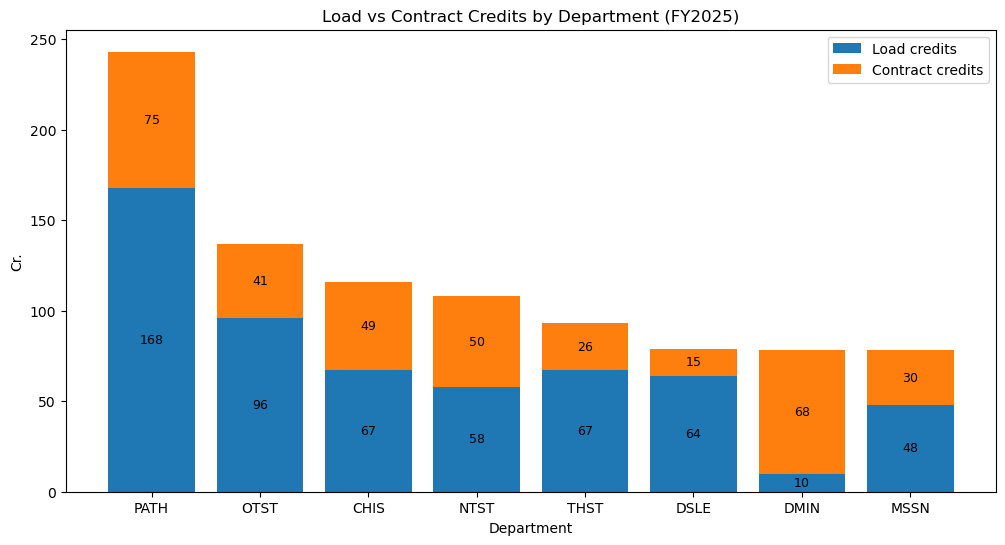

✓ Chart saved as: Step1_output_FinancialReports/report_003a_ShariSheet-based_DepartmentTotalsLoadContract_bar_1.jpg


In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------
# Prep (exclude TOTAL row)
# ---------------------------------------------
plot_df = final_df[final_df["Department"] != "TOTAL"].copy()

plot_df["Load_credits"] = pd.to_numeric(plot_df["Load_credits"], errors="coerce").fillna(0)
plot_df["Contract_credits"] = pd.to_numeric(plot_df["Contract_credits"], errors="coerce").fillna(0)

# Optional: sort by total credits for readability
plot_df["Total_credits"] = plot_df["Load_credits"] + plot_df["Contract_credits"]
plot_df = plot_df.sort_values("Total_credits", ascending=False)

departments = plot_df["Department"].tolist()
load_vals = plot_df["Load_credits"].tolist()
contract_vals = plot_df["Contract_credits"].tolist()

x = range(len(departments))

# ---------------------------------------------
# Create stacked bar chart
# ---------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(x, load_vals, label="Load credits")
plt.bar(x, contract_vals, bottom=load_vals, label="Contract credits")

# ---------------------------------------------
# Add numeric labels inside bar segments
# ---------------------------------------------
for i, (load, contract) in enumerate(zip(load_vals, contract_vals)):
    if load > 0:
        plt.text(
            i,
            load / 2,
            f"{int(load) if float(load).is_integer() else load}",
            ha="center",
            va="center",
            fontsize=9
        )
    if contract > 0:
        plt.text(
            i,
            load + contract / 2,
            f"{int(contract) if float(contract).is_integer() else contract}",
            ha="center",
            va="center",
            fontsize=9
        )

# ---------------------------------------------
# Labels, legend, ticks
# ---------------------------------------------
plt.xlabel("Department")
plt.ylabel("Cr.")
plt.title("Load vs Contract Credits by Department (FY2025)")
plt.legend()

plt.xticks(x, departments)

# ---------------------------------------------
# Save AND show
# ---------------------------------------------
output_path = "Step1_output_FinancialReports/report_003a_ShariSheet-based_DepartmentTotalsLoadContract_bar_1.jpg"
plt.savefig(output_path, dpi=600, format="jpg", bbox_inches="tight")
plt.show()   # <-- shows in Jupyter
plt.close()

print(f"✓ Chart saved as: {output_path}")


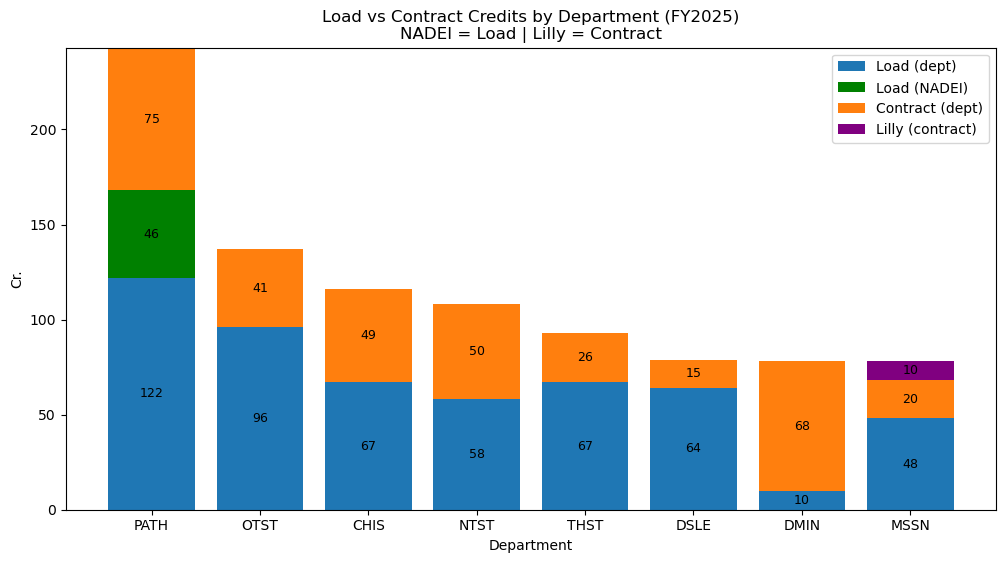

✓ Chart saved as: Step1_output_FinancialReports/report_003a_ShariSheet-based_DepartmentTotalsLoadContract_bar_2.jpg


In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------
# Prep (exclude TOTAL row)
# ---------------------------------------------
plot_df = final_df[final_df["Department"] != "TOTAL"].copy()

plot_df["Load_credits"] = pd.to_numeric(plot_df["Load_credits"], errors="coerce").fillna(0)
plot_df["Contract_credits"] = pd.to_numeric(plot_df["Contract_credits"], errors="coerce").fillna(0)

# ---------------------------------------------
# Compute Lilly CONTRACT + NADEI LOAD credits per department (FY2025)
# ---------------------------------------------
df_src = ShariSheets_combined.copy()

df_src["Cr."] = pd.to_numeric(df_src["Cr."], errors="coerce").fillna(0)
df_src["Fiscal Year"] = pd.to_numeric(df_src["Fiscal Year"], errors="coerce")

df_src["load_or_contract"] = (
    df_src["load/contract"].fillna("").astype(str).str.strip().str.lower()
)
df_src["Faculty Name"] = df_src["Faculty Name"].fillna("").astype(str).str.strip()
df_src["Department"] = df_src["Department"].fillna("").astype(str).str.strip()

df_2025 = df_src[df_src["Fiscal Year"] == 2025].copy()

# ---- Lilly CONTRACT credits ----
lilly_contract = (
    df_2025[
        (df_2025["load_or_contract"] == "contract")
        & (df_2025["Faculty Name"].str.startswith("Lilly:"))
    ]
    .groupby("Department")["Cr."]
    .sum()
    .rename("Lilly_contract_credits")
)

# ---- NADEI LOAD credits ----
nadei_load = (
    df_2025[
        (df_2025["load_or_contract"] == "load")
        & (df_2025["Faculty Name"].str.startswith("NADEI:"))
    ]
    .groupby("Department")["Cr."]
    .sum()
    .rename("NADEI_load_credits")
)

plot_df = plot_df.merge(lilly_contract.reset_index(), on="Department", how="left")
plot_df = plot_df.merge(nadei_load.reset_index(), on="Department", how="left")

plot_df["Lilly_contract_credits"] = pd.to_numeric(
    plot_df["Lilly_contract_credits"], errors="coerce"
).fillna(0)

plot_df["NADEI_load_credits"] = pd.to_numeric(
    plot_df["NADEI_load_credits"], errors="coerce"
).fillna(0)

# ---------------------------------------------
# Split LOAD + CONTRACT into components
# ---------------------------------------------
plot_df["Base_load_credits"] = (
    plot_df["Load_credits"] - plot_df["NADEI_load_credits"]
).clip(lower=0)

plot_df["Base_contract_credits"] = (
    plot_df["Contract_credits"] - plot_df["Lilly_contract_credits"]
).clip(lower=0)

# Optional: sort by total credits
plot_df["Total_credits"] = plot_df["Load_credits"] + plot_df["Contract_credits"]
plot_df = plot_df.sort_values("Total_credits", ascending=False)

departments = plot_df["Department"].tolist()
base_load_vals = plot_df["Base_load_credits"].tolist()
nadei_vals = plot_df["NADEI_load_credits"].tolist()
base_contract_vals = plot_df["Base_contract_credits"].tolist()
lilly_contract_vals = plot_df["Lilly_contract_credits"].tolist()

x = range(len(departments))

# ---------------------------------------------
# Create stacked bar chart
#   Stack order:
#   Load (other) → Load (NADEI) → Contract (other) → Lilly (contract)
# ---------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(x, base_load_vals, label="Load (dept)")
plt.bar(
    x,
    nadei_vals,
    bottom=base_load_vals,
    label="Load (NADEI)",
    color="green"
)

bottom_after_load = [b + n for b, n in zip(base_load_vals, nadei_vals)]

plt.bar(
    x,
    base_contract_vals,
    bottom=bottom_after_load,
    label="Contract (dept)"
)

bottom_after_contract = [
    b + n + c for b, n, c in zip(base_load_vals, nadei_vals, base_contract_vals)
]

plt.bar(
    x,
    lilly_contract_vals,
    bottom=bottom_after_contract,
    label="Lilly (contract)",
    color="purple"
)

# ---------------------------------------------
# Add numeric labels inside segments
# ---------------------------------------------
def fmt(v):
    return f"{int(v)}" if float(v).is_integer() else f"{v}"

for i, (bl, na, bc, lc) in enumerate(
    zip(base_load_vals, nadei_vals, base_contract_vals, lilly_contract_vals)
):
    if bl > 0:
        plt.text(i, bl / 2, fmt(bl), ha="center", va="center", fontsize=9)
    if na > 0:
        plt.text(i, bl + na / 2, fmt(na), ha="center", va="center", fontsize=9)
    if bc > 0:
        plt.text(i, bl + na + bc / 2, fmt(bc), ha="center", va="center", fontsize=9)
    if lc > 0:
        plt.text(
            i,
            bl + na + bc + lc / 2,
            fmt(lc),
            ha="center",
            va="center",
            fontsize=9
        )

# ---------------------------------------------
# Labels, legend, ticks
# ---------------------------------------------
plt.xlabel("Department")
plt.ylabel("Cr.")
plt.title("Load vs Contract Credits by Department (FY2025)\nNADEI = Load | Lilly = Contract")
plt.legend()

plt.xticks(x, departments)

# ---------------------------------------------
# Save AND show
# ---------------------------------------------
output_path = (
    "Step1_output_FinancialReports/report_003a_ShariSheet-based_DepartmentTotalsLoadContract_bar_2.jpg"
)
plt.savefig(output_path, dpi=600, format="jpg", bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Chart saved as: {output_path}")


In [70]:

# ============================================================
# 5. Export to Excel + formatting
# ============================================================

output_file = "Step1_output_FinancialReports/report_003a_ShariSheet-based_DepartmentTotalsLoadContract.xlsx"
sheetname = "Contract Expense & Ratio"

final_df.to_excel(output_file, index=False, sheet_name=sheetname)

wb = load_workbook(output_file)
ws = wb[sheetname]

header_fill = PatternFill("solid", fgColor="D9D9D9")
header_font = Font(bold=True)
summary_fill = PatternFill("solid", fgColor="D9D9D9")
summary_font = Font(bold=True)

# Format header row
for cell in ws[1]:
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center")

summary_row_idx = final_df.shape[0] + 1

# Format summary row
for cell in ws[summary_row_idx]:
    cell.font = summary_font
    cell.fill = summary_fill

# Currency formatting
currency_format = "$#,##0"
contract_col_idx = list(final_df.columns).index("Contract Cost") + 1

for row in range(2, summary_row_idx + 1):
    ws.cell(row=row, column=contract_col_idx).number_format = currency_format

# Autofit columns
for col in ws.columns:
    max_len = 0
    letter = get_column_letter(col[0].column)
    for cell in col:
        try:
            max_len = max(max_len, len(str(cell.value)))
        except:
            pass
    ws.column_dimensions[letter].width = max_len + 2

wb.save(output_file)

print(f"Formatted Excel file saved to: {output_file}")


Formatted Excel file saved to: Step1_output_FinancialReports/report_003a_ShariSheet-based_DepartmentTotalsLoadContract.xlsx


### Report 003b: Subject Totals Load/Contract

In [71]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [72]:
ANEA = ShariSheets_combined_specific_FY[ShariSheets_combined_specific_FY["Subject"] == "ANEA"]
ANEA.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
1083,Summer 2026,"Gregor, Paul Z.",52867.0,pgregor@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"Gregor, Paul Z.",52867.0,OTST,1300,ANEA510,OTST/dig,Archaeology and the Bible,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_OTST_FY2027_v20251214.xlsx,NaN,2.0,NaN,21.0,202631,2027,OTST,ANEA,510.0
1096,Summer 2026,"Ray, Paul J.",29934.0,rayp@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"Choi, Phuichun R.",36676.0,OTST,1300,ANEA510,OTST,Archaeology and the Bible,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_OTST_FY2027_v20251214.xlsx,NaN,2.0,NaN,51.0,202631,2027,OTST,ANEA,510.0
1097,Summer 2026,"Ray, Paul J.",29934.0,rayp@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"Choi, Phuichun R.",36676.0,OTST,1300,ANEA630,dig,Archaeological Field Work,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_OTST_FY2027_v20251214.xlsx,NaN,2.0,NaN,52.0,202631,2027,OTST,ANEA,630.0
1098,Summer 2026,"Ray, Paul J.",29934.0,rayp@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"Choi, Phuichun R.",36676.0,OTST,1300,ANEA830,dig,Adv Arch Field Work,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_OTST_FY2027_v20251214.xlsx,NaN,NaN,NaN,53.0,202631,2027,OTST,ANEA,830.0
1106,Summer 2026,"Younker, Randall W.",42559.0,younker@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"Gregor, Paul Z.",52867.0,OTST,1300,ANEA830,dig,Adv Arch Field Work,In-Person,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_OTST_FY2027_v20251214.xlsx,NaN,NaN,NaN,71.0,202631,2027,OTST,ANEA,830.0


In [73]:
import pandas as pd

# ============================================================
# 1) PREP
# ============================================================
df = ShariSheets_combined_specific_FY.copy()

df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)
df["rate per credit"] = pd.to_numeric(df["rate per credit"], errors="coerce").fillna(0)


df["load_or_contract"] = (
    df["load/contract"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("", "empty")
)

df["Faculty Name"] = df["Faculty Name"].fillna("").astype(str).str.strip()
df["Program"] = df["Program"].fillna("").astype(str).str.strip()
df["Subject"] = df["Subject"].fillna("").astype(str).str.strip()

# Optional: drop blank subjects (recommended)
df = df[df["Subject"] != ""].copy()

GROUP_KEY = "Subject"

# ============================================================
# 2) Load + Contract credits by Subject
# ============================================================
load_credits = (
    df[df["load_or_contract"] == "load"]
    .groupby(GROUP_KEY)["Cr."]
    .sum()
)

contract_credits = (
    df[df["load_or_contract"] == "contract"]
    .groupby(GROUP_KEY)["Cr."]
    .sum()
)

# Build the master table from *all* Subjects (prevents subjects disappearing)
credit_ratio = pd.DataFrame(index=sorted(df[GROUP_KEY].unique()))
credit_ratio.index.name = GROUP_KEY

credit_ratio["Load_credits"] = load_credits
credit_ratio["Contract_credits"] = contract_credits
credit_ratio = credit_ratio.fillna(0)

# ============================================================
# 3) Lilly + NADEI helper totals (ALL computed with same GROUP_KEY)
# ============================================================

# Lilly ALL credits (load+contract)
lilly_all_credits = (
    df[df["Faculty Name"].str.startswith("Lilly:")]
    .groupby(GROUP_KEY)["Cr."]
    .sum()
)

# Lilly CONTRACT credits (contract-only)
lilly_contract_credits = (
    df[
        (df["load_or_contract"] == "contract")
        & (df["Faculty Name"].str.startswith("Lilly:"))
    ]
    .groupby(GROUP_KEY)["Cr."]
    .sum()
)

# NADEI MDIV credits (load+contract BUT Program == MDIV)
nadei_mdiv_credits = (
    df[
        df["Faculty Name"].str.startswith("NADEI:")
        & (df["Program"] == "MDIV")
    ]
    .groupby(GROUP_KEY)["Cr."]
    .sum()
)

# NADEI LOAD credits (load-only; no program condition unless you want it)
nadei_load_credits = (
    df[
        (df["load_or_contract"] == "load")
        & (df["Faculty Name"].str.startswith("NADEI:"))
#        & (df["Program"] == "MDIV")   # <-- remove this line if you truly want ALL NADEI load
    ]
    .groupby(GROUP_KEY)["Cr."]
    .sum()
)

# ============================================================
# 4) Derived credit columns
# ============================================================

# Contract credits without Lilly-funded courses (contract-only Lilly subtraction)
credit_ratio["Contract Credits wo Lilly funded Courses"] = (
    credit_ratio["Contract_credits"] - lilly_contract_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

# Ratios
credit_ratio["Load/Contract Ratio (numeric)"] = credit_ratio.apply(
    lambda r: r["Contract_credits"] / r["Load_credits"] if r["Load_credits"] > 0 else None,
    axis=1
)

credit_ratio["Load/Contract Ratio wo Lilly funded Courses (numeric)"] = credit_ratio.apply(
    lambda r: (
        r["Contract Credits wo Lilly funded Courses"] / r["Load_credits"]
        if r["Load_credits"] > 0 else None
    ),
    axis=1
)

credit_ratio["Load/Contract Ratio"] = credit_ratio["Load/Contract Ratio (numeric)"].apply(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)
credit_ratio["Load/Contract Ratio wo Lilly funded Courses"] = credit_ratio[
    "Load/Contract Ratio wo Lilly funded Courses (numeric)"
].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "")

# --- Totals columns ---
credit_ratio["Sum of all Credits"] = credit_ratio["Load_credits"] + credit_ratio["Contract_credits"]

credit_ratio["Sum of all Credits wo Lilly"] = (
    credit_ratio["Sum of all Credits"] - lilly_all_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

credit_ratio["Sum of all Credits wo NADEI's MDIV courses"] = (
    credit_ratio["Sum of all Credits"] - nadei_mdiv_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

credit_ratio["Sum of all Credits wo (Lilly + NADEI's Mdiv courses)"] = (
    credit_ratio["Sum of all Credits"]
    - lilly_all_credits.reindex(credit_ratio.index).fillna(0)
    - nadei_mdiv_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

# --- NEW: Load credits without NADEI MDIV load (as you asked) ---
credit_ratio["Load_credits wo NADEI's MDIV courses"] = (
    credit_ratio["Load_credits"] - nadei_load_credits.reindex(credit_ratio.index).fillna(0)
).clip(lower=0)

# NOTE: You wrote “compare with Contract_credits”. That implies Contract / Load_wo_NADEI.
credit_ratio["Load/Contract Ratio wo NADEI's MDIV courses (numeric)"] = credit_ratio.apply(
    lambda r: (
        r["Contract_credits"] / r["Load_credits wo NADEI's MDIV courses"]
        if r["Load_credits wo NADEI's MDIV courses"] > 0 else None
    ),
    axis=1
)
credit_ratio["Load/Contract Ratio wo NADEI's MDIV courses"] = credit_ratio[
    "Load/Contract Ratio wo NADEI's MDIV courses (numeric)"
].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "")

# ============================================================
# 5) Contract Cost by Subject (keeps ALL subjects via reindex)
# ============================================================
df_contract = df[df["load_or_contract"] == "contract"].copy()
df_contract["Contract Cost"] = df_contract["Cr."] * df_contract["rate per credit"]

contract_cost = (
    df_contract.groupby(GROUP_KEY)["Contract Cost"]
    .sum()
    .reindex(credit_ratio.index)
    .fillna(0)
)

# ============================================================
# 6) Assemble final_df
# ============================================================
final_df = credit_ratio.copy()
final_df.insert(0, "Contract Cost", contract_cost)

final_df = final_df.reset_index()

final_df = final_df[
    [
        GROUP_KEY,
        "Contract Cost",
        "Load_credits",
        "Contract_credits",
        "Load/Contract Ratio",
        "Sum of all Credits",
        "Sum of all Credits wo Lilly",
        "Sum of all Credits wo NADEI's MDIV courses",
        "Load_credits wo NADEI's MDIV courses",
        "Load/Contract Ratio wo NADEI's MDIV courses",
        "Sum of all Credits wo (Lilly + NADEI's Mdiv courses)",
        "Contract Credits wo Lilly funded Courses",
        "Load/Contract Ratio wo Lilly funded Courses",
    ]
]

# ============================================================
# 7) TOTAL row
# ============================================================
numeric_ratios = credit_ratio["Load/Contract Ratio (numeric)"].dropna()
numeric_ratios_wo_lilly = credit_ratio["Load/Contract Ratio wo Lilly funded Courses (numeric)"].dropna()
numeric_ratios_wo_nadei = credit_ratio["Load/Contract Ratio wo NADEI's MDIV courses (numeric)"].dropna()

summary_row = {
    GROUP_KEY: "TOTAL",
    "Contract Cost": final_df["Contract Cost"].sum(),
    "Load_credits": final_df["Load_credits"].sum(),
    "Contract_credits": final_df["Contract_credits"].sum(),
    "Load/Contract Ratio": f"{numeric_ratios.mean():.2f}" if len(numeric_ratios) else "",

    "Sum of all Credits": final_df["Sum of all Credits"].sum(),
    "Sum of all Credits wo Lilly": final_df["Sum of all Credits wo Lilly"].sum(),
    "Sum of all Credits wo NADEI's MDIV courses": final_df["Sum of all Credits wo NADEI's MDIV courses"].sum(),

    "Load_credits wo NADEI's MDIV courses": final_df["Load_credits wo NADEI's MDIV courses"].sum(),
    "Load/Contract Ratio wo NADEI's MDIV courses": f"{numeric_ratios_wo_nadei.mean():.2f}" if len(numeric_ratios_wo_nadei) else "",

    "Sum of all Credits wo (Lilly + NADEI's Mdiv courses)": final_df["Sum of all Credits wo (Lilly + NADEI's Mdiv courses)"].sum(),

    "Contract Credits wo Lilly funded Courses": final_df["Contract Credits wo Lilly funded Courses"].sum(),
    "Load/Contract Ratio wo Lilly funded Courses": f"{numeric_ratios_wo_lilly.mean():.2f}" if len(numeric_ratios_wo_lilly) else "",
}

final_df = pd.concat([final_df, pd.DataFrame([summary_row])], ignore_index=True)

final_df.head(20)


,Subject,Contract Cost,Load_credits,Contract_credits,Load/Contract Ratio,Sum of all Credits,Sum of all Credits wo Lilly,Sum of all Credits wo NADEI's MDIV courses,Load_credits wo NADEI's MDIV courses,Load/Contract Ratio wo NADEI's MDIV courses,Sum of all Credits wo (Lilly + NADEI's Mdiv courses),Contract Credits wo Lilly funded Courses,Load/Contract Ratio wo Lilly funded Courses
0,ANEA,9450.0,19.0,9.0,0.47,28.0,28.0,28.0,19.0,0.47,28.0,9.0,0.47
1,CHIS,49050.0,62.0,47.0,0.76,109.0,109.0,109.0,62.0,0.76,109.0,47.0,0.76
2,DSLE,28350.0,64.0,27.0,0.42,91.0,91.0,91.0,64.0,0.42,91.0,27.0,0.42
3,GSEM,34650.0,33.0,33.0,1.00,66.0,66.0,66.0,33.0,1.00,66.0,33.0,1.00
4,MSSN,35650.0,52.0,34.0,0.65,86.0,86.0,86.0,52.0,0.65,86.0,34.0,0.65
5,NTST,46500.0,40.0,45.0,1.12,85.0,85.0,85.0,40.0,1.12,85.0,45.0,1.12
6,OTST,28100.0,66.0,27.0,0.41,93.0,93.0,93.0,66.0,0.41,93.0,27.0,0.41
7,PATH,105800.0,168.0,101.0,0.60,269.0,269.0,269.0,168.0,0.60,269.0,101.0,0.60
8,THST,27200.0,54.0,26.0,0.48,80.0,80.0,80.0,54.0,0.48,80.0,26.0,0.48
9,TOTAL,364750.0,558.0,349.0,0.66,907.0,907.0,907.0,558.0,0.66,907.0,349.0,0.66


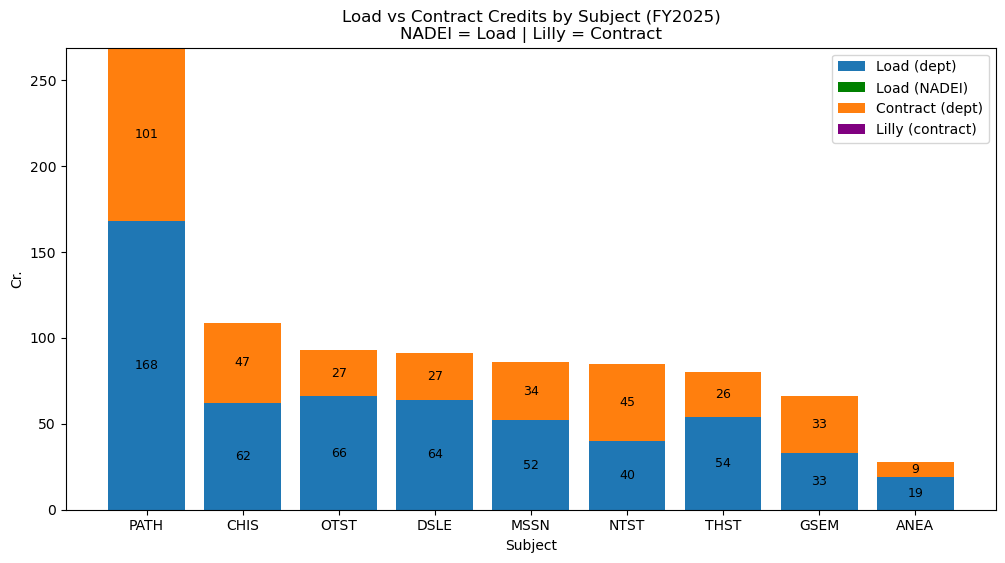

✓ Chart saved as: Step1_output_FinancialReports/report_003b_ShariSheet-based_SubjectTotalsLoadContract_bar_2.jpg


In [74]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------
# Prep (exclude TOTAL row)
# ---------------------------------------------
plot_df = final_df[final_df["Subject"] != "TOTAL"].copy()

plot_df["Load_credits"] = pd.to_numeric(plot_df["Load_credits"], errors="coerce").fillna(0)
plot_df["Contract_credits"] = pd.to_numeric(plot_df["Contract_credits"], errors="coerce").fillna(0)

# ---------------------------------------------
# Compute Lilly CONTRACT + NADEI LOAD credits per department (FY2025)
# ---------------------------------------------
df_src = ShariSheets_combined.copy()

df_src["Cr."] = pd.to_numeric(df_src["Cr."], errors="coerce").fillna(0)
df_src["Fiscal Year"] = pd.to_numeric(df_src["Fiscal Year"], errors="coerce")

df_src["load_or_contract"] = (
    df_src["load/contract"].fillna("").astype(str).str.strip().str.lower()
)
df_src["Faculty Name"] = df_src["Faculty Name"].fillna("").astype(str).str.strip()
df_src["Subject"] = df_src["Subject"].fillna("").astype(str).str.strip()


# ---- Lilly CONTRACT credits ----
lilly_contract = (
    df[
        (df["load_or_contract"] == "contract")
        & (df["Faculty Name"].str.startswith("Lilly:"))
    ]
    .groupby("Subject")["Cr."]
    .sum()
    .rename("Lilly_contract_credits")
)

# ---- NADEI LOAD credits ----
nadei_load = (
    df[
        (df["load_or_contract"] == "load")
        & (df["Faculty Name"].str.startswith("NADEI:"))
    ]
    .groupby("Subject")["Cr."]
    .sum()
    .rename("NADEI_load_credits")
)

plot_df = plot_df.merge(lilly_contract.reset_index(), on="Subject", how="left")
plot_df = plot_df.merge(nadei_load.reset_index(), on="Subject", how="left")

plot_df["Lilly_contract_credits"] = pd.to_numeric(
    plot_df["Lilly_contract_credits"], errors="coerce"
).fillna(0)

plot_df["NADEI_load_credits"] = pd.to_numeric(
    plot_df["NADEI_load_credits"], errors="coerce"
).fillna(0)

# ---------------------------------------------
# Split LOAD + CONTRACT into components
# ---------------------------------------------
plot_df["Base_load_credits"] = (
    plot_df["Load_credits"] - plot_df["NADEI_load_credits"]
).clip(lower=0)

plot_df["Base_contract_credits"] = (
    plot_df["Contract_credits"] - plot_df["Lilly_contract_credits"]
).clip(lower=0)

# Optional: sort by total credits
plot_df["Total_credits"] = plot_df["Load_credits"] + plot_df["Contract_credits"]
plot_df = plot_df.sort_values("Total_credits", ascending=False)

departments = plot_df["Subject"].tolist()
base_load_vals = plot_df["Base_load_credits"].tolist()
nadei_vals = plot_df["NADEI_load_credits"].tolist()
base_contract_vals = plot_df["Base_contract_credits"].tolist()
lilly_contract_vals = plot_df["Lilly_contract_credits"].tolist()

x = range(len(departments))

# ---------------------------------------------
# Create stacked bar chart
#   Stack order:
#   Load (other) → Load (NADEI) → Contract (other) → Lilly (contract)
# ---------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(x, base_load_vals, label="Load (dept)")
plt.bar(
    x,
    nadei_vals,
    bottom=base_load_vals,
    label="Load (NADEI)",
    color="green"
)

bottom_after_load = [b + n for b, n in zip(base_load_vals, nadei_vals)]

plt.bar(
    x,
    base_contract_vals,
    bottom=bottom_after_load,
    label="Contract (dept)"
)

bottom_after_contract = [
    b + n + c for b, n, c in zip(base_load_vals, nadei_vals, base_contract_vals)
]

plt.bar(
    x,
    lilly_contract_vals,
    bottom=bottom_after_contract,
    label="Lilly (contract)",
    color="purple"
)

# ---------------------------------------------
# Add numeric labels inside segments
# ---------------------------------------------
def fmt(v):
    return f"{int(v)}" if float(v).is_integer() else f"{v}"

for i, (bl, na, bc, lc) in enumerate(
    zip(base_load_vals, nadei_vals, base_contract_vals, lilly_contract_vals)
):
    if bl > 0:
        plt.text(i, bl / 2, fmt(bl), ha="center", va="center", fontsize=9)
    if na > 0:
        plt.text(i, bl + na / 2, fmt(na), ha="center", va="center", fontsize=9)
    if bc > 0:
        plt.text(i, bl + na + bc / 2, fmt(bc), ha="center", va="center", fontsize=9)
    if lc > 0:
        plt.text(
            i,
            bl + na + bc + lc / 2,
            fmt(lc),
            ha="center",
            va="center",
            fontsize=9
        )

# ---------------------------------------------
# Labels, legend, ticks
# ---------------------------------------------
plt.xlabel("Subject")
plt.ylabel("Cr.")
plt.title("Load vs Contract Credits by Subject (FY2025)\nNADEI = Load | Lilly = Contract")
plt.legend()

plt.xticks(x, departments)

# ---------------------------------------------
# Save AND show
# ---------------------------------------------
output_path = (
    "Step1_output_FinancialReports/report_003b_ShariSheet-based_SubjectTotalsLoadContract_bar_2.jpg"
)
plt.savefig(output_path, dpi=600, format="jpg", bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Chart saved as: {output_path}")

In [75]:

# ============================================================
# 5. Export to Excel + formatting
# ============================================================

output_file = "Step1_output_FinancialReports/report_003b_ShariSheet-based_SubjectTotalsLoadContract.xlsx"
sheetname = "Contract Expense & Ratio"

final_df.to_excel(output_file, index=False, sheet_name=sheetname)

wb = load_workbook(output_file)
ws = wb[sheetname]

header_fill = PatternFill("solid", fgColor="D9D9D9")
header_font = Font(bold=True)
summary_fill = PatternFill("solid", fgColor="D9D9D9")
summary_font = Font(bold=True)

# Format header row
for cell in ws[1]:
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center")

summary_row_idx = final_df.shape[0] + 1

# Format summary row
for cell in ws[summary_row_idx]:
    cell.font = summary_font
    cell.fill = summary_fill

# Currency formatting
currency_format = "$#,##0"
contract_col_idx = list(final_df.columns).index("Contract Cost") + 1

for row in range(2, summary_row_idx + 1):
    ws.cell(row=row, column=contract_col_idx).number_format = currency_format

# Autofit columns
for col in ws.columns:
    max_len = 0
    letter = get_column_letter(col[0].column)
    for cell in col:
        try:
            max_len = max(max_len, len(str(cell.value)))
        except:
            pass
    ws.column_dimensions[letter].width = max_len + 2

wb.save(output_file)

print(f"Formatted Excel file saved to: {output_file}")


Formatted Excel file saved to: Step1_output_FinancialReports/report_003b_ShariSheet-based_SubjectTotalsLoadContract.xlsx


### Report 004a: How many Credits does each Department offer for each Program?

In [76]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [77]:
df = ShariSheets_combined_specific_FY.copy()

In [78]:
df[df["Cr."] == 2].head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
105,Summer 2026,"O'Reggio, Trevor E.",35762.0,toreggio@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS507,NaN,Church History 1500 to Present,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,21.0,202631,2027,CHIS,CHIS,507.0
109,Summer 2026,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,GSEM520,999,Methods in Biblical & Theo Res,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,43.0,202631,2027,CHIS,GSEM,520.0
110,Summer 2026,contract,148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-80,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,NaN,Hist of SDA Theology,In-Person,MAR-INT,Thailand - Thai,contract,yes,1050.0,2100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,162.0,202631,2027,CHIS,CHIS,574.0
111,Summer 2026,contract,148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-81,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Thailand - Thai,contract,yes,1050.0,2100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,163.0,202631,2027,CHIS,CHIS,624.0


In [79]:
df["Program"].dropna().unique().tolist()

['EGW-Cert',
 'MDIV',
 'MAPM-HISP',
 'MAR-INT',
 'MAPM-ENGL',
 'DMIN-NAD',
 'DMIN-INT',
 'DIS',
 'Urban',
 'DMIN',
 'PHD/THD']

In [80]:
import pandas as pd

# 0. Make sure credits are numeric
df["Cr."] = pd.to_numeric(
    df["Cr."], errors="coerce"
)

# 1. Detect all programs that appear in the data
programs_to_keep = (
    df["Program"]
    .dropna()
    .unique()
    .tolist()
)

# Ensure stable sort
programs_to_keep = sorted(programs_to_keep)

# 2. Filter to all programs (this is now redundant but keeps structure clean)
df_prog = df[
    df["Program"].isin(programs_to_keep)
].copy()

## 3. Restrict to Fiscal Year 2027
#df_prog = df_prog[df_prog["Fiscal Year"] == 2025]

# 4. Aggregate: sum credits per Department × Instructor × Program
agg_instr = (
    df_prog.groupby(
        [
            "Department",
            "Faculty Name",
            "Program",
        ]
    )["Cr."]
    .sum()
    .reset_index()
)

# 5. Pivot: rows = Dept + Instructor, columns = Program
pivot_instr = agg_instr.pivot_table(
    index=["Department", "Faculty Name"],
    columns="Program",
    values="Cr.",
    fill_value=0
)

# 6. Ensure columns appear in a stable order
for prog in programs_to_keep:
    if prog not in pivot_instr.columns:
        pivot_instr[prog] = 0

pivot_instr = pivot_instr[programs_to_keep]  # reorder

# 7. Add Total column
pivot_instr["Total"] = pivot_instr.sum(axis=1)

# 8. Sort index
pivot_instr = pivot_instr.sort_index()

pivot_instr


Program                              DIS  DMIN  DMIN-INT  DMIN-NAD  EGW-Cert  \
Department Faculty Name                                                        
CHIS       Burton, Kevin M.          0.0   0.0       0.0       0.0       6.0   
           Campbell, Michael         0.0   0.0       0.0       0.0       0.0   
           Hernandez, Abner F.       0.0   0.0       0.0       0.0       3.0   
           Kaiser, Angelika          0.0   0.0       0.0       0.0       0.0   
           Kaiser, Denis             0.0   0.0       0.0       0.0       6.0   
           New CHIS Professor        0.0   0.0       0.0       0.0       0.0   
           O'Reggio, Trevor E.       0.0   0.0       0.0       0.0       0.0   
           Quispe, Gluder            0.0   0.0       0.0       0.0       0.0   
           Reeve, John W.            0.0   0.0       0.0       0.0       0.0   
           Rodrigues, Gerson         0.0   0.0       0.0       0.0       3.0   
           Steger, Walter            0.0   0.0       0.0       0.0       0.0   
           Williams, David A.        0.0   0.0       0.0       0.0       0.0   
           contract                  0.0   0.0       0.0       0.0       0.0   
DMIN       Amador-Morales, Luis      0.0   0.0       0.0       4.0       0.0   
           Caldwell, Garrett         0.0   0.0       0.0       5.0       0.0   
           Case, Steve W.            0.0   0.0       0.0       8.0       0.0   
           Goncalves, Kleber D.      0.0   0.0       0.0       4.0       0.0   
           Grys, John W.             0.0   0.0       0.0       5.0       0.0   
           Korchuk, Viacheslav I.    0.0   0.0       4.0       0.0       0.0   
           Lisichny, Aleksandr       0.0   0.0       4.0       0.0       0.0   
           Machado, Carlos A.        0.0   0.0       0.0       4.0       0.0   
           Mayer, Jorge R.           0.0   0.0       0.0       4.0       0.0   
           Norton, Ricardo           0.0   0.0       0.0       4.0       0.0   
           Penno, David K.           0.0   0.0       8.0       0.0       0.0   
           Ramirez, Johnny           0.0   0.0       0.0       4.0       0.0   
           Wagener Smith, Anthony    0.0   0.0       5.0       0.0       0.0   
           Yeagley, Stephen T.       0.0   0.0       0.0       5.0       0.0   
           Zubkov, Pavel A.          0.0   0.0       6.0       0.0       0.0   
           de Waal, Kayle            0.0   0.0       4.0       0.0       0.0   
DSLE       Fraser, Jasmine J.        0.0   0.0       0.0       0.0       0.0   
           Hall, Kenley D.           0.0   0.0       0.0       0.0       0.0   
           Joseph, Ainsworth         0.0   0.0       0.0       0.0       0.0   
           Kidder, S Joseph          0.0   0.0       0.0       0.0       0.0   
           Martin, Ben               0.0   0.0       0.0       0.0       0.0   
           Matthews, John V.         0.0   0.0       0.0       0.0       0.0   
           Norton, Ricardo           0.0   0.0       0.0       0.0       0.0   
           Paquini, Rogelio          0.0   0.0       0.0       0.0       0.0   
           Social Work-Staff         0.0   0.0       0.0       0.0       0.0   
           Ward, Scott R.            0.0   0.0       0.0       0.0       0.0   
           Yeagley, Stephen T.       0.0   0.0       0.0       0.0       0.0   
MSSN       Cincala, Petr             4.0   0.0       0.0       0.0       0.0   
           Drumi, Yuri               1.0   0.0       0.0       0.0       0.0   
           Drumm, Rene D.            2.0   0.0       0.0       0.0       0.0   
           Duffis Gordon, Daniel M.  1.0   0.0       0.0       0.0       0.0   
           Goya, Ignacio             0.0   0.0       0.0       0.0       0.0   
           Hunter, Claval            0.0   0.0       0.0       0.0       0.0   
           Kwon, Sung K.             0.0   0.0       0.0       0.0       0.0   
           Ortiz, Luis F.            0.0   0.0       0.0       0.0       0.0   


In [81]:
df = pivot_instr.reset_index()
columns = df.columns.tolist()


final_rows = []
first_dept = True   # <— NEW FLAG

for dept, sub in df.groupby("Department"):

    # ---- REAL HEADER ROW (repeat full header row) ----
    # Insert ONLY for departments *after the first one*
    if not first_dept:
        header_row = {col: col for col in columns}
        final_rows.append(header_row)

    # ---- Instructor rows ----
    for _, row in sub.iterrows():
        final_rows.append(row.to_dict())

    # ---- Summary Row ----
    summary = {col: "" for col in columns}
    summary["Department"] = dept
    summary["Faculty Name"] = "DEPARTMENT TOTAL"

    for prog in programs_to_keep:
        summary[prog] = sub[prog].sum()

    summary["Total"] = sub["Total"].sum()
    final_rows.append(summary)

    # ---- Two empty rows ----
    final_rows.append({col: "" for col in columns})
    final_rows.append({col: "" for col in columns})

    # After finishing the first block, switch flag off
    first_dept = False

export_df = pd.DataFrame(final_rows)

# Replace zeros with blanks
export_df = export_df.replace(0, "")



export_df.head(20)


,Department,Faculty Name,DIS,DMIN,DMIN-INT,DMIN-NAD,EGW-Cert,MAPM-ENGL,MAPM-HISP,MAR-INT,MDIV,PHD/THD,Urban,Total
0,CHIS,"Burton, Kevin M.",,,,,6.0,,,,,,,6.0
1,CHIS,"Campbell, Michael",,,,,,3.0,,,,,,3.0
2,CHIS,"Hernandez, Abner F.",,,,,3.0,,3.0,,2.0,,,8.0
3,CHIS,"Kaiser, Angelika",,,,,,,,,6.0,,,6.0
4,CHIS,"Kaiser, Denis",,,,,6.0,3.0,,,,,,9.0
5,CHIS,New CHIS Professor,,,,,,,3.0,,13.0,,,16.0
6,CHIS,"O'Reggio, Trevor E.",,,,,,,,,5.0,,,5.0
7,CHIS,"Quispe, Gluder",,,,,,,6.0,,,,,6.0
8,CHIS,"Reeve, John W.",,,,,,,,2.0,15.0,,,17.0
9,CHIS,"Rodrigues, Gerson",,,,,3.0,3.0,3.0,,8.0,,,17.0


In [82]:
output_file = "Step1_output_FinancialReports/report_004a_ShariSheet-based_ProgramCreditsByDepartment.xlsx"
sheetname = "Credits_by_Department_FY"

# Always export something (even an empty sheet)
export_df.to_excel(output_file, sheet_name=sheetname, index=False)

# ------------------------------------------------------------
# Skip formatting safely if there's nothing to format
# ------------------------------------------------------------
required_col = "Faculty Name"

if export_df is None or export_df.empty:
    print(f"⚠️ {sheetname}: export_df is empty → wrote file, skipping formatting.")
elif required_col not in export_df.columns:
    print(f"⚠️ {sheetname}: missing column '{required_col}' → wrote file, skipping formatting.")
else:
    from openpyxl import load_workbook
    from openpyxl.styles import Font, PatternFill
    from openpyxl.utils import get_column_letter

    wb = load_workbook(output_file)
    ws = wb[sheetname]

    header_fill = PatternFill("solid", fgColor="D9D9D9")
    header_font = Font(bold=True)

    summary_fill = PatternFill("solid", fgColor="D9D9D9")
    summary_font = Font(bold=True)

    instructor_col = export_df.columns.get_loc(required_col) + 1

    for row in ws.iter_rows(min_row=1, max_row=ws.max_row):
        cell_value = row[instructor_col - 1].value

        # repeated header rows
        if cell_value == required_col:
            for cell in row:
                cell.font = header_font
                cell.fill = header_fill

        # summary rows
        if cell_value == "DEPARTMENT TOTAL":
            for cell in row:
                cell.font = summary_font
                cell.fill = summary_fill

    # Autofit columns (safe)
    for col in ws.columns:
        max_len = 0
        letter = get_column_letter(col[0].column)
        for cell in col:
            v = "" if cell.value is None else str(cell.value)
            if len(v) > max_len:
                max_len = len(v)
        ws.column_dimensions[letter].width = min(max_len + 2, 60)

    wb.save(output_file)
    print(f"✅ Formatted Excel written to: {output_file}")


✅ Formatted Excel written to: Step1_output_FinancialReports/report_004a_ShariSheet-based_ProgramCreditsByDepartment.xlsx


### Report 004b: How many Load Credits does each Department offer for each Program?

In [83]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [84]:
df = ShariSheets_combined_specific_FY.copy()

In [85]:
df["Program"].dropna().unique().tolist()

['EGW-Cert',
 'MDIV',
 'MAPM-HISP',
 'MAR-INT',
 'MAPM-ENGL',
 'DMIN-NAD',
 'DMIN-INT',
 'DIS',
 'Urban',
 'DMIN',
 'PHD/THD']

In [86]:
import pandas as pd

# -----------------------------
# Clean + numeric
# -----------------------------
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

df["Program"] = df["Program"].fillna("").astype(str).str.strip().replace("", "Main")
df["Department"] = df["Department"].fillna("").astype(str).str.strip()
df["Faculty Name"] = df["Faculty Name"].fillna("").astype(str).str.strip()

df["load_or_contract"] = (
    df["load/contract"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

## FY2025 only
#df["Fiscal Year"] = pd.to_numeric(df["Fiscal Year"], errors="coerce")
#df = df[df["Fiscal Year"] == 2025].copy()

# Optional: keep only meaningful rows
df = df[(df["Department"] != "") & (df["Faculty Name"] != "") & (df["Cr."] > 0)].copy()

# Detect programs (stable order)
programs_to_keep = sorted(df["Program"].dropna().unique().tolist())

# -----------------------------
# LOAD rows (for instructor table)
# -----------------------------
df_load = df[df["load_or_contract"] == "load"].copy()

agg_load = (
    df_load.groupby(["Department", "Faculty Name", "Program"], dropna=False)["Cr."]
          .sum()
          .reset_index()
)

pivot_load = agg_load.pivot_table(
    index=["Department", "Faculty Name"],
    columns="Program",
    values="Cr.",
    fill_value=0
)

# Ensure stable program columns
for prog in programs_to_keep:
    if prog not in pivot_load.columns:
        pivot_load[prog] = 0

pivot_load = pivot_load[programs_to_keep]

# Total load per person (row total across programs)
pivot_load["Total Load per person"] = pivot_load.sum(axis=1)

# -----------------------------
# CONTRACT totals per dept × program (for dept block summary rows)
# -----------------------------
df_contract = df[df["load_or_contract"] == "contract"].copy()

contract_totals_by_dept_prog = (
    df_contract.groupby(["Department", "Program"], dropna=False)["Cr."]
              .sum()
              .unstack(fill_value=0)
)

# Ensure all programs exist as columns (stable)
for prog in programs_to_keep:
    if prog not in contract_totals_by_dept_prog.columns:
        contract_totals_by_dept_prog[prog] = 0

contract_totals_by_dept_prog = contract_totals_by_dept_prog[programs_to_keep]

pivot_load


Program                          DIS  DMIN-INT  DMIN-NAD  EGW-Cert  MAPM-ENGL  \
Department Faculty Name                                                         
CHIS       Hernandez, Abner F.   0.0       0.0       0.0       0.0        0.0   
           Kaiser, Denis         0.0       0.0       0.0       6.0        3.0   
           New CHIS Professor    0.0       0.0       0.0       0.0        0.0   
           O'Reggio, Trevor E.   0.0       0.0       0.0       0.0        0.0   
           Reeve, John W.        0.0       0.0       0.0       0.0        0.0   
           Rodrigues, Gerson     0.0       0.0       0.0       3.0        3.0   
           Williams, David A.    0.0       0.0       0.0       0.0        0.0   
DMIN       Amador-Morales, Luis  0.0       0.0       4.0       0.0        0.0   
           Zubkov, Pavel A.      0.0       6.0       0.0       0.0        0.0   
DSLE       Fraser, Jasmine J.    0.0       0.0       0.0       0.0        0.0   
           Hall, Kenley D.       0.0       0.0       0.0       0.0        0.0   
           Joseph, Ainsworth     0.0       0.0       0.0       0.0        0.0   
           Kidder, S Joseph      0.0       0.0       0.0       0.0        3.0   
           Paquini, Rogelio      0.0       0.0       0.0       0.0        3.0   
           Ward, Scott R.        0.0       0.0       0.0       0.0        0.0   
MSSN       Cincala, Petr         4.0       0.0       0.0       0.0        0.0   
           Drumi, Yuri           1.0       0.0       0.0       0.0        3.0   
           Sanou, Boubakar       6.0       0.0       0.0       0.0        0.0   
           Tompkins, Andrew J.   4.0       0.0       0.0       0.0        3.0   
NTST       Choi, Phuichun R.     0.0       0.0       0.0       0.0        3.0   
           Cortez, Felix H.      0.0       0.0       0.0       0.0        3.0   
           New Professor         0.0       0.0       0.0       0.0        3.0   
           Stefanovic, Ranko     0.0       0.0       0.0       0.0        0.0   
           Vine, Cedric E.       0.0       0.0       0.0       0.0        0.0   
OTST       Gane, Roy E.          0.0       0.0       0.0       0.0        0.0   
           Glanz, Oliver         0.0       0.0       0.0       0.0        0.0   
           Gregor, Paul Z.       0.0       0.0       0.0       0.0        0.0   
           New OTST Professor    0.0       0.0       0.0       0.0        0.0   
           Olariu, Daniel        0.0       0.0       0.0       0.0        0.0   
           Ray, Paul J.          0.0       0.0       0.0       0.0        0.0   
           Skinner, Jerome L.    0.0       0.0       0.0       0.0        0.0   
           Younker, Randall W.   0.0       0.0       0.0       0.0        0.0   
PATH       Coralie, Alain        0.0       0.0       0.0       0.0        6.0   
           Crews, Heather        0.0       0.0       0.0       0.0        0.0   
           Gaton, Roy G.         0.0       0.0       0.0       0.0        0.0   
           Hall, Kenley D.       0.0       0.0       0.0       0.0        0.0   
           Kidder, S Joseph      0.0       0.0       0.0       0.0        0.0   
           Lewis, Michael        0.0       0.0       0.0       0.0        0.0   
           Madding, Timothy E.   0.0       0.0       0.0       0.0        3.0   
           McLean, Errol N.      0.0       0.0       0.0       0.0        3.0   
           Norton, Ricardo       0.0       0.0       0.0       0.0        0.0   
           Richards, Natasha     0.0       0.0       0.0       0.0        0.0   
           Rojas, Eli            0.0       0.0       0.0       0.0        0.0   
           Staff PATH            0.0       0.0       0.0       0.0        3.0   
           Williams, David A.    0.0       0.0       0.0       0.0        3.0   
THST       Fortin, Denis         0.0       0.0       0.0       0.0        3.0   
           Hanna, Martin F.      0.0       0.0       0.0       0.0        0.0   
           Jeroncic, Ante      

In [87]:
df = pivot_instr.reset_index()

# Make sure every program column exists before building final_rows
for prog in programs_to_keep:
    if prog not in df.columns:
        df[prog] = 0

# Also make sure Total exists
if "Total" not in df.columns:
    df["Total"] = df[programs_to_keep].sum(axis=1)

columns = df.columns.tolist()

final_rows = []
first_dept = True

for dept, sub in df.groupby("Department"):

    # ---- REAL HEADER ROW ----
    if not first_dept:
        header_row = {col: col for col in columns}
        final_rows.append(header_row)

    # ---- Instructor rows ----
    for _, row in sub.iterrows():
        final_rows.append(row.to_dict())

    # ---- Summary Row ----
    summary = {col: "" for col in columns}
    summary["Department"] = dept
    summary["Faculty Name"] = "DEPARTMENT TOTAL"

    for prog in programs_to_keep:
        summary[prog] = pd.to_numeric(sub[prog], errors="coerce").fillna(0).sum()

    summary["Total"] = pd.to_numeric(sub["Total"], errors="coerce").fillna(0).sum()
    final_rows.append(summary)

    # ---- Two empty rows ----
    final_rows.append({col: "" for col in columns})
    final_rows.append({col: "" for col in columns})

    first_dept = False

export_df = pd.DataFrame(final_rows)

# Replace zeros with blanks
export_df = export_df.replace(0, "")

export_df.head(20)

,Department,Faculty Name,DIS,DMIN,DMIN-INT,DMIN-NAD,EGW-Cert,MAPM-ENGL,MAPM-HISP,MAR-INT,MDIV,PHD/THD,Urban,Total,Main
0,CHIS,"Burton, Kevin M.",,,,,6.0,,,,,,,6.0,
1,CHIS,"Campbell, Michael",,,,,,3.0,,,,,,3.0,
2,CHIS,"Hernandez, Abner F.",,,,,3.0,,3.0,,2.0,,,8.0,
3,CHIS,"Kaiser, Angelika",,,,,,,,,6.0,,,6.0,
4,CHIS,"Kaiser, Denis",,,,,6.0,3.0,,,,,,9.0,
5,CHIS,New CHIS Professor,,,,,,,3.0,,13.0,,,16.0,
6,CHIS,"O'Reggio, Trevor E.",,,,,,,,,5.0,,,5.0,
7,CHIS,"Quispe, Gluder",,,,,,,6.0,,,,,6.0,
8,CHIS,"Reeve, John W.",,,,,,,,2.0,15.0,,,17.0,
9,CHIS,"Rodrigues, Gerson",,,,,3.0,3.0,3.0,,8.0,,,17.0,


In [88]:
import pandas as pd

# Desired column order:
final_cols = ["Department", "Faculty Name", "Total Load per person"] + programs_to_keep
HEADER_SENTINEL = "__HEADER__"  # protects repeated headers from cleanup

# ------------------------------------------------------------
# SAFETY: default empty export_df with correct schema
# ------------------------------------------------------------
export_df = pd.DataFrame(columns=final_cols)

try:
    # Reset to a flat DF
    df_load_pivot = pivot_load.reset_index()

    # Ensure required columns exist
    missing = [c for c in final_cols if c not in df_load_pivot.columns]
    if df_load_pivot.empty or missing:
        print(f"⚠️ No results / missing columns ({missing}) → creating empty export_df and continuing.")
    else:
        df_load_pivot = df_load_pivot[final_cols].copy()
        columns = df_load_pivot.columns.tolist()

        final_rows = []
        first_dept = True

        for dept, sub in df_load_pivot.groupby("Department", sort=True):

            # ---- Repeat header row before each department block (except first) ----
            if not first_dept:
                header_row = {col: col for col in columns}
                header_row["Faculty Name"] = HEADER_SENTINEL
                final_rows.append(header_row)

            # ---- Instructor rows (LOAD only) ----
            for _, row in sub.iterrows():
                final_rows.append(row.to_dict())

            # ---- Dept totals: LOAD ----
            load_summary = {col: 0 for col in columns}
            load_summary["Department"] = dept
            load_summary["Faculty Name"] = "DEPARTMENT TOTAL Load Credits"
            load_summary["Total Load per person"] = float(
                pd.to_numeric(sub["Total Load per person"], errors="coerce").fillna(0).sum()
            )
            for prog in programs_to_keep:
                load_summary[prog] = float(pd.to_numeric(sub[prog], errors="coerce").fillna(0).sum())
            final_rows.append(load_summary)

            # ---- Dept totals: CONTRACT ----
            contract_summary = {col: 0 for col in columns}
            contract_summary["Department"] = dept
            contract_summary["Faculty Name"] = "DEPARTMENT TOTAL Contract Credits"

            if (
                contract_totals_by_dept_prog is not None
                and not contract_totals_by_dept_prog.empty
                and dept in contract_totals_by_dept_prog.index
            ):
                c_row = contract_totals_by_dept_prog.loc[dept]
                contract_total_all = float(pd.to_numeric(c_row, errors="coerce").fillna(0).sum())
                contract_summary["Total Load per person"] = contract_total_all
                for prog in programs_to_keep:
                    contract_summary[prog] = float(pd.to_numeric(c_row.get(prog, 0), errors="coerce"))
            else:
                contract_summary["Total Load per person"] = 0
                for prog in programs_to_keep:
                    contract_summary[prog] = 0

            final_rows.append(contract_summary)

            # ---- Dept totals: LOAD + CONTRACT ----
            both_summary = {col: 0 for col in columns}
            both_summary["Department"] = dept
            both_summary["Faculty Name"] = "DEPARTMENT TOTAL Contract+Load Credits"
            both_summary["Total Load per person"] = float(load_summary["Total Load per person"]) + float(
                contract_summary["Total Load per person"]
            )
            for prog in programs_to_keep:
                both_summary[prog] = float(load_summary[prog]) + float(contract_summary[prog])
            final_rows.append(both_summary)

            # ---- Two empty spacer rows ----
            final_rows.append({col: "" for col in columns})
            final_rows.append({col: "" for col in columns})

            first_dept = False

        export_df = pd.DataFrame(final_rows, columns=final_cols)

        # ------------------------------------------------------------
        # Cosmetic cleanup: hide zeros everywhere EXCEPT header rows
        # ------------------------------------------------------------
        numeric_cols = [c for c in export_df.columns if c not in ["Department", "Faculty Name"]]

        if not export_df.empty and "Faculty Name" in export_df.columns:
            is_header_row = export_df["Faculty Name"].eq(HEADER_SENTINEL)

            for c in numeric_cols:
                cleaned = pd.to_numeric(export_df.loc[~is_header_row, c], errors="coerce").replace({0: ""})
                export_df.loc[~is_header_row, c] = cleaned

            # Put the visible label back into Faculty Name for header rows
            export_df.loc[is_header_row, "Faculty Name"] = "Faculty Name"

except Exception as e:
    # Absolute fallback: keep export_df as empty schema-correct DF and continue
    print(f"⚠️ Report build skipped due to error: {e}")

export_df.head(25)


,Department,Faculty Name,Total Load per person,DIS,DMIN-INT,DMIN-NAD,EGW-Cert,MAPM-ENGL,MAPM-HISP,MAR-INT,MDIV,Main,PHD/THD,Urban
0,CHIS,"Hernandez, Abner F.",5.0,,,,,,3.0,,2.0,,,
1,CHIS,"Kaiser, Denis",9.0,,,,6.0,3.0,,,,,,
2,CHIS,New CHIS Professor,16.0,,,,,,3.0,,13.0,,,
3,CHIS,"O'Reggio, Trevor E.",5.0,,,,,,,,5.0,,,
4,CHIS,"Reeve, John W.",12.0,,,,,,,,12.0,,,
5,CHIS,"Rodrigues, Gerson",17.0,,,,3.0,3.0,3.0,,8.0,,,
6,CHIS,"Williams, David A.",3.0,,,,,,,,3.0,,,
7,CHIS,DEPARTMENT TOTAL Load Credits,67.0,,,,9.0,6.0,9.0,,43.0,,,
8,CHIS,DEPARTMENT TOTAL Contract Credits,49.0,,,,9.0,12.0,6.0,10.0,12.0,,,
9,CHIS,DEPARTMENT TOTAL Contract+Load Credits,116.0,,,,18.0,18.0,15.0,10.0,55.0,,,


In [89]:
output_file = "Step1_output_FinancialReports/report_004b_ShariSheet-based_ProgramLoadCreditsByDepartment.xlsx"
sheetname = "Load_by_Department_FY"

export_df.to_excel(output_file, sheet_name=sheetname, index=False)

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

wb = load_workbook(output_file)
ws = wb[sheetname]

header_fill = PatternFill("solid", fgColor="D9D9D9")
header_font = Font(bold=True)

summary_fill = PatternFill("solid", fgColor="D9D9D9")
summary_font = Font(bold=True)

# Column index for "Faculty Name" (1-based in Excel)
instructor_col = export_df.columns.get_loc("Faculty Name") + 1

for row in ws.iter_rows(min_row=1, max_row=ws.max_row):
    cell_value = row[instructor_col - 1].value

    # Repeated header rows (Faculty Name column literally says "Faculty Name")
    if cell_value == "Faculty Name":
        for cell in row:
            cell.font = header_font
            cell.fill = header_fill

    # Totals rows (all 3 totals rows)
    if isinstance(cell_value, str) and cell_value.startswith("DEPARTMENT TOTAL"):
        for cell in row:
            cell.font = summary_font
            cell.fill = summary_fill

# Autofit columns
for col in ws.columns:
    max_len = 0
    letter = get_column_letter(col[0].column)
    for cell in col:
        try:
            max_len = max(max_len, len(str(cell.value)))
        except Exception:
            pass
    ws.column_dimensions[letter].width = max_len + 2

wb.save(output_file)
print(f"Formatted Excel written to: {output_file}")


Formatted Excel written to: Step1_output_FinancialReports/report_004b_ShariSheet-based_ProgramLoadCreditsByDepartment.xlsx


### Report 005: How many Load-Credits and how man Contract-Credits are used for each Program the next FY?


In [90]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [91]:
df = ShariSheets_combined_specific_FY.copy()

# Ensure credits numeric
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce")

# Clean load/contract column
df["load_or_contract"] = (
    df["load/contract"]
    .fillna("")
    .str.lower()
    .str.strip()
)

# Replace empty cells with label
df["load_or_contract"] = df["load_or_contract"].replace("", "empty")

# ---- GROUP BY PROGRAM → then load/contract ----
program_load_contract = (
    df.groupby(["Program", "load_or_contract"])["Cr."]
      .sum()
      .unstack(fill_value=0)
      .reset_index()
)

# Ensure consistent columns
for col in ["load", "contract", "empty"]:
    if col not in program_load_contract.columns:
        program_load_contract[col] = 0

# Reorder columns
program_load_contract = program_load_contract[
    ["Program", "load", "contract", "empty"]
]

# Add total column
program_load_contract["Total"] = (
    program_load_contract["load"]
    + program_load_contract["contract"]
    + program_load_contract["empty"]
)

# ============================================================
#  ADD SUMMARY ROW (total across programs)
# ============================================================

summary_row = {
    "Program": "TOTAL",
    "load": program_load_contract["load"].sum(),
    "contract": program_load_contract["contract"].sum(),
    "empty": program_load_contract["empty"].sum(),
    "Total": program_load_contract["Total"].sum(),
}

program_load_contract = pd.concat(
    [program_load_contract, pd.DataFrame([summary_row])],
    ignore_index=True
)

# ============================================================
#  RENAME COLUMNS AS REQUESTED
# ============================================================

program_load_contract = program_load_contract.rename(columns={
    "load": "credits from Load",
    "contract": "credits from Contract",
    "empty": "credits from neither Load nor Contract",
    "Total": "Total credits"
})

# ============================================================
#  ADD Contract/Load Ratio COLUMN
# ============================================================

program_load_contract["Contract/Load Ratio"] = program_load_contract.apply(
    lambda r: (
        r["credits from Contract"] / r["credits from Load"]
        if r["credits from Load"] > 0
        else ""
    ),
    axis=1
)

# Optional: format ratio to 2 decimals (except TOTAL row if you prefer)
program_load_contract["Contract/Load Ratio"] = program_load_contract["Contract/Load Ratio"].apply(
    lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x
)

program_load_contract


,Program,credits from Load,credits from Contract,credits from neither Load nor Contract,Total credits,Contract/Load Ratio
0,DIS,15.0,9.0,0,24.0,0.60
1,DMIN,0.0,0.0,0,0.0,
2,DMIN-INT,6.0,25.0,0,31.0,4.17
3,DMIN-NAD,4.0,43.0,0,47.0,10.75
4,EGW-Cert,9.0,9.0,0,18.0,1.00
5,MAPM-ENGL,51.0,66.0,0,117.0,1.29
6,MAPM-HISP,21.0,63.0,0,84.0,3.00
7,MAR-INT,3.0,34.0,0,37.0,11.33
8,MDIV,462.0,91.0,0,553.0,0.20
9,PHD/THD,0.0,2.0,0,2.0,


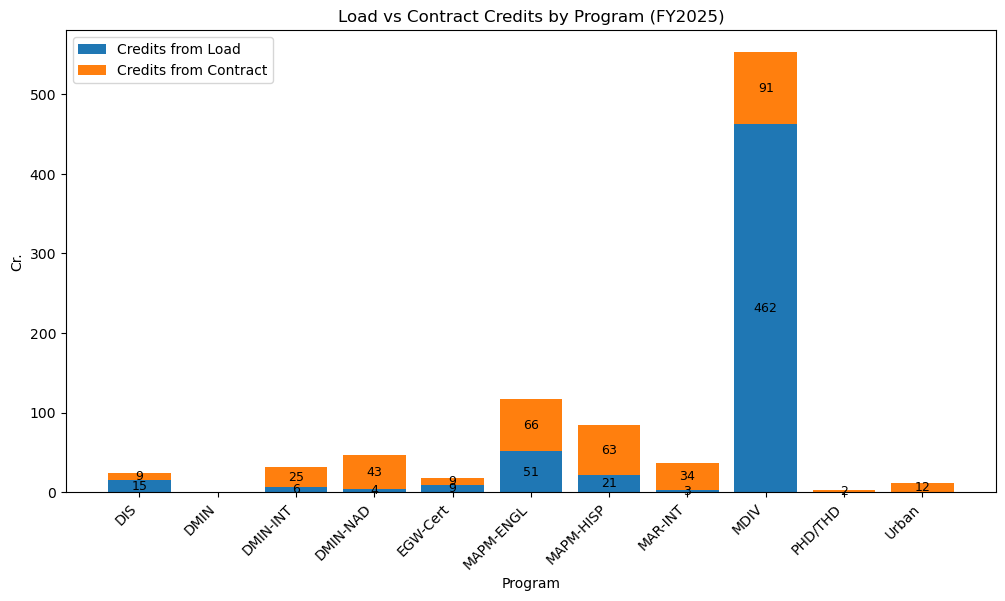

✓ Bar chart saved as: Step1_output_FinancialReports/report_005_ShariSheet-based_ProgramTotalsLoadContract_pie1.jpg


In [92]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# Prepare data (exclude TOTAL row)
# ---------------------------------------------
plot_df = program_load_contract[
    program_load_contract["Program"] != "TOTAL"
].copy()

programs = plot_df["Program"].tolist()
load_vals = plot_df["credits from Load"].tolist()
contract_vals = plot_df["credits from Contract"].tolist()

x = range(len(programs))

# ---------------------------------------------
# Create stacked bar chart
# ---------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    x,
    load_vals,
    label="Credits from Load"
)

plt.bar(
    x,
    contract_vals,
    bottom=load_vals,
    label="Credits from Contract"
)

# ---------------------------------------------
# Add numeric labels inside bar segments
# ---------------------------------------------
for i, (load, contract) in enumerate(zip(load_vals, contract_vals)):
    if load > 0:
        plt.text(
            i,
            load / 2,
            f"{int(load) if float(load).is_integer() else load}",
            ha="center",
            va="center",
            fontsize=9
        )
    if contract > 0:
        plt.text(
            i,
            load + contract / 2,
            f"{int(contract) if float(contract).is_integer() else contract}",
            ha="center",
            va="center",
            fontsize=9
        )

# ---------------------------------------------
# Axes, labels, legend
# ---------------------------------------------
plt.xlabel("Program")
plt.ylabel("Cr.")
plt.title("Load vs Contract Credits by Program (FY2025)")
plt.legend()

plt.xticks(x, programs, rotation=45, ha="right")

# ---------------------------------------------
# Save AND show
# ---------------------------------------------
output_path = ("Step1_output_FinancialReports/report_005_ShariSheet-based_ProgramTotalsLoadContract_pie1.jpg"
)

plt.savefig(output_path, dpi=600, format="jpg", bbox_inches="tight")
plt.show()   # <-- show in Jupyter
plt.close()

print(f"✓ Bar chart saved as: {output_path}")


In [93]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

# ============================================================
# 1. EXPORT TO EXCEL (initial write)
# ============================================================

output_file = "Step1_output_FinancialReports/report_005_ShariSheet-based_ProgramTotalsLoadContract.xlsx"
sheetname = "Program Summary"

program_load_contract.to_excel(output_file, sheet_name=sheetname, index=False)

# ============================================================
# 2. FORMAT THE EXCEL FILE
# ============================================================

wb = load_workbook(output_file)
ws = wb[sheetname]

# Styles
header_fill = PatternFill("solid", fgColor="D9D9D9")
header_font = Font(bold=True)

summary_fill = PatternFill("solid", fgColor="D9D9D9")
summary_font = Font(bold=True)

# ------------- HEADER ROW FORMATTING -------------
for cell in ws[1]:
    cell.font = header_font
    cell.fill = header_fill

# ------------- SUMMARY ROW FORMATTING -------------
# The summary row is the last row of the dataframe
summary_row_index = program_load_contract.shape[0] + 1  # +1 because Excel is 1-based and header exists

for cell in ws[summary_row_index]:
    cell.font = summary_font
    cell.fill = summary_fill

# ------------- AUTO-FIT COLUMN WIDTHS -------------
for col in ws.columns:
    max_len = 0
    col_letter = get_column_letter(col[0].column)
    for cell in col:
        try:
            max_len = max(max_len, len(str(cell.value)))
        except:
            pass
    ws.column_dimensions[col_letter].width = max_len + 2

wb.save(output_file)

print(f"Formatted Excel file saved to: {output_file}")


Formatted Excel file saved to: Step1_output_FinancialReports/report_005_ShariSheet-based_ProgramTotalsLoadContract.xlsx


### Report 006: Total Contracts per Department per Program with Credit and $$$ information.

In [94]:
ShariSheets_combined_specific_FY.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
99,Summer 2026,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,CHIS: 11-1100-9120-78,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Kenya,contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,160.0,202631,2027,CHIS,CHIS,685.0
100,Summer 2026,"Kaiser, Denis",134382.0,denis@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,ASYNC,EGW-Cert,Adventist University of Africa - AUA,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,11.0,202631,2027,CHIS,CHIS,674.0
101,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,2.0,NaN,61.0,202631,2027,CHIS,CHIS,624.0
102,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,3.0,NaN,62.0,202631,2027,CHIS,CHIS,674.0
103,Summer 2026,New CHIS Professor,124996.0,wdavid@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2027_v20251214.xlsx,NaN,0.0,NaN,63.0,202631,2027,CHIS,CHIS,574.0


In [95]:
import pandas as pd
import unicodedata

df = ShariSheets_combined_specific_FY.copy()

# -----------------------------
# 1) Robust text cleaning
# -----------------------------
def clean_text_series(s: pd.Series, lower=False) -> pd.Series:
    s = s.astype("string")

    # Normalize unicode (fixes look-alike chars)
    s = s.map(lambda x: unicodedata.normalize("NFKC", x) if pd.notna(x) else x)

    # Normalize whitespace + NBSP
    s = s.str.replace("\u00A0", " ", regex=False)   # non-breaking space
    s = s.str.replace(r"\s+", " ", regex=True)      # collapse repeated whitespace
    s = s.str.strip()

    if lower:
        s = s.str.lower()

    # Normalize dash variants
    s = s.str.replace("–", "-", regex=False).str.replace("—", "-", regex=False)

    # Missing markers
    s = s.replace({"": pd.NA, "nan": pd.NA, "<na>": pd.NA})

    return s

df["Department"] = clean_text_series(df["Department"])
df["Program"] = clean_text_series(df["Program"])
df["load/contract"] = clean_text_series(df["load/contract"], lower=True)

# -----------------------------
# 2) Robust numeric conversion
# -----------------------------
def to_number(s: pd.Series) -> pd.Series:
    # Handles "$3,000", "3000 ", etc.
    return (
        s.astype(str)
         .str.replace(r"[^0-9.\-]", "", regex=True)
         .replace("", "0")
         .astype(float)
    )

df["Cr."] = to_number(df["Cr."])
df["total contract amount"] = to_number(df["total contract amount"])

# -----------------------------
# 3) Filter to contract rows ONLY
# -----------------------------
contracts = df[df["load/contract"].eq("contract")].copy()

# -----------------------------
# 4) Aggregate: Department × Program
# -----------------------------
dept_program_contracts = (
    contracts.groupby(["Department", "Program"], dropna=False)
             .agg(
                 contract_count=("load/contract", "size"),
                 contract_credits=("Cr.", "sum"),
                 contract_dollars=("total contract amount", "sum"),
             )
             .reset_index()
             .sort_values(["Department", "Program"])
)

dept_program_contracts

,Department,Program,contract_count,contract_credits,contract_dollars
0,CHIS,EGW-Cert,3,9.0,9450.0
1,CHIS,MAPM-ENGL,4,12.0,12600.0
2,CHIS,MAPM-HISP,2,6.0,6150.0
3,CHIS,MAR-INT,5,10.0,10500.0
4,CHIS,MDIV,7,12.0,12450.0
5,DMIN,DMIN-INT,6,25.0,26250.0
6,DMIN,DMIN-NAD,10,43.0,45150.0
7,DSLE,MAPM-ENGL,2,6.0,6300.0
8,DSLE,MAPM-HISP,1,3.0,3150.0
9,DSLE,MDIV,6,4.0,4200.0


In [96]:
import pandas as pd

# ----------------------------------------
# Input dataframe
# ----------------------------------------
df = dept_program_contracts.copy()
df = df.sort_values(["Department", "Program"]).reset_index(drop=True)

cols = df.columns.tolist()

# ----------------------------------------
# Build dataframe with repeated headers + separators
# ----------------------------------------
rows = []

for dept, g in df.groupby("Department", sort=False):
    # header row
    rows.append(pd.Series(cols, index=cols))
    # department rows
    rows.extend([row for _, row in g.iterrows()])
    # three empty separator rows
    for _ in range(3):
        rows.append(pd.Series([""] * len(cols), index=cols))

# remove trailing separator rows
rows = rows[:-3]

final_df = pd.DataFrame(rows).reset_index(drop=True)

final_df.head(20)

,Department,Program,contract_count,contract_credits,contract_dollars
0,Department,Program,contract_count,contract_credits,contract_dollars
1,CHIS,EGW-Cert,3,9.0,9450.0
2,CHIS,MAPM-ENGL,4,12.0,12600.0
3,CHIS,MAPM-HISP,2,6.0,6150.0
4,CHIS,MAR-INT,5,10.0,10500.0
5,CHIS,MDIV,7,12.0,12450.0
6,,,,,
7,,,,,
8,,,,,
9,Department,Program,contract_count,contract_credits,contract_dollars


In [97]:
# ----------------------------------------
# Write to Excel
# ----------------------------------------
output_file = "Step1_output_FinancialReports/report_006_ShariSheet-based_ProgramContractCostPerDepartment.xlsx"
sheetname = "Comparison of Totals"


final_df = final_df.replace([np.inf, -np.inf], np.nan)
final_df = final_df.where(pd.notna(final_df), "")   # convert NaN -> ""


with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    final_df.to_excel(
        writer,
        index=False,
        header=False,
        sheet_name="Contracts by Department"
    )

    workbook  = writer.book
    worksheet = writer.sheets["Contracts by Department"]

    # ----------------------------------------
    # Formats
    # ----------------------------------------
    header_fmt = workbook.add_format({
        "bold": True,
        "border": 1,
        "align": "center",
        "valign": "middle",
        "bg_color": "#E8E8E8"
    })

    cell_fmt = workbook.add_format({
        "border": 1
    })

    money_fmt = workbook.add_format({
        "border": 1,
        "num_format": "$#,##0"
    })

    no_border_fmt = workbook.add_format({
        "border": 0
    })

    # ----------------------------------------
    # Column widths
    # ----------------------------------------
    worksheet.set_column("A:A", 10)   # Department
    worksheet.set_column("B:B", 18)   # Program
    worksheet.set_column("C:C", 16)   # contract_count
    worksheet.set_column("D:D", 18)   # contract_credits
    worksheet.set_column("E:E", 20)   # contract_dollars

    # ----------------------------------------
    # Write rows with correct formatting
    # ----------------------------------------
    for r in range(len(final_df)):
        row_values = final_df.iloc[r].tolist()

        is_header = row_values == cols
        is_separator = all(v == "" for v in row_values)

        for c, col in enumerate(cols):
            value = row_values[c]

            if is_separator:
                worksheet.write(r, c, "", no_border_fmt)
            elif is_header:
                worksheet.write(r, c, col, header_fmt)
            else:
                if col == "contract_dollars" and value != "":
                    worksheet.write(r, c, value, money_fmt)
                else:
                    worksheet.write(r, c, value, cell_fmt)

print(f"✓ Excel report written to: {output_file}")

✓ Excel report written to: Step1_output_FinancialReports/report_006_ShariSheet-based_ProgramContractCostPerDepartment.xlsx


## SELECTION: No Specific **`FY`** for Reports 007-010

In [98]:
ShariSheets_combined_all_FYs = pd.read_excel(
    "Step1_output_FinancialReports/BuildingFiles/ShariSheets_combined.xlsx",
    sheet_name="Sheet1"
)
ShariSheets_combined_all_FYs.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


### Report 007: Fiscal Year Comparison Department Totals 2025up

In [99]:
ShariSheets_combined_all_FYs.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [100]:
print(ShariSheets_combined_all_FYs["Fiscal Year"].dtype)
print(ShariSheets_combined_all_FYs["Fiscal Year"].unique())


int64
[2025 2026 2027]


In [101]:
baker = ShariSheets_combined_all_FYs[
    ShariSheets_combined_all_FYs["Fiscal Year"] == 2026
].copy()

baker.head(20)


,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
44,Summer 2025,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,NaN,Development SDA Theology,In-Person,MDIV,Seminary Building [SEM],contract,yes,1050.0,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3.0,NaN,455.0,202531,2026,CHIS,CHIS,674.0
45,Summer 2025,"Garcia Zarate, Heber E.",147941.0,heber@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MDIV,Seminary Building [SEM],contract,yes,1050.0,2100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2.0,NaN,453.0,202531,2026,CHIS,CHIS,624.0
46,Summer 2025,"Hernandez, Abner F.",149024.0,abnerh@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS680,NaN,Hist of Sabbath & Sunday,In-Person,MDIV,Seminary Building [SEM],load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3.0,NaN,61.0,202531,2026,CHIS,CHIS,680.0
47,Summer 2025,"Miller, Nicholas P.",50696.0,nicholas@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS507,999,Church History 1500 to Present,ASYNC,MDIV,Seminary Building [SEM],contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2.0,NaN,452.0,202531,2026,CHIS,CHIS,507.0
48,Summer 2025,"O'Reggio, Trevor E.",35762.0,toreggio@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS507,999,Church History 1500 to Present,ASYNC,MDIV,Seminary Building [SEM],load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,2.0,NaN,1.0,202531,2026,CHIS,CHIS,507.0
49,Summer 2025,"O'Reggio, Trevor E.",35762.0,toreggio@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS505,NaN,Survey of Church History,In-Person,MAPM-ENGL,Lake Union- LU,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,3.0,NaN,2.0,202531,2026,CHIS,CHIS,505.0
50,Summer 2025,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS600,998,The Early Church to AD 604,SYNC,MDIV,Seminary Building [SEM],crosslisted/duo,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,0.0,NaN,32.0,202531,2026,CHIS,CHIS,600.0
51,Summer 2025,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS880,001,Topics in Church History:,In-Person,MDIV,Seminary Building [SEM],crosslisted/duo,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2026_v20260302.xlsx,NaN,0.0,NaN,33.0,202531,2026,CHIS,CHIS,880.0
52,Summer 2025,"Reeve, John W.",49018.0,jreeve@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CH

In [102]:
tmp = ShariSheets_combined_all_FYs[ShariSheets_combined_all_FYs["Fiscal Year"] == 2026].copy()
tmp["load_or_contract"] = tmp["load/contract"].fillna("").astype(str).str.strip().str.lower()

cols = [c for c in ["Department","Semester","Course","Cr.","load/contract",
                    "rate per credit","total contract amount","load/contract"] if c in tmp.columns]
tmp[cols].head(20)


,Department,Semester,Course,Cr.,load/contract,rate per credit,total contract amount,load/contract
44,CHIS,Summer 2025,CHIS674,3.0,contract,1050.0,3150.0,contract
45,CHIS,Summer 2025,CHIS624,2.0,contract,1050.0,2100.0,contract
46,CHIS,Summer 2025,CHIS680,3.0,load,NaN,NaN,load
47,CHIS,Summer 2025,CHIS507,2.0,contract,1000.0,2000.0,contract
48,CHIS,Summer 2025,CHIS507,2.0,load,NaN,NaN,load
49,CHIS,Summer 2025,CHIS505,3.0,load,NaN,NaN,load
50,CHIS,Summer 2025,CHIS600,0.0,crosslisted/duo,NaN,NaN,crosslisted/duo
51,CHIS,Summer 2025,CHIS880,0.0,crosslisted/duo,NaN,NaN,crosslisted/duo
52,CHIS,Summer 2025,CHIS600,2.0,load,NaN,NaN,load
53,CHIS,Fall 2025,CHIS628,3.0,load,NaN,NaN,load


In [103]:
df0 = ShariSheets_combined_all_FYs.copy()
df0["load_or_contract"] = df0["load/contract"].fillna("").astype(str).str.strip().str.lower()

print(
    df0[df0["Fiscal Year"] == 2026]["load_or_contract"]
      .value_counts(dropna=False)
      .head(50)
)


load_or_contract
load               247
contract           150
crosslisted/duo    113
Name: count, dtype: int64


In [104]:
import pandas as pd
import numpy as np

df = ShariSheets_combined_all_FYs.copy()

# -----------------------------
# Normalize columns we need
# -----------------------------
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

df["load_or_contract"] = (
    df["load/contract"].fillna("").astype(str).str.strip().str.lower()
)

df = df[df["load_or_contract"].isin(["load", "contract"])].copy()

year_col = "Fiscal Year"

df[year_col] = (
    df[year_col]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)   # grab a 4-digit year from anything
)

df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")


# -----------------------------
# Department order
# -----------------------------
dept_order = ["OTST", "NTST", "MSSN", "CHIS", "PATH", "DMIN", "DSLE", "THST"]
all_depts = list(dict.fromkeys(dept_order + sorted(df["Department"].dropna().unique().tolist())))

tmp = df[df["Department"].eq("CHIS")].copy()
print("CHIS FY values (after filters):", sorted(tmp[year_col].dropna().unique().tolist()))
print("CHIS rows by FY:", tmp.groupby(year_col).size())

# show a few CHIS rows whose Semester suggests 2026
print(tmp.loc[tmp["Semester"].astype(str).str.contains("2026", na=False),
              ["Semester", year_col, "load/contract", "Cr."]].head(20))


print("FYs found:", sorted(df[year_col].dropna().unique().tolist()))
print("Rows with missing FY:", df[year_col].isna().sum())

df0 = ShariSheets_combined_all_FYs.copy()

print("FY counts (raw):")
print(df0["Fiscal Year"].value_counts(dropna=False))

df0["load_or_contract"] = df0["load/contract"].fillna("").astype(str).str.strip().str.lower()
df0["Cr."] = pd.to_numeric(df0["Cr."], errors="coerce").fillna(0)

print("\nFY counts after load/contract filter:")
print(df0[df0["load_or_contract"].isin(["load","contract"])]["Fiscal Year"].value_counts(dropna=False))

print("\nFY counts after load/contract + Cr>0 filter:")
print(df0[(df0["load_or_contract"].isin(["load","contract"])) & (df0["Cr."]>0)]["Fiscal Year"].value_counts(dropna=False))



# -----------------------------
# Aggregate credits
# -----------------------------
grp = (
    df.groupby([year_col, "load_or_contract", "Department"], dropna=False)["Cr."]
      .sum()
      .reset_index()
)

pivot = grp.pivot_table(
    index=["load_or_contract", "Department"],
    columns=year_col,
    values="Cr.",
    aggfunc="sum",
    fill_value=0
)

# Make sure FY columns are ordered
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

# Ensure all depts exist for both load/contract (fill missing with 0)
pivot = pivot.reindex(
    pd.MultiIndex.from_product(
        [["load", "contract"], all_depts],
        names=["load_or_contract", "Department"]
    ),
    fill_value=0
)

# Add TOTAL block (load + contract) at the dept level
total_pivot = pivot.groupby(level="Department").sum()
total_pivot.index = pd.MultiIndex.from_product(
    [["total"], total_pivot.index],
    names=["load_or_contract", "Department"]
)
pivot = pd.concat([pivot, total_pivot])

years = pivot.columns.tolist()

# -----------------------------
# Build the final "pretty" report table (flat, Excel-friendly)
# -----------------------------
rows = []
spacer_rows = 3

def add_block(block_name):
    block_df = pivot.loc[block_name].copy()  # index = Department

    # Department rows
    for dept in block_df.index:
        r = {"": block_name, " ": dept}   # two left header columns (blank labels)
        r.update(block_df.loc[dept].to_dict())
        rows.append(r)
        block_name = ""  # only show block name on first row (like your example)

    # Total row inside the block
    tot = block_df.sum(axis=0)
    rows.append({"": "", " ": "total", **tot.to_dict()})

    # Spacer rows
    for _ in range(spacer_rows):
        rows.append({"": "", " ": "", **{y: "" for y in years}})

for block in ["load", "contract", "total"]:
    add_block(block)

report_df = pd.DataFrame(rows, columns=["", " "] + years)

report_df


CHIS FY values (after filters): [2025, 2026, 2027]
CHIS rows by FY: Fiscal Year
2025    44
2026    46
2027    57
dtype: int64
       Semester  Fiscal Year load/contract  Cr.
74  Spring 2026         2026      contract  3.0
75  Spring 2026         2026      contract  3.0
76  Spring 2026         2026          load  3.0
77  Spring 2026         2026      contract  1.5
78  Spring 2026         2026      contract  3.0
79  Spring 2026         2026      contract  3.0
81  Spring 2026         2026          load  3.0
82  Spring 2026         2026          load  3.0
85  Spring 2026         2026          load  2.0
86  Spring 2026         2026          load  3.0
87  Spring 2026         2026          load  3.0
88  Spring 2026         2026      contract  2.0
89  Spring 2026         2026      contract  3.0
90  Spring 2026         2026      contract  3.0
91  Spring 2026         2026      contract  3.0
92  Spring 2026         2026      contract  2.0
93  Spring 2026         2026      contract  2.0
94  Spring

,,,2025,2026,2027
0,load,OTST,101.0,104.0,96.0
1,,NTST,49.0,50.0,58.0
2,,MSSN,48.0,44.0,48.0
3,,CHIS,53.0,53.0,67.0
4,,PATH,127.0,190.0,168.0
5,,DMIN,16.0,28.0,10.0
6,,DSLE,71.0,67.0,64.0
7,,THST,47.0,62.0,67.0
8,,total,512.0,598.0,578.0
9,,,,,


In [105]:
import pandas as pd
import numpy as np

df = ShariSheets_combined_all_FYs.copy()

# -----------------------------
# Normalize columns we need
# -----------------------------
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

df["load_or_contract"] = (
    df["load/contract"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df[df["load_or_contract"].isin(["load", "contract"])].copy()

year_col = "Fiscal Year"
df[year_col] = pd.to_numeric(df[year_col], errors="coerce")

# -----------------------------
# Department order
# -----------------------------
dept_order = ["OTST", "NTST", "MSSN", "CHIS", "PATH", "DMIN", "DSLE", "THST"]
all_depts = list(dict.fromkeys(dept_order + sorted(df["Department"].dropna().unique().tolist())))

# -----------------------------
# Aggregate credits
# -----------------------------
grp = (
    df.groupby([year_col, "load_or_contract", "Department"], dropna=False)["Cr."]
      .sum()
      .reset_index()
)

pivot = grp.pivot_table(
    index=["load_or_contract", "Department"],
    columns=year_col,
    values="Cr.",
    aggfunc="sum",
    fill_value=0
)

pivot = pivot.reindex(sorted(pivot.columns), axis=1)

pivot = pivot.reindex(
    pd.MultiIndex.from_product(
        [["load", "contract"], all_depts],
        names=["load_or_contract", "Department"]
    ),
    fill_value=0
)

# -----------------------------
# Add TOTAL block (load + contract)
# -----------------------------
total_pivot = pivot.groupby(level="Department").sum()
total_pivot.index = pd.MultiIndex.from_product(
    [["total"], total_pivot.index],
    names=["load_or_contract", "Department"]
)

pivot = pd.concat([pivot, total_pivot])

# -----------------------------
# Build block report with THREE separator rows
# -----------------------------
blocks = []
years = pivot.columns.tolist()

def blank_block(n=3):
    """Return n blank separator rows with correct multiindex."""
    return pd.DataFrame(
        [[np.nan] * len(years)] * n,
        index=pd.MultiIndex.from_product([[""], [""]] * n),
        columns=years
    )

for block in ["load", "contract", "total"]:
    block_df = pivot.loc[block].copy()

    # Add total row for this block
    total_row = pd.DataFrame([block_df.sum(axis=0)], index=["total"])
    block_df = pd.concat([block_df, total_row], axis=0)

    block_df.index = pd.MultiIndex.from_product([[block], block_df.index], names=[None, None])

    blocks.append(block_df)

    # Three blank separator rows
    for _ in range(3):
        blank = pd.DataFrame(
            [[np.nan] * len(years)],
            index=pd.MultiIndex.from_product([[""], [""]]),
            columns=years
        )
        blocks.append(blank)

report_df = pd.concat(blocks)

# Optional: restrict to a single year
# report_df = report_df[[2025]]

report_df


2025   2026   2027
load     OTST   101.0  104.0   96.0
         NTST    49.0   50.0   58.0
         MSSN    48.0   44.0   48.0
         CHIS    53.0   53.0   67.0
         PATH   127.0  190.0  168.0
         DMIN    16.0   28.0   10.0
         DSLE    71.0   67.0   64.0
         THST    47.0   62.0   67.0
         total  512.0  598.0  578.0
                  NaN    NaN    NaN
                  NaN    NaN    NaN
                  NaN    NaN    NaN
contract OTST    61.0   81.0   41.0
         NTST    57.0   56.0   50.0
         MSSN    29.0   30.0   30.0
         CHIS    33.0   57.0   49.0
         PATH    60.0   50.0   75.0
         DMIN    64.0   54.0   68.0
         DSLE    22.0   28.0   15.0
         THST    32.0   25.0   26.0
         total  358.0  381.0  354.0
                  NaN    NaN    NaN
                  NaN    NaN    NaN
                  NaN    NaN    NaN
total    CHIS    86.0  110.0  116.0
         DMIN    80.0   82.0   78.0
         DSLE    93.0   95.0   79.0
         MSSN    77.0   74.0   78.0
         NTST   106.0  106.0  108.0
         OTST   162.0  185.0  137.0
         PATH   187.0  240.0  243.0
         THST    79.0   87.0   93.0
         total  870.0  979.0  932.0
                  NaN    NaN    NaN
                  NaN    NaN    NaN
                  NaN    NaN    NaN

In [106]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Build the display table in the exact layout you want
# ------------------------------------------------------------

years = pivot.columns.tolist()

# Orders: load/contract use your dept_order; total block alphabetical (as in your example)
load_contract_depts = all_depts
total_depts = sorted([d for d in all_depts if isinstance(d, str) and d.strip() != ""])

rows = []

def add_block(block_name, dept_list):
    # dept rows
    for i, dept in enumerate(dept_list):
        vals = pivot.loc[(block_name, dept), years].tolist()
        rows.append([block_name if i == 0 else "", dept] + vals)

    # total row
    block_df = pivot.loc[block_name].reindex(dept_list).fill_value if hasattr(pivot.loc[block_name], "fill_value") else None
    total_vals = pivot.loc[block_name].reindex(dept_list).sum(axis=0).reindex(years).tolist()
    rows.append(["", "total"] + total_vals)

# load / contract / total blocks
add_block("load", load_contract_depts)
rows += [["", ""] + [""] * len(years) for _ in range(3)]  # 3 blank separator rows

add_block("contract", load_contract_depts)
rows += [["", ""] + [""] * len(years) for _ in range(3)]

add_block("total", total_depts)
# (no trailing separators)

# Create display dataframe (no header text for first 2 columns, to match your screenshot)
display_cols = ["", ""] + [str(int(y)) if pd.notna(y) and float(y).is_integer() else str(y) for y in years]
display_df = pd.DataFrame(rows, columns=display_cols)

# ------------------------------------------------------------
# 2) Export with formatting
# ------------------------------------------------------------

output_path = ("Step1_output_FinancialReports/report_007_ShariSheet-based_FY-ComparisonDepartmentTotals.xlsx"
)

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    sheet_name = "Comparison_Department_Totals"
    display_df.to_excel(writer, sheet_name=sheet_name, index=False, header=True)

    workbook  = writer.book
    worksheet = writer.sheets[sheet_name]

    # Formats
    header_fmt = workbook.add_format({
        "bold": True,
        "border": 1,
        "align": "center",
        "valign": "middle",
        "bg_color": "#E8E8E8"
    })

    block_fmt = workbook.add_format({
        "bg_color": "#E8E8E8",
        "border": 1
    })

    block_fmt_center = workbook.add_format({
        "bg_color": "#E8E8E8",
        "border": 1,
        "align": "center"
    })

    totals_fmt = workbook.add_format({
        "bg_color": "#E8E8E8",
        "border": 1,
        "bold": True,
        "font_color": "#0000FF"   # blue
    })

    totals_fmt_center = workbook.add_format({
        "bg_color": "#E8E8E8",
        "border": 1,
        "bold": True,
        "font_color": "#0000FF",
        "align": "center"
    })

    sep_fmt = workbook.add_format({
        "border": 0,
        "bg_color": "#FFFFFF"
    })

    # Column widths
    worksheet.set_column(0, 0, 10)  # block label
    worksheet.set_column(1, 1, 10)  # dept
    worksheet.set_column(2, 2 + len(years), 10)  # year value columns

    # Format header row
    for c in range(len(display_cols)):
        worksheet.write(0, c, display_cols[c], header_fmt)

    # Helper: detect block rows and totals/separators
    def is_separator_row(r):
        # r is a list of row values (strings/numbers)
        return (str(r[0]).strip() == "" and str(r[1]).strip() == "" and all(str(x).strip() == "" for x in r[2:]))

    def is_totals_row(r):
        return str(r[1]).strip().lower() == "total" and not is_separator_row(r)

    # Apply formatting row-by-row
    # Excel row index starts at 1 for first data row (since header is at 0)
    for i in range(len(display_df)):
        excel_row = i + 1
        row_vals = display_df.iloc[i].tolist()

        if is_separator_row(row_vals):
            # blank separator rows: NO gridlines/borders
            for c in range(len(display_cols)):
                worksheet.write(excel_row, c, "", sep_fmt)
            continue

        # Determine if we're inside a block row (load/contract/total)
        # Any non-separator data row is part of a block → grey fill
        if is_totals_row(row_vals):
            # totals row: bold blue + grey fill
            worksheet.write(excel_row, 0, row_vals[0], totals_fmt)  # block label cell
            worksheet.write(excel_row, 1, row_vals[1], totals_fmt)  # dept cell
            for c in range(2, len(display_cols)):
                worksheet.write(excel_row, c, row_vals[c], totals_fmt_center)
        else:
            # regular block rows: grey fill
            worksheet.write(excel_row, 0, row_vals[0], block_fmt)  # block label only on first line
            worksheet.write(excel_row, 1, row_vals[1], block_fmt)  # dept
            for c in range(2, len(display_cols)):
                worksheet.write(excel_row, c, row_vals[c], block_fmt_center)

print(f"✓ Report written to:\n{output_path}")


✓ Report written to:
Step1_output_FinancialReports/report_007_ShariSheet-based_FY-ComparisonDepartmentTotals.xlsx


### Report 008a: Fiscal Year Comparison of 2025up of credits offered by each Program

In [107]:
ShariSheets_combined_all_FYs.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [108]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# ============================================================
# 1) LOAD + CLEAN
# ============================================================
df = ShariSheets_combined_all_FYs.copy()

df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)
df["Fiscal Year"] = pd.to_numeric(df["Fiscal Year"], errors="coerce")

df["Program"] = df["Program"].fillna("").astype(str).str.strip()
df = df[df["Program"] != ""].copy()

years = sorted([int(y) for y in df["Fiscal Year"].dropna().unique().tolist()])
if not years:
    raise ValueError("No valid Fiscal Year values found in df['Fiscal Year'].")

# ============================================================
# 2) AGGREGATE: Program × Fiscal Year (credits)
# ============================================================
agg = (
    df.groupby(["Program", "Fiscal Year"], dropna=False)["Cr."]
      .sum()
      .reset_index()
)

credits_wide = agg.pivot_table(
    index="Program",
    columns="Fiscal Year",
    values="Cr.",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Ensure all year columns exist
for y in years:
    if y not in credits_wide.columns:
        credits_wide[y] = 0.0

# ============================================================
# 3) BUILD YEAR-PAIR OUTPUT: Credits + Δ vs prev
# ============================================================
out = credits_wide[["Program"]].copy()

for i, y in enumerate(years):
    credits_col = f"FY{y} Credits"
    delta_col   = f"FY{y} Δ vs prev"

    out[credits_col] = pd.to_numeric(credits_wide[y], errors="coerce").fillna(0)

    if i == 0:
        out[delta_col] = ""  # no previous year
    else:
        prev_y = years[i - 1]
        out[delta_col] = (
            pd.to_numeric(credits_wide[y], errors="coerce").fillna(0)
            - pd.to_numeric(credits_wide[prev_y], errors="coerce").fillna(0)
        )

# Column order
year_pair_cols = []
for y in years:
    year_pair_cols += [f"FY{y} Credits", f"FY{y} Δ vs prev"]

final_cols = ["Program"] + year_pair_cols
out = out[final_cols].copy()

# Sort programs (alphabetical). If you want a custom order, replace this.
out = out.sort_values("Program", kind="mergesort")

# ============================================================
# 4) ADD TOTAL ROW (with correct deltas from totals)
# ============================================================
total_row = {c: "" for c in final_cols}
total_row["Program"] = "TOTAL"

totals_by_year = {}
for y in years:
    ccol = f"FY{y} Credits"
    totals_by_year[y] = float(pd.to_numeric(out[ccol], errors="coerce").fillna(0).sum())
    total_row[ccol] = totals_by_year[y]

for i, y in enumerate(years):
    dcol = f"FY{y} Δ vs prev"
    if i == 0:
        total_row[dcol] = ""
    else:
        prev_y = years[i - 1]
        total_row[dcol] = float(totals_by_year[y] - totals_by_year[prev_y])

out = pd.concat([out, pd.DataFrame([total_row])], ignore_index=True)

# ============================================================
# 5) OPTIONAL COSMETIC: BLANK OUT 0s IN PROGRAM ROWS ONLY
# (keeps TOTAL numeric)
# ============================================================
is_total = out["Program"].astype(str).eq("TOTAL")
is_program_row = ~is_total

for c in year_pair_cols:
    col_num = pd.to_numeric(out.loc[is_program_row, c], errors="coerce").fillna(0)
    out.loc[is_program_row, c] = col_num.replace({0: ""})

program_fy_credits = out  # final DF name, matches your original variable intent

program_fy_credits

/var/folders/m2/npx5nhj95g57_g6kh7jmyn6c0000gn/T/ipykernel_43905/3389155646.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[23.0 '' 22.0 58.0 12.0 114.0 84.0 16.0 6.0 2.0 482.0 10.0 3.0 38.0 '']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[is_program_row, c] = col_num.replace({0: ""})
/var/folders/m2/npx5nhj95g57_g6kh7jmyn6c0000gn/T/ipykernel_43905/3389155646.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[17.0 '' 42.0 40.0 15.0 102.0 93.0 29.5 '' '' 623.5 5.0 15.0 '' '']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[is_program_row, c] = col_num.replace({0: ""})
/var/folders/m2/npx5nhj95g57_g6kh7jmyn6c0000gn/T/ipykernel_43905/3389155646.py:105: FutureWarning: Setting an item of incompatible dtype is de

,Program,FY2025 Credits,FY2025 Δ vs prev,FY2026 Credits,FY2026 Δ vs prev,FY2027 Credits,FY2027 Δ vs prev
0,DIS,23.0,,17.0,-6.0,24.0,7.0
1,DMIN,,,,,,
2,DMIN-INT,22.0,,42.0,20.0,31.0,-11.0
3,DMIN-NAD,58.0,,40.0,-18.0,47.0,7.0
4,EGW-Cert,12.0,,15.0,3.0,18.0,3.0
5,MAPM-ENGL,114.0,,102.0,-12.0,117.0,15.0
6,MAPM-HISP,84.0,,93.0,9.0,84.0,-9.0
7,MAR-INT,16.0,,29.5,13.5,37.0,7.5
8,MAR-NAD,6.0,,,-6.0,,
9,MAYYM,2.0,,,-2.0,,


In [109]:
# ============================================================
# 6) EXPORT + FORMAT EXCEL
# ============================================================
output_file = ("Step1_output_FinancialReports/report_008a_ShariSheet-based_ProgramCredits_YearPairs.xlsx")
sheetname = "Program YearPairs"

with pd.ExcelWriter(output_file, engine="openpyxl", mode="w") as writer:
    program_fy_credits.to_excel(writer, sheet_name=sheetname, index=False, header=True)

wb = load_workbook(output_file)
ws = wb[sheetname]

max_row = ws.max_row
max_col = ws.max_column

GREY_FILL = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
BOLD_FONT = Font(bold=True)
CENTER = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT = Alignment(horizontal="left", vertical="center")

# Freeze panes under header
ws.freeze_panes = "A2"

# Style header row
for c in range(1, max_col + 1):
    cell = ws.cell(row=1, column=c)
    cell.fill = GREY_FILL
    cell.font = BOLD_FONT
    cell.alignment = CENTER

# Style TOTAL row (find it)
program_col_idx = 1
for r in range(2, max_row + 1):
    if ws.cell(row=r, column=program_col_idx).value == "TOTAL":
        for c in range(1, max_col + 1):
            cell = ws.cell(row=r, column=c)
            cell.fill = GREY_FILL
            cell.font = BOLD_FONT
            cell.alignment = CENTER
        break

# Left-align Program column
for r in range(2, max_row + 1):
    ws.cell(row=r, column=1).alignment = LEFT

# Number format for numeric cells (credits + deltas)
for c in range(2, max_col + 1):
    for r in range(2, max_row + 1):
        cell = ws.cell(row=r, column=c)
        if isinstance(cell.value, (int, float)):
            cell.number_format = "0.00"

# Autofit columns
MIN_WIDTH = 10
MAX_WIDTH = 45
for col_idx in range(1, max_col + 1):
    max_len = 0
    for r in range(1, max_row + 1):
        v = ws.cell(row=r, column=col_idx).value
        if v is None:
            continue
        max_len = max(max_len, len(str(v)))
    width = min(max(max_len + 2, MIN_WIDTH), MAX_WIDTH)
    ws.column_dimensions[get_column_letter(col_idx)].width = width

wb.save(output_file)
print(f"✓ Excel exported + formatted:\n{output_file}")

program_fy_credits


✓ Excel exported + formatted:
Step1_output_FinancialReports/report_008a_ShariSheet-based_ProgramCredits_YearPairs.xlsx


,Program,FY2025 Credits,FY2025 Δ vs prev,FY2026 Credits,FY2026 Δ vs prev,FY2027 Credits,FY2027 Δ vs prev
0,DIS,23.0,,17.0,-6.0,24.0,7.0
1,DMIN,,,,,,
2,DMIN-INT,22.0,,42.0,20.0,31.0,-11.0
3,DMIN-NAD,58.0,,40.0,-18.0,47.0,7.0
4,EGW-Cert,12.0,,15.0,3.0,18.0,3.0
5,MAPM-ENGL,114.0,,102.0,-12.0,117.0,15.0
6,MAPM-HISP,84.0,,93.0,9.0,84.0,-9.0
7,MAR-INT,16.0,,29.5,13.5,37.0,7.5
8,MAR-NAD,6.0,,,-6.0,,
9,MAYYM,2.0,,,-2.0,,


### Report 008b: Fiscal Year Comparison of 2025up of credits offered by each department for each Program

In [110]:
ShariSheets_combined_all_FYs.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [111]:
import pandas as pd

# ============================================================
# 1) LOAD + PREP
# ============================================================
df = ShariSheets_combined_all_FYs.copy()

df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

# Robust FY parsing (handles ints already, also handles "FY2026" if it ever happens)
df["Fiscal Year"] = (
    df["Fiscal Year"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
)
df["Fiscal Year"] = pd.to_numeric(df["Fiscal Year"], errors="coerce").astype("Int64")

df["Department"] = df["Department"].fillna("").astype(str).str.strip()
df["Program"] = df["Program"].fillna("").astype(str).str.strip().replace("", "Main")

# Keep only meaningful rows
df = df[(df["Department"] != "") & (df["Program"] != "") & (df["Fiscal Year"].notna())].copy()

# Detect years present (ascending)
years = sorted(df["Fiscal Year"].dropna().unique().astype(int).tolist())
if not years:
    raise ValueError("No valid Fiscal Year values found in df['Fiscal Year'].")

# ============================================================
# 2) AGGREGATE: Department × Program × Fiscal Year
# ============================================================
agg = (
    df.groupby(["Department", "Program", "Fiscal Year"], dropna=False)["Cr."]
      .sum()
      .reset_index()
)

# Pivot to credits by year (wide)
credits_wide = agg.pivot_table(
    index=["Department", "Program"],
    columns="Fiscal Year",
    values="Cr.",
    aggfunc="sum",
    fill_value=0
)

# Ensure all year columns exist (even if completely missing for some reason)
for y in years:
    if y not in credits_wide.columns:
        credits_wide[y] = 0.0

credits_wide = credits_wide.reindex(columns=years, fill_value=0).reset_index()

# ============================================================
# 3) BUILD YEAR-PAIR COLUMNS: Credits + Δ vs prev
# ============================================================
out = credits_wide[["Department", "Program"]].copy()

for i, y in enumerate(years):
    credits_col = f"FY{y} Credits"
    delta_col   = f"FY{y} Δ vs prev"

    cur = pd.to_numeric(credits_wide[y], errors="coerce").fillna(0)

    out[credits_col] = cur

    if i == 0:
        out[delta_col] = ""
    else:
        prev_y = years[i - 1]
        prev = pd.to_numeric(credits_wide[prev_y], errors="coerce").fillna(0)
        out[delta_col] = cur - prev

# Sort within department
out = out.sort_values(["Department", "Program"], kind="mergesort")

# Final column order
year_pair_cols = []
for y in years:
    year_pair_cols += [f"FY{y} Credits", f"FY{y} Δ vs prev"]
final_cols = ["Department", "Program"] + year_pair_cols
out = out[final_cols].copy()

# ============================================================
# 4) BUILD BLOCK REPORT:
#    - repeat header each department
#    - totals row per department
#    - 3 blank rows between departments
# ============================================================
columns = final_cols[:]
header_row_dict = {c: c for c in columns}

final_rows = []

for dept, sub in out.groupby("Department", sort=True):
    # repeated header per dept
    final_rows.append(header_row_dict)

    # program rows
    for _, r in sub.iterrows():
        final_rows.append(r.to_dict())

    # totals row
    totals = {c: "" for c in columns}
    totals["Department"] = dept
    totals["Program"] = "DEPARTMENT TOTAL"

    dept_year_totals = {}
    for y in years:
        ccol = f"FY{y} Credits"
        dept_year_totals[y] = float(pd.to_numeric(sub[ccol], errors="coerce").fillna(0).sum())
        totals[ccol] = dept_year_totals[y]

    for i, y in enumerate(years):
        dcol = f"FY{y} Δ vs prev"
        if i == 0:
            totals[dcol] = ""
        else:
            prev_y = years[i - 1]
            totals[dcol] = float(dept_year_totals[y] - dept_year_totals[prev_y])

    final_rows.append(totals)

    # 3 blank spacer rows
    for _ in range(3):
        final_rows.append({c: "" for c in columns})

report_df = pd.DataFrame(final_rows, columns=columns)

# ------------------------------------------------------------
# Optional cosmetic: hide 0s in PROGRAM rows (keep totals numeric)
# ------------------------------------------------------------
is_header = report_df["Program"].astype(str).eq("Program")
is_total  = report_df["Program"].astype(str).eq("DEPARTMENT TOTAL")
is_blank  = report_df["Department"].astype(str).eq("") & report_df["Program"].astype(str).eq("")
is_program_row = ~(is_header | is_total | is_blank)

for c in year_pair_cols:
    col_num = pd.to_numeric(report_df.loc[is_program_row, c], errors="coerce").fillna(0)
    report_df.loc[is_program_row, c] = col_num.replace({0: ""})

report_df


,Department,Program,FY2025 Credits,FY2025 Δ vs prev,FY2026 Credits,FY2026 Δ vs prev,FY2027 Credits,FY2027 Δ vs prev
0,Department,Program,FY2025 Credits,FY2025 Δ vs prev,FY2026 Credits,FY2026 Δ vs prev,FY2027 Credits,FY2027 Δ vs prev
1,CHIS,EGW-Cert,12.0,,15.0,3.0,18.0,3.0
2,CHIS,MAPM-ENGL,12.0,,15.0,3.0,18.0,3.0
3,CHIS,MAPM-HISP,9.0,,9.0,,15.0,6.0
4,CHIS,MAR-INT,4.0,,7.5,3.5,10.0,2.5
5,CHIS,MAR-NAD,2.0,,,-2.0,,
6,CHIS,MDIV,47.0,,63.5,16.5,55.0,-8.5
7,CHIS,DEPARTMENT TOTAL,86.0,,110.0,24.0,116.0,6.0
8,,,,,,,,
9,,,,,,,,


In [112]:
# ============================================================
# 5) EXPORT + FORMAT EXCEL
# ============================================================
output_file = "Step1_output_FinancialReports/report_008b_ShariSheet-based_FY-ComparisonDepartmentProgramCredit.xlsx"

sheetname = "Dept Program YearPairs"

with pd.ExcelWriter(output_file, engine="openpyxl", mode="w") as writer:
    report_df.to_excel(writer, sheet_name=sheetname, index=False, header=False)

wb = load_workbook(output_file)
ws = wb[sheetname]

max_row = ws.max_row
max_col = ws.max_column

GREY_FILL = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
BOLD_FONT = Font(bold=True)
CENTER = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT = Alignment(horizontal="left", vertical="center")

expected_headers = columns[:]  # exact header labels row

def row_values(r):
    return [ws.cell(row=r, column=c).value for c in range(1, max_col + 1)]

# Freeze panes below first row (first header row)
ws.freeze_panes = "A2"

# Identify Program column index
program_col_idx = columns.index("Program") + 1

for r in range(1, max_row + 1):
    vals = row_values(r)
    prog_val = ws.cell(row=r, column=program_col_idx).value

    is_header_row = (vals == expected_headers)
    is_total_row = (prog_val == "DEPARTMENT TOTAL")

    if is_header_row or is_total_row:
        for c in range(1, max_col + 1):
            cell = ws.cell(row=r, column=c)
            cell.fill = GREY_FILL
            cell.font = BOLD_FONT
            cell.alignment = CENTER
    else:
        # left-align Dept/Program columns
        ws.cell(row=r, column=1).alignment = LEFT
        ws.cell(row=r, column=2).alignment = LEFT

# Number formatting for year columns (credits + deltas)
# (skip header row because it's text anyway)
for c in range(3, max_col + 1):
    for r in range(1, max_row + 1):
        cell = ws.cell(row=r, column=c)
        if isinstance(cell.value, (int, float)):
            cell.number_format = "0.00"

# Autofit columns
MIN_WIDTH = 10
MAX_WIDTH = 45

for col_idx in range(1, max_col + 1):
    max_len = 0
    for r in range(1, max_row + 1):
        v = ws.cell(row=r, column=col_idx).value
        if v is None:
            continue
        max_len = max(max_len, len(str(v)))
    width = min(max(max_len + 2, MIN_WIDTH), MAX_WIDTH)
    ws.column_dimensions[get_column_letter(col_idx)].width = width

wb.save(output_file)
print(f"✓ Excel exported + formatted:\n{output_file}")


✓ Excel exported + formatted:
Step1_output_FinancialReports/report_008b_ShariSheet-based_FY-ComparisonDepartmentProgramCredit.xlsx


### Report 009: Fiscal Year Comparison between 2025 and 2027 of credits offered by each department for each Program

In [113]:
ShariSheets_combined_all_FYs.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [114]:
import pandas as pd
import numpy as np

df = ShariSheets_combined_all_FYs.copy()

# ============================================================
# 0) CLEAN + YEAR DETECTION
# ============================================================
df["Cr."] = pd.to_numeric(df["Cr."], errors="coerce").fillna(0)

# Robust FY parsing (works for int, float, "FY2026", etc.)
df["Fiscal Year"] = (
    df["Fiscal Year"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
)
df["Fiscal Year"] = pd.to_numeric(df["Fiscal Year"], errors="coerce").astype("Int64")

df["Program"] = df["Program"].fillna("").astype(str).str.strip().replace("", "Main")

df["load_or_contract"] = (
    df["load/contract"].fillna("").astype(str).str.lower().str.strip()
)

# Keep original behavior: treat blanks as "empty"
df["load_or_contract"] = df["load_or_contract"].replace("", "empty")

# Keep only valid years
df = df[df["Fiscal Year"].notna()].copy()

years = sorted(df["Fiscal Year"].dropna().unique().astype(int).tolist())
if not years:
    raise ValueError("No valid fiscal years found in df['Fiscal Year'].")

# ============================================================
# 1) BUILD LOAD + CONTRACT PIVOTS BY PROGRAM × FY
# ============================================================
load_df = (
    df[df["load_or_contract"].eq("load")]
    .groupby(["Program", "Fiscal Year"])["Cr."].sum()
    .unstack("Fiscal Year", fill_value=0)
)

contract_df = (
    df[df["load_or_contract"].eq("contract")]
    .groupby(["Program", "Fiscal Year"])["Cr."].sum()
    .unstack("Fiscal Year", fill_value=0)
)

# Ensure all years exist as columns
for y in years:
    if y not in load_df.columns:
        load_df[y] = 0.0
    if y not in contract_df.columns:
        contract_df[y] = 0.0

load_df = load_df.reindex(columns=years, fill_value=0).sort_index()
contract_df = contract_df.reindex(columns=years, fill_value=0).sort_index()

# Union of all programs across load/contract (plus any that might have only empties)
all_programs = sorted(set(df["Program"].dropna().unique().tolist()) | set(load_df.index) | set(contract_df.index))
load_df = load_df.reindex(all_programs, fill_value=0)
contract_df = contract_df.reindex(all_programs, fill_value=0)

# Total = load + contract (by year)
total_df = load_df.add(contract_df, fill_value=0)

# ============================================================
# 2) ADD TOTAL ROWS
# ============================================================
def add_total_row(mat, total_label="TOTAL"):
    mat2 = mat.copy()
    mat2.loc[total_label] = mat2.sum(axis=0)
    return mat2

load_df  = add_total_row(load_df,  "TOTAL")
contract_df = add_total_row(contract_df, "TOTAL")
total_df = add_total_row(total_df, "TOTAL")

# Grand total row for "TOTAL CONTRACT" block (load+contract TOTAL per year)
grand_total = pd.Series({y: float(load_df.loc["TOTAL", y] + contract_df.loc["TOTAL", y]) for y in years}, name="GRAND TOTAL")

# ============================================================
# 3) FORMAT BLOCKS LIKE YOUR DESIRED OUTPUT
# ============================================================

# ---- TOTAL LOAD block ----
totalload = load_df.reset_index().rename(columns={"index": "Program"})
totalload.columns = ["Program"] + [f"FY {y}" for y in years]
totalload = totalload.rename(columns={f"FY {y}": f"FY {y}" for y in years})  # no-op, clarity

# Add header row label in first cell like your example
totalload_header = {"Program": "TOTAL LOAD", **{f"FY {y}": f"FY {y}" for y in years}}
totalload = pd.concat([pd.DataFrame([totalload_header]), totalload], ignore_index=True)


# ---- TOTAL CONTRACT block ----
contract_out = pd.DataFrame(index=contract_df.index)

# Percent = contract / (contract + load)
denom = contract_df.add(load_df, fill_value=0).replace({0: np.nan})
pct = contract_df.divide(denom).fillna(0)

for y in years:
    contract_out[f"FY {y}"] = contract_df[y]
    contract_out[f"% contracts to load FY {y}"] = pct[y]

# Add GRAND TOTAL row: value in FY columns, blank percent columns
gt_row = {}
for y in years:
    gt_row[f"FY {y}"] = float(load_df.loc["TOTAL", y] + contract_df.loc["TOTAL", y])
    gt_row[f"% contracts to load FY {y}"] = ""
contract_out.loc["GRAND TOTAL"] = gt_row

contract_out = contract_out.reset_index().rename(columns={"index": "Program"})

# Put TOTAL CONTRACT label/header row
contract_header = {"Program": "TOTAL CONTRACT"}
for y in years:
    contract_header[f"FY {y}"] = f"FY {y}"
    contract_header[f"% contracts to load FY {y}"] = f"% contracts to load FY {y}"

contract_out = pd.concat([pd.DataFrame([contract_header]), contract_out], ignore_index=True)



# ---- TOTAL LOAD AND CONTRACT block ----
totalloadandcontract = total_df.reset_index().rename(columns={"index": "Program"})
totalloadandcontract.columns = ["Program"] + [f"FY {y}" for y in years]

tlc_header = {"Program": "TOTAL LOAD AND CONTRACT", **{f"FY {y}": f"FY {y}" for y in years}}
totalloadandcontract = pd.concat([pd.DataFrame([tlc_header]), totalloadandcontract], ignore_index=True)

# ============================================================
# 4) COMBINE WITH BLANK SPACERS (Excel-friendly)
# ============================================================
blank_rows = 2

def blank_df(columns, n=2):
    return pd.DataFrame([{c: "" for c in columns} for _ in range(n)])

# Align columns across blocks (contract has extra % columns)
all_columns = ["Program"]
for y in years:
    all_columns.append(f"FY {y}")
# for contract block we also want the percent columns interleaved:
contract_columns = ["Program"]
for y in years:
    contract_columns += [f"FY {y}", f"% contracts to load FY {y}"]

# Reindex blocks to shared width by padding missing cols with ""
totalload = totalload.reindex(columns=all_columns, fill_value="")
totalloadandcontract = totalloadandcontract.reindex(columns=all_columns, fill_value="")
contract_out = contract_out.reindex(columns=contract_columns, fill_value="")

# Final combined output as ONE df (like your current report structure)
final_report_blocks = [
    totalload,
    blank_df(all_columns, blank_rows),
    contract_out,
    blank_df(contract_columns, blank_rows),
    totalloadandcontract
]

# Because blocks have different column sets, concat with sort=False and let NaNs become blanks
final_report = pd.concat(final_report_blocks, ignore_index=True, sort=False)
final_report = final_report.where(pd.notna(final_report), "")

# OPTIONAL: percent formatting as strings (e.g., 35.0%)
for y in years:
    col = f"% contracts to load FY {y}"
    if col in final_report.columns:
        m = pd.to_numeric(final_report[col], errors="coerce")
        final_report[col] = m.map(lambda v: "" if pd.isna(v) else f"{v*100:.1f}%")

final_report


,Program,FY 2025,FY 2026,FY 2027,% contracts to load FY 2025,% contracts to load FY 2026,% contracts to load FY 2027
0,TOTAL LOAD,FY 2025,FY 2026,FY 2027,,,
1,DIS,15.0,15.0,15.0,,,
2,DMIN,0.0,0.0,0.0,,,
3,DMIN-INT,6.0,8.0,6.0,,,
4,DMIN-NAD,10.0,20.0,4.0,,,
5,EGW-Cert,6.0,6.0,9.0,,,
6,MAPM-ENGL,69.0,45.0,51.0,,,
7,MAPM-HISP,21.0,30.0,21.0,,,
8,MAR-INT,0.0,0.0,3.0,,,
9,MAR-NAD,2.0,0.0,0.0,,,


In [115]:
import pandas as pd
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

output_file = "Step1_output_FinancialReports/report_009_ShariSheet-based_FY-ComparisonProgramLoadCredits.xlsx"
sheetname = "Comparison of Totals"

def autosize_worksheet(ws, padding=2, max_width=50):
    for col in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            if cell.value not in (None, ""):
                max_length = max(max_length, len(str(cell.value)))
        ws.column_dimensions[col_letter].width = min(max_length + padding, max_width)

def apply_table_borders(ws, start_row, start_col, end_row, end_col, border):
    for r in range(start_row, end_row + 1):
        for c in range(start_col, end_col + 1):
            ws.cell(row=r, column=c).border = border

def style_header_row(ws, row_number, n_cols, bold_font, header_fill):
    for col in range(1, n_cols + 1):
        cell = ws.cell(row=row_number, column=col)
        cell.font = bold_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal="center", vertical="center")

# Styles
header_font = Font(bold=True)
header_fill = PatternFill(start_color="E8E8E8", end_color="E8E8E8", fill_type="solid")

percent_fill = PatternFill(start_color="DDEBF7", end_color="DDEBF7", fill_type="solid")
thin = Side(style="thin")
table_border = Border(left=thin, right=thin, top=thin, bottom=thin)

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # ------------------------------------------------------------
    # 1) TOTAL LOAD
    # ------------------------------------------------------------
    start_row = 2
    totalload.to_excel(writer, sheet_name=sheetname, startrow=start_row, index=False, header=False)
    ws = writer.sheets[sheetname]

    header_row_excel = start_row + 1
    style_header_row(ws, header_row_excel, totalload.shape[1], header_font, header_fill)

    start_row_tbl = header_row_excel
    end_row_tbl = start_row_tbl + len(totalload) - 1
    apply_table_borders(ws, start_row_tbl, 1, end_row_tbl, totalload.shape[1], table_border)

    autosize_worksheet(ws)

    # ------------------------------------------------------------
    # 2) TOTAL CONTRACT
    # ------------------------------------------------------------
    start_row = end_row_tbl + 3
    contract_out.to_excel(writer, sheet_name=sheetname, startrow=start_row, index=False, header=False)
    ws = writer.sheets[sheetname]

    header_row_excel = start_row + 1
    style_header_row(ws, header_row_excel, contract_out.shape[1], header_font, header_fill)

    start_row_tbl = header_row_excel
    end_row_tbl = start_row_tbl + len(contract_out) - 1
    apply_table_borders(ws, start_row_tbl, 1, end_row_tbl, contract_out.shape[1], table_border)

    # Percent formatting
    header_cells = list(ws[header_row_excel])
    percent_cols = []
    for col_idx, cell in enumerate(header_cells, start=1):
        if isinstance(cell.value, str) and cell.value.strip().lower().startswith("% contracts to load"):
            percent_cols.append(col_idx)

    first_data_row = header_row_excel + 1
    last_data_row = end_row_tbl

    for col_idx in percent_cols:
        for r in range(first_data_row, last_data_row + 1):
            cell = ws.cell(row=r, column=col_idx)
            if cell.value in (None, ""):
                continue
            if isinstance(cell.value, str) and "%" in cell.value:
                try:
                    cell.value = float(cell.value.replace("%", "").strip()) / 100.0
                except:
                    pass
            cell.number_format = "0.0%"
            cell.fill = percent_fill
            cell.border = table_border

    autosize_worksheet(ws)

    # ------------------------------------------------------------
    # 3) TOTAL LOAD AND CONTRACT
    # ------------------------------------------------------------
    start_row = end_row_tbl + 3
    totalloadandcontract.to_excel(writer, sheet_name=sheetname, startrow=start_row, index=False, header=False)
    ws = writer.sheets[sheetname]

    header_row_excel = start_row + 1
    style_header_row(ws, header_row_excel, totalloadandcontract.shape[1], header_font, header_fill)

    start_row_tbl = header_row_excel
    end_row_tbl = start_row_tbl + len(totalloadandcontract) - 1
    apply_table_borders(ws, start_row_tbl, 1, end_row_tbl, totalloadandcontract.shape[1], table_border)

    autosize_worksheet(ws)

    # ------------------------------------------------------------
    # TITLE
    # ------------------------------------------------------------
    widest_cols = max(
        totalload.shape[1],
        contract_out.shape[1],
        totalloadandcontract.shape[1]
    )
    
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=widest_cols)
    
    title_cell = ws.cell(row=1, column=1)
    title_cell.value = "COMPARISON OF CREDITS BUDGETED per PROGRAM"
    title_cell.font = Font(
        bold=True,
        size=12,
        color="FF0000"   # red
    )
    title_cell.alignment = Alignment(horizontal="left", vertical="center")


print("✅ Excel report written with bold headers.")


✅ Excel report written with bold headers.


### Report 010: Which Programs does NADEI serve

In [116]:
ShariSheets_combined_all_FYs.head()

,Semester,Faculty Name,ID#,email,telephone,status,account to be charged,Reason for Contract,remote employee,international,Dept contact name,Dept contact ID#,Department,ORG code,Course,Course Section,Catalog Title,Mode,Program,Location,load/contract,dept budget,rate per credit,total contract amount,Begin Date,End Date,pre-work period start,pre-work period end,pre-work # of weeks,pre-work hours/week,pre-work hours/period,intensive period start,intensive period end,intensive # of weeks,intensive hours/week,intensive hours/period,post-work period start,post-work period end,post-work # of weeks,post-work hours/week,post-work hours/period,sum of weeks (for check),total contract hours,SourceFile,CRN,Cr.,Total Cr.,order,Term Code,Fiscal Year,sourceDept,Subject,Course Number {Crse Num}
0,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS685,NaN,Studies in Church History,In-Person,EGW-Cert,Adventist University of Africa - AUA,contract,yes,1000.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,154.0,202431,2025,CHIS,CHIS,685.0
1,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS574,999,Hist of SDA Theology,ASYNC,MAR-NAD,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,0.0,NaN,1.0,202431,2025,CHIS,CHIS,574.0
2,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,999,Issues in Ellen G White Stdies,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,2.0,202431,2025,CHIS,CHIS,624.0
3,Summer 2024,"Burton, Kevin M.",148286.0,burtonk@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS674,999,Development SDA Theology,ASYNC,MDIV,Main Campus - MC,load,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,3.0,NaN,3.0,202431,2025,CHIS,CHIS,674.0
4,Summer 2024,"Chow, Christie Chui-Shan",232177.0,christiechu@andrews.edu,NaN,NaN,NaN,NaN,NaN,NaN,"O'Reggio, Trevor E.",35762.0,CHIS,1100,CHIS624,NaN,Issues in Ellen G White Stdies,In-Person,MAR-INT,Russia - Zao,contract,yes,1000.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ShariSheet_CHIS_FY2025_v20260215.xlsx,NaN,2.0,NaN,155.0,202431,2025,CHIS,CHIS,624.0


In [117]:
import pandas as pd
import unicodedata

df = ShariSheets_combined_all_FYs.copy()

# -----------------------------
# Helpers
# -----------------------------
def clean_text_series_strict(s: pd.Series, lower=False) -> pd.Series:
    s = s.astype("string")
    s = s.map(lambda x: unicodedata.normalize("NFKC", x) if pd.notna(x) else x)
    s = s.str.replace("\u200b", "", regex=False).str.replace("\ufeff", "", regex=False)  # zero-width, BOM
    s = s.str.replace("\u00A0", " ", regex=False)  # NBSP
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    if lower:
        s = s.str.lower()
    s = s.replace({"": pd.NA, "nan": pd.NA, "<na>": pd.NA})
    return s

def to_number(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace(r"[^0-9.\-]", "", regex=True)  # remove $, commas, etc.
         .replace("", "0")
         .astype(float)
    )

# -----------------------------
# Clean key columns
# -----------------------------
df["Faculty Name"] = clean_text_series_strict(df["Faculty Name"])
df["Program"]      = clean_text_series_strict(df["Program"])
df["Cr."]          = to_number(df["Cr."])

# -----------------------------
# Filter NADEI rows
# -----------------------------
nadei = df[df["Faculty Name"].str.startswith("NADEI:", na=False)].copy()

# -----------------------------
# Aggregate credits per program
# -----------------------------
nadei_program_credits = (
    nadei.groupby("Program", dropna=False)
         .agg(
             NADEI_courses=("Program", "size"),
             total_credits=("Cr.", "sum"),
         )
         .reset_index()
         .sort_values("total_credits", ascending=False)
)

nadei_program_credits


,Program,NADEI_courses,total_credits
1,MDIV,19,34.0
0,MAPM-ENGL,4,12.0


In [118]:
# ----------------------------------------
# Write to Excel with formatted header
# ----------------------------------------
output_file = "Step1_output_FinancialReports/report_010_ShariSheet-based_NADEI_TeachingPerProgram.xlsx"
sheetname = "Comparison of Totals"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    nadei_program_credits.to_excel(
        writer,
        index=False,
        sheet_name="NADEI Programs"
    )

    workbook  = writer.book
    worksheet = writer.sheets["NADEI Programs"]

    # Header format (your requested addition)
    header_fmt = workbook.add_format({
        "bold": True,
        "border": 1,
        "align": "center",
        "valign": "middle",
        "bg_color": "#E8E8E8"
    })

    cell_fmt = workbook.add_format({
        "border": 1
    })

    # Column widths
    worksheet.set_column("A:A", 20)  # Program
    worksheet.set_column("B:B", 14)  # nadei_rows
    worksheet.set_column("C:C", 18)  # total_credits

    # Apply formats
    for col_idx, col_name in enumerate(nadei_program_credits.columns):
        worksheet.write(0, col_idx, col_name, header_fmt)

    for row in range(1, len(nadei_program_credits) + 1):
        worksheet.write_row(row, 0, nadei_program_credits.iloc[row - 1], cell_fmt)

print(f"✓ Excel report written to: {output_file}")


✓ Excel report written to: Step1_output_FinancialReports/report_010_ShariSheet-based_NADEI_TeachingPerProgram.xlsx


# Combining all Reports into one Excel file

In [119]:
from pathlib import Path
from copy import copy, deepcopy
import re

from openpyxl import load_workbook, Workbook

folder = Path("Step1_output_FinancialReports")
pattern = "report_0*.xlsx"
output_file = "Step1_output_FinancialReports/report_999_ShariSheet-based_ALL_reports_combined.xlsx"

# ------------------------------------------------------------
# Explicit report → sheet name mapping
# ------------------------------------------------------------
SHEET_NAME_MAP = {
    "report_000": "r00_MasterData",
    "report_001a": "r01a_DepartmentOverviewGeneral",
    "report_001b": "r01b_DepartmentOverviewGeneral",
    "report_001c": "r01c_DepartmentOverviewGeneralPerSemester",
    "report_001d": "r01d_RankingContracts",
    "report_002a": "r02a_DepartmentOverviewCreditCost",
    "report_002b": "r02b_DepartmentOverviewCredit",
    "report_003a": "r03a_DepartmentTotalsLoadContract",
    "report_003b": "r03b_SubjectTotalsLoadContract",
    "report_004a": "r04a_ProgramByDepartmentCredits",
    "report_004b": "r04b_ProgramByDepartmentLoadVsContract",
    "report_005": "r05_ProgramTotalsLoadContract",
    "report_006": "r06_ProgramContractCostByDept",
    "report_007": "r07_FY-ComparisonDepartmentTotals",
    "report_008a": "r08a_FY-ComparisonProgCredit",
    "report_008b": "r08b_FY-ComparisonDeptProgCredit",
    "report_009": "r09_FY-ComparisonProgramLoadCredit",
    "report_010": "r10_NADEI",
}

REPORT_KEY_RE = re.compile(r"^(report_\d{3}[a-z]?)", re.IGNORECASE)

def safe_sheet_name(name: str) -> str:
    # Excel: max 31 chars, cannot contain : \ / ? * [ ]
    name = re.sub(r'[:\\/?*\[\]]', "_", name).strip()
    return (name[:31] if name else "Sheet")

def unique_name(base: str, used: set) -> str:
    base = safe_sheet_name(base)
    name = base
    k = 2
    while name in used:
        name = safe_sheet_name(f"{base}_{k}")
        k += 1
    used.add(name)
    return name

def extract_report_key(stem: str) -> str:
    """
    Robustly extracts keys like:
      report_000, report_002a, report_002b, report_010
    Works even if there are extra suffix parts after it.
    """
    stem_clean = (stem or "").strip()

    parts = stem_clean.split("_")
    if len(parts) >= 2 and parts[0].lower() == "report":
        suffix = parts[1].lower().strip()  # e.g. "002a" or "010"
        # validate suffix looks like 3 digits + optional letter
        if re.fullmatch(r"\d{3}[a-z]?", suffix):
            return f"report_{suffix}"

    # fallback (rare)
    m = re.search(r"(report_\d{3}[a-z]?)", stem_clean, flags=re.IGNORECASE)
    return m.group(1).lower() if m else stem_clean[:10].lower()


def copy_sheet_with_formatting(src_ws, tgt_ws):
    # ----------------------------
    # Sheet-level settings (safe)
    # ----------------------------
    try:
        tgt_ws.sheet_format = copy(src_ws.sheet_format)
    except Exception:
        pass
    try:
        tgt_ws.sheet_properties = copy(src_ws.sheet_properties)
    except Exception:
        pass
    try:
        tgt_ws.page_margins = copy(src_ws.page_margins)
    except Exception:
        pass
    try:
        tgt_ws.page_setup = copy(src_ws.page_setup)
    except Exception:
        pass
    try:
        tgt_ws.print_options = copy(src_ws.print_options)
    except Exception:
        pass

    # Copy a few common view-related settings
    try:
        tgt_ws.sheet_view.showGridLines = src_ws.sheet_view.showGridLines
    except Exception:
        pass
    try:
        tgt_ws.sheet_view.zoomScale = src_ws.sheet_view.zoomScale
    except Exception:
        pass
    try:
        tgt_ws.sheet_view.zoomScaleNormal = src_ws.sheet_view.zoomScaleNormal
    except Exception:
        pass

    # Freeze panes + auto filter
    tgt_ws.freeze_panes = src_ws.freeze_panes
    if src_ws.auto_filter and src_ws.auto_filter.ref:
        tgt_ws.auto_filter.ref = src_ws.auto_filter.ref

    # ----------------------------
    # Column + row dimensions
    # ----------------------------
    for col_letter, dim in src_ws.column_dimensions.items():
        tgt_dim = tgt_ws.column_dimensions[col_letter]
        tgt_dim.width = dim.width
        tgt_dim.hidden = dim.hidden
        tgt_dim.outline_level = dim.outline_level
        tgt_dim.collapsed = dim.collapsed
        tgt_dim.bestFit = dim.bestFit

    for row_idx, dim in src_ws.row_dimensions.items():
        tgt_dim = tgt_ws.row_dimensions[row_idx]
        tgt_dim.height = dim.height
        tgt_dim.hidden = dim.hidden
        tgt_dim.outline_level = dim.outline_level
        tgt_dim.collapsed = dim.collapsed

    # ----------------------------
    # Merged cells
    # ----------------------------
    for merged_range in list(src_ws.merged_cells.ranges):
        tgt_ws.merge_cells(str(merged_range))

    # ----------------------------
    # Cell values + styles
    # ----------------------------
    for row in src_ws.iter_rows():
        for cell in row:
            tgt_cell = tgt_ws.cell(row=cell.row, column=cell.column, value=cell.value)

            if cell.has_style:
                tgt_cell._style = copy(cell._style)

            try:
                tgt_cell.number_format = cell.number_format
            except Exception:
                pass
            try:
                tgt_cell.font = copy(cell.font)
            except Exception:
                pass
            try:
                tgt_cell.fill = copy(cell.fill)
            except Exception:
                pass
            try:
                tgt_cell.border = copy(cell.border)
            except Exception:
                pass
            try:
                tgt_cell.alignment = copy(cell.alignment)
            except Exception:
                pass
            try:
                tgt_cell.protection = copy(cell.protection)
            except Exception:
                pass

            if cell.comment:
                try:
                    tgt_cell.comment = deepcopy(cell.comment)
                except Exception:
                    pass
            if cell.hyperlink:
                try:
                    tgt_cell._hyperlink = deepcopy(cell.hyperlink)
                except Exception:
                    pass

    # Conditional formatting (best-effort)
    try:
        tgt_ws.conditional_formatting._cf_rules = deepcopy(src_ws.conditional_formatting._cf_rules)
    except Exception:
        pass

    # Data validations (best-effort)
    try:
        dvs = getattr(src_ws, "data_validations", None)
        if dvs is not None and dvs.dataValidation:
            for dv in dvs.dataValidation:
                tgt_ws.add_data_validation(deepcopy(dv))
    except Exception:
        pass

# ------------------------------------------------------------
# Read files (sorted by filename)
# ------------------------------------------------------------
# ------------------------------------------------------------
# Read files (sorted by filename)
# ------------------------------------------------------------
files = sorted(folder.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files matching {pattern} found in: {folder}")

# ------------------------------------------------------------
# Pre-scan: extract report keys and decide what to include
#   - if report_002a exists, skip legacy report_002
#   - optionally you can do similar logic for other split reports
# ------------------------------------------------------------
file_info = []
present_keys = set()

for f in files:
    key = extract_report_key(f.stem)
    file_info.append((f, key))
    present_keys.add(key)

# If you split report_002 into report_002a/report_002b, skip report_002
SKIP_KEYS = set()
if ("report_002a" in present_keys) or ("report_002b" in present_keys):
    SKIP_KEYS.add("report_002")  # legacy file


# (Optional) If you ever add other splits, add similar rules here:
# if "report_00Xa" in present_keys: SKIP_KEYS.add("report_00X")

# Filter files (preserve original file name ordering)
filtered = [(f, key) for (f, key) in file_info if key not in SKIP_KEYS]

# ------------------------------------------------------------
# Build output workbook
# ------------------------------------------------------------
out_wb = Workbook()
out_wb.remove(out_wb.active)

used_sheet_names = set()
seen_report_keys = set()

for f, report_key in filtered:

    # Extra safety: never include the same report key twice
    if report_key in seen_report_keys:
        print(f"⚠️ Skipping duplicate report key: {report_key} ({f.name})")
        continue
    seen_report_keys.add(report_key)

    src_wb = load_workbook(f, data_only=False)
    src_ws = src_wb.active

    sheet_base = SHEET_NAME_MAP.get(report_key, report_key)
    sheet_name = unique_name(sheet_base, used_sheet_names)

    tgt_ws = out_wb.create_sheet(title=sheet_name)
    copy_sheet_with_formatting(src_ws, tgt_ws)

print("Final sheet order:")
for ws in out_wb.worksheets:
    print(" -", ws.title)

out_wb.save(output_file)
print(f"Combined workbook (format preserved) written to:\n{output_file}")
print(f"Sheets created: {len(out_wb.worksheets)}")


Final sheet order:
 - r00_MasterData
 - r01a_DepartmentOverviewGeneral
 - r01b_DepartmentOverviewGeneral
 - r01c_DepartmentOverviewGeneralP
 - r01d_RankingContracts
 - report_001x
 - r02a_DepartmentOverviewCreditCo
 - r02b_DepartmentOverviewCredit
 - r03a_DepartmentTotalsLoadContra
 - r03b_SubjectTotalsLoadContract
 - r04a_ProgramByDepartmentCredits
 - r04b_ProgramByDepartmentLoadVsC
 - r05_ProgramTotalsLoadContract
 - r06_ProgramContractCostByDept
 - r07_FY-ComparisonDepartmentTota
 - r08a_FY-ComparisonProgCredit
 - r08b_FY-ComparisonDeptProgCredi
 - r09_FY-ComparisonProgramLoadCre
 - r10_NADEI
Combined workbook (format preserved) written to:
Step1_output_FinancialReports/report_999_ShariSheet-based_ALL_reports_combined.xlsx
Sheets created: 19


# Formatting the Combined Workbook

In [120]:
import os
from copy import copy
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

# ============================================================
# CONFIG
# ============================================================
input_file = "Step1_output_FinancialReports/report_999_ShariSheet-based_ALL_reports_combined.xlsx"

MIN_WIDTH = 8
MAX_WIDTH = 60
PADDING = 2

# ============================================================
# LOAD WORKBOOK
# ============================================================
wb = load_workbook(input_file)

for ws in wb.worksheets:

    # --------------------------------------------------------
    # 0) Freeze header row + apply AutoFilter
    # --------------------------------------------------------
    if ws.max_row >= 1 and ws.max_column >= 1:
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions

    # --------------------------------------------------------
    # 1) Normalize fonts → Arial 11 (preserve bold/italic/etc.)
    # --------------------------------------------------------
    for row in ws.iter_rows():
        for cell in row:
            if cell.value is None and not cell.has_style:
                continue

            f = copy(cell.font)
            f.name = "Arial"
            f.sz = 11
            cell.font = f

    # --------------------------------------------------------
    # 2) Detect columns with vertical / rotated text
    # --------------------------------------------------------
    vertical_columns = set()

    for row in ws.iter_rows():
        for cell in row:
            if cell.alignment and cell.alignment.textRotation not in (None, 0):
                vertical_columns.add(cell.column)

    # --------------------------------------------------------
    # 3) Compute max string length per NON-vertical column
    # --------------------------------------------------------
    max_len_by_col = {}

    for row in ws.iter_rows():
        for cell in row:

            if cell.column in vertical_columns:
                continue
            if cell.value is None:
                continue

            s = str(cell.value).replace("\n", " ").replace("\r", " ").strip()
            if not s:
                continue

            max_len_by_col[cell.column] = max(
                max_len_by_col.get(cell.column, 0),
                len(s)
            )

    # --------------------------------------------------------
    # 4) Apply column widths (only non-vertical columns)
    # --------------------------------------------------------
    for col_idx, max_len in max_len_by_col.items():
        width = max_len + PADDING
        width = max(MIN_WIDTH, min(MAX_WIDTH, width))
        ws.column_dimensions[get_column_letter(col_idx)].width = width

# ============================================================
# SAVE (OVERWRITE ORIGINAL FILE)
# ============================================================
wb.save(input_file)
print(f"✓ Workbook updated in place:\n{input_file}")


✓ Workbook updated in place:
Step1_output_FinancialReports/report_999_ShariSheet-based_ALL_reports_combined.xlsx


# Creating Executables

## Simple Course of action
1. First I ran this code:
`jupyter nbconvert --to script source_Step2_SmartContract_BudgetPrep_ShariSheet-based_v20260205_clean2155.ipynb `

2. this code:
`python StepsFrom1to3_v20251030_working_executable.py`

3. If the program should be selfcontained (all libraries packages within one executable) one has to continue:
` pip install pyinstaller      `

4. finally: Now one has to zip/archive the folders and the py program into one file and send it to the secretaries


## Another option is to create a double-clickable version. 
1. For Windows do this:
>>> create a bat file with this content and name it something like "RunSmartSchedule.bat":
>>> 
>>> ```python
>>> @echo off
>>> setlocal enabledelayedexpansion
>>> title Smart Schedule - Step 1
>>> echo =========================================
>>> echo Starting Smart Schedule Step 1...
>>> echo =========================================
>>> echo.
>>> 
>>> REM === Navigate to the directory where this batch file is located ===
>>> cd /d "%~dp0"
>>> 
>>> REM === Use flexible Anaconda Python path (works for any user) ===
>>> set "PYTHON_PATH=%LOCALAPPDATA%\anaconda3\python.exe"
>>> 
>>> if not exist "%PYTHON_PATH%" (
>>>     set "PYTHON_PATH=%LOCALAPPDATA%\Programs\anaconda3\python.exe"
>>> )
>>> 
>>> if not exist "%PYTHON_PATH%" (
>>>     set "PYTHON_PATH=%USERPROFILE%\anaconda3\python.exe"
>>> )
>>> 
>>> if not exist "%PYTHON_PATH%" (
>>>     set "PYTHON_PATH=%USERPROFILE%\Anaconda3\python.exe"
>>> )
>>> 
>>> if not exist "%PYTHON_PATH%" (
>>>     set "PYTHON_PATH=%ProgramData%\anaconda3\python.exe"
>>> )
>>> 
>>> if not exist "%PYTHON_PATH%" (
>>>     echo ERROR: Could not find Anaconda Python installation.
>>>     echo Please install Anaconda for this program to run.
>>>     echo Expected in one of:
>>>     echo   %%LOCALAPPDATA%%\anaconda3\
>>>     echo   %%LOCALAPPDATA%%\Programs\anaconda3\
>>>     echo   %%USERPROFILE%%\anaconda3\
>>>     echo   %%USERPROFILE%%\Anaconda3\
>>>     echo   %%ProgramData%%\anaconda3\
>>>     echo.
>>>     pause
>>>     exit /b 1
>>> )
>>> 
>>> echo Using Python at: %PYTHON_PATH%
>>> echo.
>>> 
>>> REM === Activate base Conda environment if possible ===
>>> if exist "%LOCALAPPDATA%\anaconda3\Scripts\activate.bat" (
>>>     echo Activating base Conda environment...
>>>     call "%LOCALAPPDATA%\anaconda3\Scripts\activate.bat"
>>> ) else if exist "%USERPROFILE%\anaconda3\Scripts\activate.bat" (
>>>     echo Activating base Conda environment...
>>>     call "%USERPROFILE%\anaconda3\Scripts\activate.bat"
>>> ) else if exist "%ProgramData%\anaconda3\Scripts\activate.bat" (
>>>     echo Activating base Conda environment...
>>>     call "%ProgramData%\anaconda3\Scripts\activate.bat"
>>> ) else (
>>>     echo Proceeding without explicit environment activation.
>>> )
>>> 
>>> echo.
>>> echo Checking required Python packages...
>>> echo.
>>> 
>>> REM === Check and install required packages ===
>>> "%PYTHON_PATH%" -c "import openpyxl" 2>nul
>>> if errorlevel 1 (
>>>     echo Installing openpyxl...
>>>     "%PYTHON_PATH%" -m pip install openpyxl
>>> )
>>> 
>>> "%PYTHON_PATH%" -c "import xlrd" 2>nul
>>> if errorlevel 1 (
>>>     echo Installing xlrd...
>>>     "%PYTHON_PATH%" -m pip install xlrd
>>> )
>>> 
>>> echo.
>>> echo All required packages are installed.
>>> echo.
>>> 
>>> REM Run the Python script
>>> "%PYTHON_PATH%" SmartSchedule_Step01_v20251031_working.py
>>> 
>>> echo.
>>> echo =========================================
>>> echo Script completed!
>>> echo =========================================
>>> pause
>>> ```

2. For MacOS create the file below and call it something like this "Run_SmartSchedule_Step01.command":

>>> create a bat file with this content and name it something like "RunSmartSchedule.command":
>>> 
>>> ```python
>>> #!/bin/zsh
>>> 
>>> echo "========================================="
>>> echo "Starting Smart Schedule Step 1..."
>>> echo "========================================="
>>> echo ""
>>> 
>>> # Navigate to the directory where this script is located
>>> cd "$(dirname "$0")"
>>> 
>>> # Try to find Python in common Anaconda locations
>>> PYTHON_PATH=""
>>> 
>>> if [ -f "$HOME/anaconda3/bin/python" ]; then
>>>     PYTHON_PATH="$HOME/anaconda3/bin/python"
>>> elif [ -f "/opt/anaconda3/bin/python" ]; then
>>>     PYTHON_PATH="/opt/anaconda3/bin/python"
>>> elif [ -f "$HOME/opt/anaconda3/bin/python" ]; then
>>>     PYTHON_PATH="$HOME/opt/anaconda3/bin/python"
>>> elif [ -f "/usr/local/anaconda3/bin/python" ]; then
>>>     PYTHON_PATH="/usr/local/anaconda3/bin/python"
>>> elif [ -f "/opt/anaconda3/bin/python" ]; then
>>>     PYTHON_PATH="/opt/anaconda3/bin/python"
>>> fi
>>> 
>>> if [ -z "$PYTHON_PATH" ]; then
>>>     echo "ERROR: Could not find Anaconda Python installation"
>>>     echo "Please check your Anaconda installation"
>>>     read -p "Press Enter to exit..."
>>>     exit 1
>>> fi
>>> 
>>> echo "Using Python at: $PYTHON_PATH"
>>> echo ""
>>> 
>>> # Run the Python script
>>> "$PYTHON_PATH" SmartSchedule_Step01_v20251031_working.py
>>>  
>>> # Capture exit status
>>> EXIT_CODE=$?
>>> 
>>> echo ""
>>> echo "========================================="
>>> if [ $EXIT_CODE -eq 0 ]; then
>>>     echo "Script completed successfully!"
>>> else
>>>     echo "Script failed with error code: $EXIT_CODE"
>>> fi
>>> echo "========================================="
>>> echo ""
>>> read -p "Press Enter to exit..."
>>> 
>>> ```
>> After that it is important to run the command ```chmod +x Run_SmartSchedule_Step01.command``` before sharing the file with others

3. Now one has to zip/archive the folders, the py program, and the bat/command file into one file and send it to the secretaries